In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import time
import random

print("Starting Preferential Attachment model analysis...")
start_time = time.time()

# Read the data
print("Reading CSV files and building original graph...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Create mapping of modules to indices
module_to_index = {module: i for i, module in enumerate(unique_modules)}
index_to_module = {i: module for module, i in module_to_index.items()}
node_to_block = {node: module_to_index[modules[node]] for node in G.nodes()}

# Group nodes by module for more efficient processing
print("Grouping nodes by module...")
nodes_by_module = {module: [] for module in unique_modules}
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values()) if in_degrees else 0}, max={max(in_degrees.values()) if in_degrees else 0}")
print(f"Out-degree range: min={min(out_degrees.values()) if out_degrees else 0}, max={max(out_degrees.values()) if out_degrees else 0}")

# Calculate total degrees for each module
print("Calculating total degrees for each module...")
in_degree_by_module = defaultdict(int)
out_degree_by_module = defaultdict(int)

for node, module in modules.items():
    in_degree_by_module[module] += in_degrees[node]
    out_degree_by_module[module] += out_degrees[node]

# Calculate edge counts between modules for module-aware preferential attachment
print("Calculating inter-module edge counts...")
edge_counts = np.zeros((len(unique_modules), len(unique_modules)))

for u, v in G.edges():
    if u in modules and v in modules:
        i = module_to_index[modules[u]]
        j = module_to_index[modules[v]]
        edge_counts[i, j] += 1

print("Edge count matrix calculated")

# Calculate module-to-module connection probabilities
total_edges = edge_counts.sum()
module_connection_probs = edge_counts / total_edges

# Implement Preferential Attachment model
print("Implementing Preferential Attachment model...")

# Create a new graph for the PA model
pa_graph = nx.DiGraph()

# First, add nodes with the same module structure as original graph
for module, nodes in nodes_by_module.items():
    module_node_count = len(nodes)
    for i in range(module_node_count):
        # Create a new node ID based on module and index
        new_node_id = f"PA_{module}_{i}"
        pa_graph.add_node(new_node_id, module=module)
        
print(f"Added {pa_graph.number_of_nodes()} nodes to PA graph")

# Calculate the average number of edges per node to match the original graph
avg_edges_per_node = G.number_of_edges() / G.number_of_nodes()
print(f"Average edges per node in original graph: {avg_edges_per_node:.2f}")

# Initialize the PA graph with a small number of edges between modules
# to match module-to-module connection patterns
print("Initializing PA graph with seed edges...")

# Make sure each module has at least one node with an edge
seed_edges = []
for i, source_module in enumerate(unique_modules):
    for j, target_module in enumerate(unique_modules):
        if edge_counts[i, j] > 0:
            # Get source and target nodes from respective modules
            source_nodes = [n for n in pa_graph.nodes() if pa_graph.nodes[n]['module'] == source_module]
            target_nodes = [n for n in pa_graph.nodes() if pa_graph.nodes[n]['module'] == target_module]
            
            if source_nodes and target_nodes:
                # Add a few seed edges based on connection probability
                num_seed_edges = max(1, int(5 * module_connection_probs[i, j]))
                for _ in range(num_seed_edges):
                    source = random.choice(source_nodes)
                    target = random.choice(target_nodes)
                    if source != target:  # Avoid self-loops
                        seed_edges.append((source, target))

# Add seed edges to the graph
pa_graph.add_edges_from(seed_edges)
print(f"Added {len(seed_edges)} seed edges to PA graph")

# Implement Preferential Attachment model with module awareness
print("Growing PA graph through preferential attachment...")

# Calculate how many edges we need to add to match the original graph
target_edges = G.number_of_edges()
current_edges = pa_graph.number_of_edges()
edges_to_add = target_edges - current_edges

print(f"Target edges: {target_edges}, Current edges: {current_edges}")
print(f"Need to add {edges_to_add} more edges")

# Create pools of node IDs by module for source and target selection
module_source_pools = {module: [] for module in unique_modules}
module_target_pools = {module: [] for module in unique_modules}

# Track progress
progress_step = max(1, edges_to_add // 20)  # Report progress every 5%

# Add edges according to preferential attachment principle with module awareness
for i in range(edges_to_add):
    if i % progress_step == 0:
        print(f"Adding edge {i}/{edges_to_add} ({(i/edges_to_add)*100:.1f}%)")
    
    # Select source and target modules based on connection probability matrix
    source_target_modules = random.choices(
        [(s, t) for s in range(len(unique_modules)) for t in range(len(unique_modules))],
        weights=[module_connection_probs[s, t] for s in range(len(unique_modules)) for t in range(len(unique_modules))],
        k=1
    )[0]
    
    source_module_idx, target_module_idx = source_target_modules
    source_module = index_to_module[source_module_idx]
    target_module = index_to_module[target_module_idx]
    
    # Get nodes from the selected modules
    source_candidates = [n for n in pa_graph.nodes() if pa_graph.nodes[n]['module'] == source_module]
    target_candidates = [n for n in pa_graph.nodes() if pa_graph.nodes[n]['module'] == target_module]
    
    if not source_candidates or not target_candidates:
        continue  # Skip if either module has no nodes
    
    # For preferential attachment: weight nodes by their out-degree + 1 (to give unconnected nodes a chance)
    source_weights = [pa_graph.out_degree(n) + 1 for n in source_candidates]
    target_weights = [pa_graph.in_degree(n) + 1 for n in target_candidates]
    
    # Select nodes based on preferential attachment
    source_node = random.choices(source_candidates, weights=source_weights, k=1)[0]
    target_node = random.choices(target_candidates, weights=target_weights, k=1)[0]
    
    # Avoid self-loops
    if source_node != target_node and not pa_graph.has_edge(source_node, target_node):
        pa_graph.add_edge(source_node, target_node)

print(f"Finished adding edges. PA graph now has {pa_graph.number_of_edges()} edges")

# Calculate final statistics for comparison
print("Calculating network statistics for comparison...")

# Calculate degree distributions
original_in_degrees = list(dict(G.in_degree()).values())
original_out_degrees = list(dict(G.out_degree()).values())
pa_in_degrees = list(dict(pa_graph.in_degree()).values())
pa_out_degrees = list(dict(pa_graph.out_degree()).values())

# Plot in-degree distribution comparison
plt.figure(figsize=(10, 6))
# Use log-log scale for power-law distributions
plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(pa_in_degrees).keys()), 
           [Counter(pa_in_degrees)[k] for k in sorted(Counter(pa_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='PA Network')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs PA', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/pa_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
plt.figure(figsize=(10, 6))
plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(pa_out_degrees).keys()), 
           [Counter(pa_out_degrees)[k] for k in sorted(Counter(pa_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='PA Network')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs PA', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/pa_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Compute cumulative degree distributions
print("Computing cumulative degree distributions...")

# For in-degrees
original_in_degree_counts = Counter(original_in_degrees)
pa_in_degree_counts = Counter(pa_in_degrees)

# Sort degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_pa_in = sorted(pa_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_pa_nodes = pa_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For PA in-degrees
x_pa_in = [k for k, _ in sorted_pa_in]
y_pa_in = []
count_so_far = 0
for _, count in sorted_pa_in:
    count_so_far += count
    y_pa_in.append(1 - count_so_far / total_pa_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_pa_in, y_pa_in, 'ro-', markersize=4, linewidth=1, label='PA Network')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs PA', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/pa_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
original_out_degree_counts = Counter(original_out_degrees)
pa_out_degree_counts = Counter(pa_out_degrees)

# Sort degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_pa_out = sorted(pa_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For PA out-degrees
x_pa_out = [k for k, _ in sorted_pa_out]
y_pa_out = []
count_so_far = 0
for _, count in sorted_pa_out:
    count_so_far += count
    y_pa_out.append(1 - count_so_far / total_pa_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_pa_out, y_pa_out, 'ro-', markersize=4, linewidth=1, label='PA Network')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs PA', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/pa_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
original_clustering = nx.clustering(G.to_undirected())
pa_clustering = nx.clustering(pa_graph.to_undirected())

print(f"Original network average clustering coefficient: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"PA network average clustering coefficient: {sum(pa_clustering.values())/len(pa_clustering):.4f}")

# Convert to lists for histogram
original_clustering_values = list(original_clustering.values())
pa_clustering_values = list(pa_clustering.values())

# Plot clustering coefficient distributions
plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
plt.hist(original_clustering_values, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Network')
plt.hist(pa_clustering_values, bins=bins, alpha=0.5, color='red', edgecolor='black', label='PA Network')
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title('Clustering Coefficient Distribution: Original vs PA', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/pa_clustering_coefficient_distribution.png', dpi=600)
print("Saved clustering coefficient distribution plot at 600dpi")

# Calculate module mixing patterns (assortativity)
print("Calculating module mixing patterns...")

# Calculate module assortativity for original network
original_module_assortativity = nx.attribute_assortativity_coefficient(G, 'module')
pa_module_assortativity = nx.attribute_assortativity_coefficient(pa_graph, 'module')

print(f"Original network module assortativity: {original_module_assortativity:.4f}")
print(f"PA network module assortativity: {pa_module_assortativity:.4f}")

# Plot module connection matrices
plt.figure(figsize=(12, 5))

# Original network module connections
plt.subplot(1, 2, 1)
plt.imshow(edge_counts, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Edge Count')
plt.title('Original Network Module Connections')
plt.xlabel('Target Module')
plt.ylabel('Source Module')

# PA network module connections
pa_edge_counts = np.zeros((len(unique_modules), len(unique_modules)))
for u, v in pa_graph.edges():
    source_module = pa_graph.nodes[u]['module']
    target_module = pa_graph.nodes[v]['module']
    i = module_to_index[source_module]
    j = module_to_index[target_module]
    pa_edge_counts[i, j] += 1

plt.subplot(1, 2, 2)
plt.imshow(pa_edge_counts, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Edge Count')
plt.title('PA Network Module Connections')
plt.xlabel('Target Module')
plt.ylabel('Source Module')

plt.tight_layout()
plt.savefig('plots/pa_module_connections.png', dpi=600)
print("Saved module connection matrices plot at 600dpi")

# Compare degree correlation (assortativity coefficient)
print("Calculating degree assortativity...")
original_in_assortativity = nx.degree_assortativity_coefficient(G, x='in', y='in')
original_out_assortativity = nx.degree_assortativity_coefficient(G, x='out', y='out')
original_in_out_assortativity = nx.degree_assortativity_coefficient(G, x='in', y='out')

pa_in_assortativity = nx.degree_assortativity_coefficient(pa_graph, x='in', y='in')
pa_out_assortativity = nx.degree_assortativity_coefficient(pa_graph, x='out', y='out')
pa_in_out_assortativity = nx.degree_assortativity_coefficient(pa_graph, x='in', y='out')

print(f"Original network in-degree assortativity: {original_in_assortativity:.4f}")
print(f"PA network in-degree assortativity: {pa_in_assortativity:.4f}")
print(f"Original network out-degree assortativity: {original_out_assortativity:.4f}")
print(f"PA network out-degree assortativity: {pa_out_assortativity:.4f}")
print(f"Original network in-out degree assortativity: {original_in_out_assortativity:.4f}")
print(f"PA network in-out degree assortativity: {pa_in_out_assortativity:.4f}")

# Create bar chart comparing assortativity coefficients
plt.figure(figsize=(10, 6))
metrics = ['In-In Degree', 'Out-Out Degree', 'In-Out Degree', 'Module']
original_values = [original_in_assortativity, original_out_assortativity, 
                  original_in_out_assortativity, original_module_assortativity]
pa_values = [pa_in_assortativity, pa_out_assortativity, 
            pa_in_out_assortativity, pa_module_assortativity]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, original_values, width, label='Original Network')
plt.bar(x + width/2, pa_values, width, label='PA Network')

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('Metric')
plt.ylabel('Assortativity Coefficient')
plt.title('Assortativity Comparison: Original vs PA')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/pa_assortativity_comparison.png', dpi=600)
print("Saved assortativity comparison plot at 600dpi")

print("Preferential Attachment model analysis complete!")

# Print summary comparison
print("\nComparison Summary:")
print(f"Original network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"PA network: {pa_graph.number_of_nodes()} nodes, {pa_graph.number_of_edges()} edges")
print(f"Original max in-degree: {max(original_in_degrees)}")
print(f"PA max in-degree: {max(pa_in_degrees)}")
print(f"Original max out-degree: {max(original_out_degrees)}")
print(f"PA max out-degree: {max(pa_out_degrees)}")
print(f"Original average clustering: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"PA average clustering: {sum(pa_clustering.values())/len(pa_clustering):.4f}")
print(f"Original module assortativity: {original_module_assortativity:.4f}")
print(f"PA module assortativity: {pa_module_assortativity:.4f}")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting Preferential Attachment model analysis...
Reading CSV files and building original graph...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Calculating total degrees for each module...
Calculating inter-module edge counts...
Edge count matrix calculated
Implementing Preferential Attachment model...
Added 32272 nodes to PA graph
Average edges per node in original graph: 26.34
Initializing PA graph with seed edges...
Added 1609 seed edges to PA graph
Growing PA graph through preferential attachment...
Target edges: 849981, Current edges: 1609
Need to add 848372 more edges
Adding edge 0/848372 (0.0%)


KeyboardInterrupt: 

Starting Bimodal Clustering Network Model (BCNM) implementation...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Calculating clustering coefficients...
Failed to find bimodal peaks automatically, using default values
Saved original clustering coefficient distribution with peaks plot at 600dpi
Classifying nodes based on clustering coefficient...
Low clustering coefficient group (≤0.2500): 22833 nodes
High clustering coefficient group (>0.2500): 9439 nodes
Creating Bimodal Clustering Network Model...
Added 32272 nodes to BCNM graph
Step 1: Creating communities based on bimodal clustering and modules...
Created 2585 communities
Step 2: Adding edges within communit

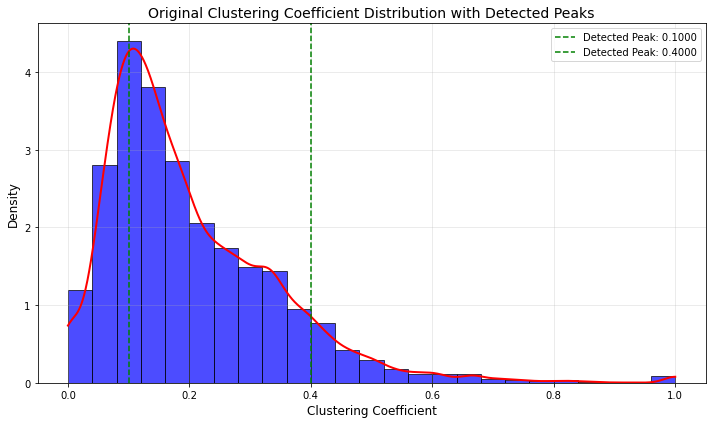

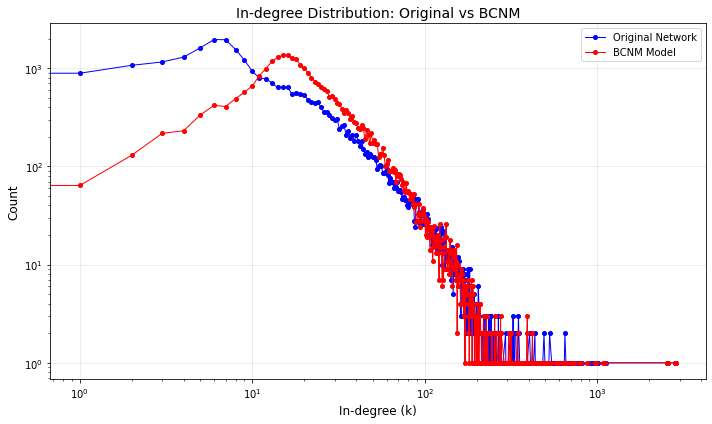

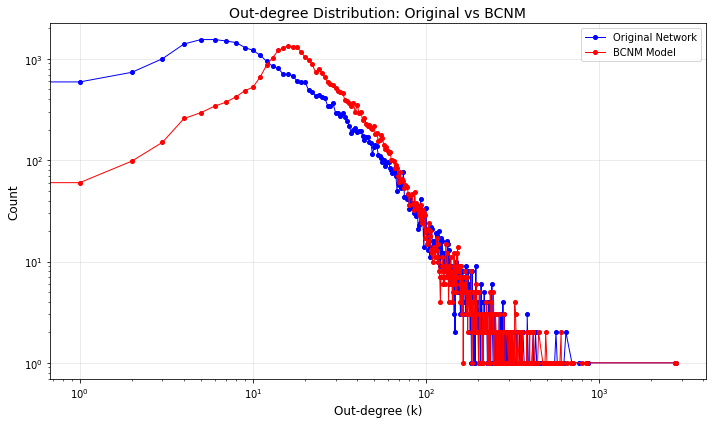

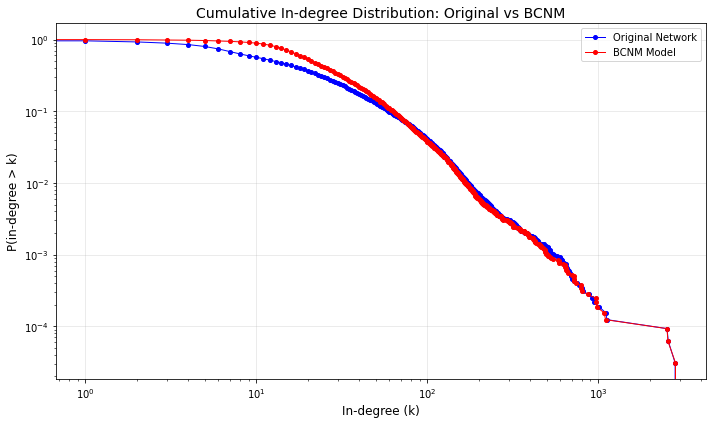

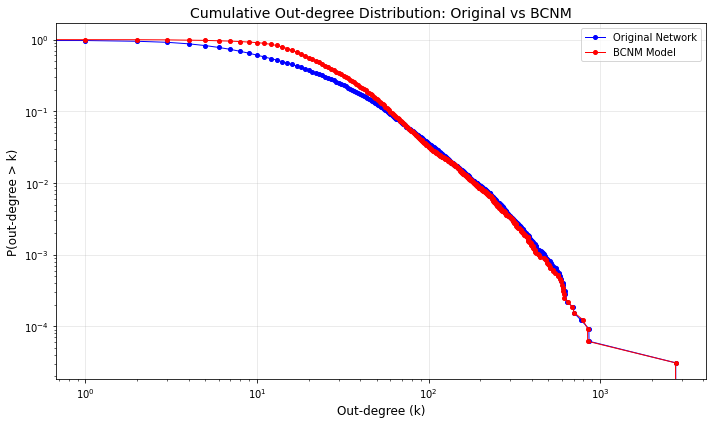

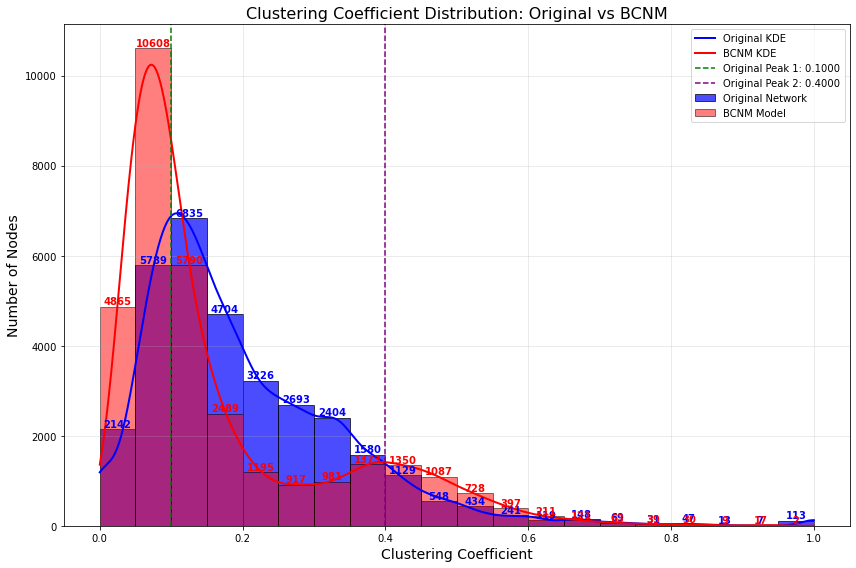

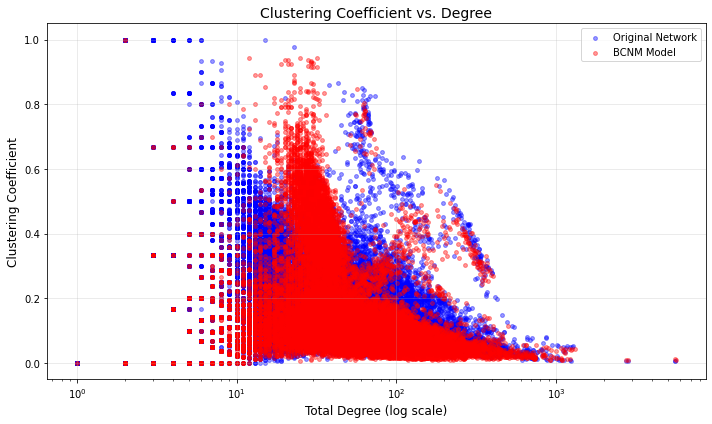

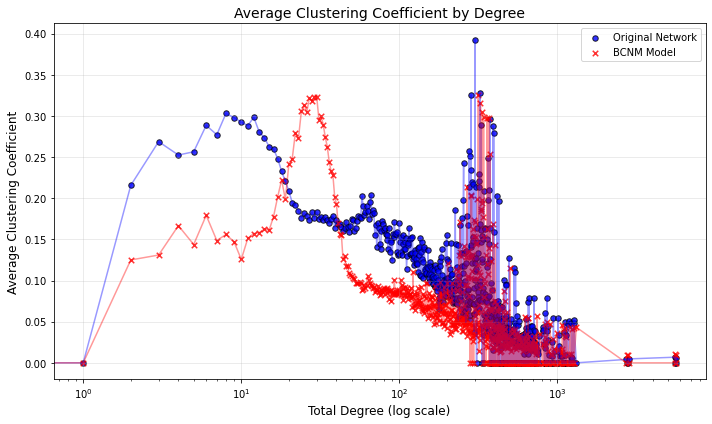

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import time
import random
from scipy.stats import gaussian_kde, ks_2samp
from scipy.signal import find_peaks

print("Starting Bimodal Clustering Network Model (BCNM) implementation...")
start_time = time.time()

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Calculate total degree
total_degree = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
clustering = nx.clustering(G.to_undirected())

# Analyze clustering coefficient distribution to find the bimodal peaks
cc_values = np.array(list(clustering.values()))
cc_kde = gaussian_kde(cc_values)
x_vals = np.linspace(0, 1, 1000)
y_vals = cc_kde(x_vals)

# Find peaks in the distribution
peaks, _ = find_peaks(y_vals, height=max(y_vals)*0.2, distance=50)
peak_x = x_vals[peaks]
peak_y = y_vals[peaks]

# Sort peaks by height
if len(peak_y) >= 2:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]
    peak_cc_values = sorted([peak_x[idx] for idx in top_peaks])
    
    peak1 = peak_cc_values[0]
    peak2 = peak_cc_values[1] if len(peak_cc_values) > 1 else peak_cc_values[0]
    
    print(f"Identified clustering coefficient peaks at: {peak1:.4f} and {peak2:.4f}")
else:
    # Fallback if peaks aren't found
    print("Failed to find bimodal peaks automatically, using default values")
    peak1 = 0.1
    peak2 = 0.4
    
    
    
    
    
# Plot the original clustering coefficient distribution with detected peaks
plt.figure(figsize=(10, 6))
plt.hist(cc_values, bins=25, alpha=0.7, density=True, color='blue', edgecolor='black')
plt.plot(x_vals, y_vals, 'r-', linewidth=2)
for peak in [peak1, peak2]:
    plt.axvline(x=peak, color='green', linestyle='--', 
                label=f'Detected Peak: {peak:.4f}')
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Original Clustering Coefficient Distribution with Detected Peaks', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/original_cc_peaks.png', dpi=600)
print("Saved original clustering coefficient distribution with peaks plot at 600dpi")

# Classify nodes into two groups based on clustering coefficient
print("Classifying nodes based on clustering coefficient...")
midpoint = (peak1 + peak2) / 2
nodes_low_cc = [node for node, cc in clustering.items() if cc <= midpoint]
nodes_high_cc = [node for node, cc in clustering.items() if cc > midpoint]

print(f"Low clustering coefficient group (≤{midpoint:.4f}): {len(nodes_low_cc)} nodes")
print(f"High clustering coefficient group (>{midpoint:.4f}): {len(nodes_high_cc)} nodes")

# Create the Bimodal Clustering Network Model
print("Creating Bimodal Clustering Network Model...")
bcnm_graph = nx.DiGraph()

# Add the same nodes as the original graph with their attributes
for node in G.nodes():
    bcnm_graph.add_node(node, **G.nodes[node])

print(f"Added {bcnm_graph.number_of_nodes()} nodes to BCNM graph")

# Step 1: Create communities based on the bimodal clustering and module information
print("Step 1: Creating communities based on bimodal clustering and modules...")

# Group nodes by module and clustering group
module_cc_groups = defaultdict(lambda: defaultdict(list))
for node in G.nodes():
    module = modules[node]
    cc_group = "high" if node in nodes_high_cc else "low"
    module_cc_groups[module][cc_group].append(node)

# Create communities from these groups
communities = []
community_id = 0
node_to_community = {}

# Process high CC nodes first (they form tightly connected communities)
for module, cc_groups in module_cc_groups.items():
    high_cc_nodes = cc_groups["high"]
    
    if high_cc_nodes:
        # Further divide high CC nodes by degree for better structure preservation
        degree_groups = defaultdict(list)
        for node in high_cc_nodes:
            degree_bin = total_degree[node] // 5  # Group by degree in bins of 5
            degree_groups[degree_bin].append(node)
        
        # Create communities from degree groups
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:  # Minimum community size
                community_size = min(20, len(nodes))  # Limit maximum community size
                
                # Split into communities of appropriate size
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                # Handle singleton nodes
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1
    
    # Process low CC nodes with different strategy
    low_cc_nodes = cc_groups["low"]
    
    if low_cc_nodes:
        # Low CC nodes form more loosely connected communities
        # Group by degree for better degree distribution preservation
        degree_groups = defaultdict(list)
        for node in low_cc_nodes:
            degree_bin = total_degree[node] // 10  # Wider bins for low CC
            degree_groups[degree_bin].append(node)
        
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:
                community_size = min(30, len(nodes))  # Larger communities
                
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1

print(f"Created {community_id} communities")

# Step 2: Add edges within communities with appropriate densities
print("Step 2: Adding edges within communities...")

edges_added = 0
for community_idx, community in enumerate(communities):
    if len(community) <= 1:
        continue
    
    # Calculate target average clustering for this community
    community_nodes_cc = [clustering[node] for node in community]
    target_cc = np.mean(community_nodes_cc)
    
    # Calculate density based on target clustering
    if target_cc > midpoint:
        # High clustering communities - higher density
        # For a complete graph, density = 1, cc = 1
        # Scale density based on target_cc
        density = min(0.95, max(0.5, target_cc))
    else:
        # Low clustering communities - lower density
        density = min(0.5, max(0.05, target_cc * 2))
    
    # Add edges with calculated density
    for i, u in enumerate(community):
        for j, v in enumerate(community):
            if i != j and random.random() < density:
                bcnm_graph.add_edge(u, v)
                edges_added += 1

print(f"Added {edges_added} edges within communities")
print(f"After Step 2: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 3: Connect communities to match the inter-community structure of the original graph
print("Step 3: Connecting communities...")

# Analyze inter-community connections in the original graph
inter_community_edges = defaultdict(int)
inter_community_pairs = defaultdict(int)

for u, v in G.edges():
    if u in node_to_community and v in node_to_community:
        comm_u = node_to_community[u]
        comm_v = node_to_community[v]
        
        if comm_u != comm_v:
            inter_community_edges[(comm_u, comm_v)] += 1
            inter_community_pairs[(comm_u, comm_v)] += 1

# Calculate probability of edges between communities
inter_community_probs = {}
for (comm_u, comm_v), count in inter_community_edges.items():
    # Get sizes of communities
    size_u = len(communities[comm_u]) if comm_u < len(communities) else 0
    size_v = len(communities[comm_v]) if comm_v < len(communities) else 0
    
    if size_u > 0 and size_v > 0:
        # Maximum possible edges between communities
        max_edges = size_u * size_v
        # Probability of edge
        prob = count / max_edges
        inter_community_probs[(comm_u, comm_v)] = min(1.0, max(0.001, prob))

print(f"Calculated probabilities for {len(inter_community_probs)} community pairs")

# Add edges between communities
inter_edges_added = 0
for (comm_u, comm_v), prob in inter_community_probs.items():
    # Get nodes from communities
    nodes_u = communities[comm_u] if comm_u < len(communities) else []
    nodes_v = communities[comm_v] if comm_v < len(communities) else []
    
    for u in nodes_u:
        for v in nodes_v:
            if random.random() < prob:
                bcnm_graph.add_edge(u, v)
                inter_edges_added += 1

print(f"Added {inter_edges_added} edges between communities")
print(f"After Step 3: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 4: Degree correction to match target degree distribution
print("Step 4: Performing degree correction...")

# Get current degrees
current_in_degrees = dict(bcnm_graph.in_degree())
current_out_degrees = dict(bcnm_graph.out_degree())

# Calculate how many edges need to be added for each node
in_degree_deficit = {node: max(0, in_degrees[node] - current_in_degrees[node]) for node in G.nodes()}
out_degree_deficit = {node: max(0, out_degrees[node] - current_out_degrees[node]) for node in G.nodes()}

total_in_deficit = sum(in_degree_deficit.values())
total_out_deficit = sum(out_degree_deficit.values())
print(f"Total in-degree deficit: {total_in_deficit}")
print(f"Total out-degree deficit: {total_out_deficit}")

# Create stubs for the Configuration Model part
in_stubs = []
for node, deficit in in_degree_deficit.items():
    in_stubs.extend([node] * deficit)

out_stubs = []
for node, deficit in out_degree_deficit.items():
    out_stubs.extend([node] * deficit)

# Shuffle stubs
random.shuffle(in_stubs)
random.shuffle(out_stubs)

# Match stubs to create edges, avoiding self-loops and multi-edges
added_edges = 0
max_attempts = min(len(in_stubs), len(out_stubs)) * 10  # Allow for multiple attempts
attempts = 0

while in_stubs and out_stubs and attempts < max_attempts:
    out_node = out_stubs.pop()
    in_node = in_stubs.pop()
    
    # Check if it's a self-loop or already existing edge
    if out_node != in_node and not bcnm_graph.has_edge(out_node, in_node):
        bcnm_graph.add_edge(out_node, in_node)
        added_edges += 1
    else:
        # Put the stubs back and try again
        out_stubs.append(out_node)
        in_stubs.append(in_node)
    
    attempts += 1

print(f"Step 4: Added {added_edges} edges to match degree distribution")
print(f"Final BCNM graph has {bcnm_graph.number_of_nodes()} nodes and {bcnm_graph.number_of_edges()} edges")

# Calculate final degrees and metrics
final_in_degrees = dict(bcnm_graph.in_degree())
final_out_degrees = dict(bcnm_graph.out_degree())

# Calculate average absolute error in degree matching
in_degree_error = sum(abs(in_degrees[n] - final_in_degrees[n]) for n in G.nodes()) / G.number_of_nodes()
out_degree_error = sum(abs(out_degrees[n] - final_out_degrees[n]) for n in G.nodes()) / G.number_of_nodes()

print(f"Average absolute error in in-degree matching: {in_degree_error:.4f}")
print(f"Average absolute error in out-degree matching: {out_degree_error:.4f}")

# Calculate clustering coefficients for the model
print("Calculating clustering coefficients for BCNM model...")
bcnm_clustering = nx.clustering(bcnm_graph.to_undirected())
print(f"Original network average clustering: {np.mean(list(clustering.values())):.4f}")
print(f"BCNM network average clustering: {np.mean(list(bcnm_clustering.values())):.4f}")

# Perform KS test for degree and clustering coefficient distributions
original_in_degrees_list = list(in_degrees.values())
original_out_degrees_list = list(out_degrees.values())
bcnm_in_degrees_list = list(final_in_degrees.values())
bcnm_out_degrees_list = list(final_out_degrees.values())

original_cc_list = list(clustering.values())
bcnm_cc_list = list(bcnm_clustering.values())

ks_in_degree = ks_2samp(original_in_degrees_list, bcnm_in_degrees_list)
ks_out_degree = ks_2samp(original_out_degrees_list, bcnm_out_degrees_list)
ks_clustering = ks_2samp(original_cc_list, bcnm_cc_list)

print(f"KS test for in-degree distribution: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.4f}")
print(f"KS test for out-degree distribution: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.4f}")
print(f"KS test for clustering coefficient distribution: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.4f}")

# Plot comparison of degree distributions
print("Plotting degree distributions...")

# Calculate degree distributions
original_in_degree_counts = Counter(original_in_degrees_list)
original_out_degree_counts = Counter(original_out_degrees_list)
bcnm_in_degree_counts = Counter(bcnm_in_degrees_list)
bcnm_out_degree_counts = Counter(bcnm_out_degrees_list)

# In-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_in_degree_counts.keys()), 
           [original_in_degree_counts[k] for k in sorted(original_in_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_in_degree_counts.keys()), 
           [bcnm_in_degree_counts[k] for k in sorted(bcnm_in_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_out_degree_counts.keys()), 
           [original_out_degree_counts[k] for k in sorted(original_out_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_out_degree_counts.keys()), 
           [bcnm_out_degree_counts[k] for k in sorted(bcnm_out_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_in, y_bcnm_in, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_out, y_bcnm_out, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(12, 8))

# Create histogram bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_cc_list, bins=bins, alpha=0.7, 
                                     color='blue', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# Add count numbers above bars
bin_centers = 0.5 * (bins[:-1] + bins[1:])
for i, (count_orig, count_bcnm) in enumerate(zip(counts_orig, counts_bcnm)):
    if count_orig > 0:
        plt.text(bin_centers[i], count_orig + 5, str(int(count_orig)), 
                 ha='center', va='bottom', color='blue', fontweight='bold')
    if count_bcnm > 0:
        plt.text(bin_centers[i], count_bcnm + 5, str(int(count_bcnm)), 
                 ha='center', va='bottom', color='red', fontweight='bold')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE')

# Add vertical lines for the original peaks
plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

# Create a scatter plot of clustering coefficient by degree
print("Creating scatter plot of clustering coefficient by degree...")

plt.figure(figsize=(10, 6))

# Original network
plt.scatter([total_degree[n] for n in G.nodes()], 
            [clustering[n] for n in G.nodes()],
            alpha=0.4, s=15, c='blue', label='Original Network')

# BCNM model
bcnm_total_degree = {n: final_in_degrees[n] + final_out_degrees[n] for n in bcnm_graph.nodes()}
plt.scatter([bcnm_total_degree[n] for n in bcnm_graph.nodes()], 
            [bcnm_clustering[n] for n in bcnm_graph.nodes()],
            alpha=0.4, s=15, c='red', label='BCNM Model')

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Clustering Coefficient vs. Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cc_vs_degree.png', dpi=600)
print("Saved clustering coefficient vs. degree plot at 600dpi")

# Calculate average clustering by degree for both networks
print("Calculating average clustering by degree...")

# Original network
original_cc_by_degree = defaultdict(list)
for node in G.nodes():
    deg = total_degree[node]
    original_cc_by_degree[deg].append(clustering[node])

# BCNM model
bcnm_cc_by_degree = defaultdict(list)
for node in bcnm_graph.nodes():
    deg = bcnm_total_degree[node]
    bcnm_cc_by_degree[deg].append(bcnm_clustering[node])

# Calculate averages
original_avg_cc_by_degree = {d: np.mean(cc) for d, cc in original_cc_by_degree.items() if cc}
bcnm_avg_cc_by_degree = {d: np.mean(cc) for d, cc in bcnm_cc_by_degree.items() if cc}

# Plot average clustering coefficient by degree
plt.figure(figsize=(10, 6))

# Get sorted degrees
all_degrees = sorted(set(original_avg_cc_by_degree.keys()) | set(bcnm_avg_cc_by_degree.keys()))
original_cc_values = [original_avg_cc_by_degree.get(d, 0) for d in all_degrees]
bcnm_cc_values = [bcnm_avg_cc_by_degree.get(d, 0) for d in all_degrees]

plt.scatter(all_degrees, original_cc_values, alpha=0.8, s=30, c='blue', 
            edgecolors='black', label='Original Network')
plt.scatter(all_degrees, bcnm_cc_values, alpha=0.8, s=30, c='red', 
            edgecolors='black', label='BCNM Model', marker='x')

# Add trend lines
plt.plot(all_degrees, original_cc_values, 'b-', alpha=0.4)
plt.plot(all_degrees, bcnm_cc_values, 'r-', alpha=0.4)

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Average Clustering Coefficient by Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

Saved clustering coefficient histogram plot at 600dpi


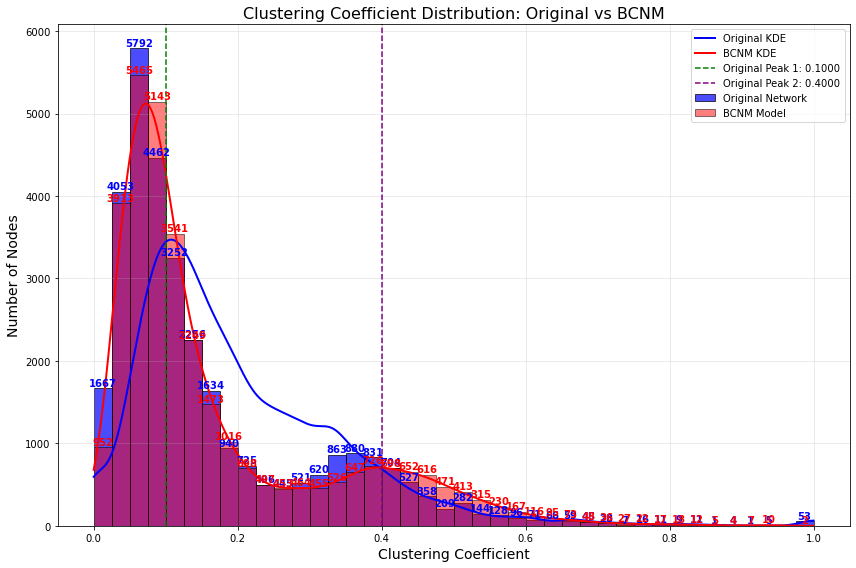

In [7]:
original_clustering = nx.clustering(G)  # Uses undirected version by default
original_clustering_values = list(original_clustering.values())

Plotting...
Saved clustering coefficient histogram plot at 600dpi


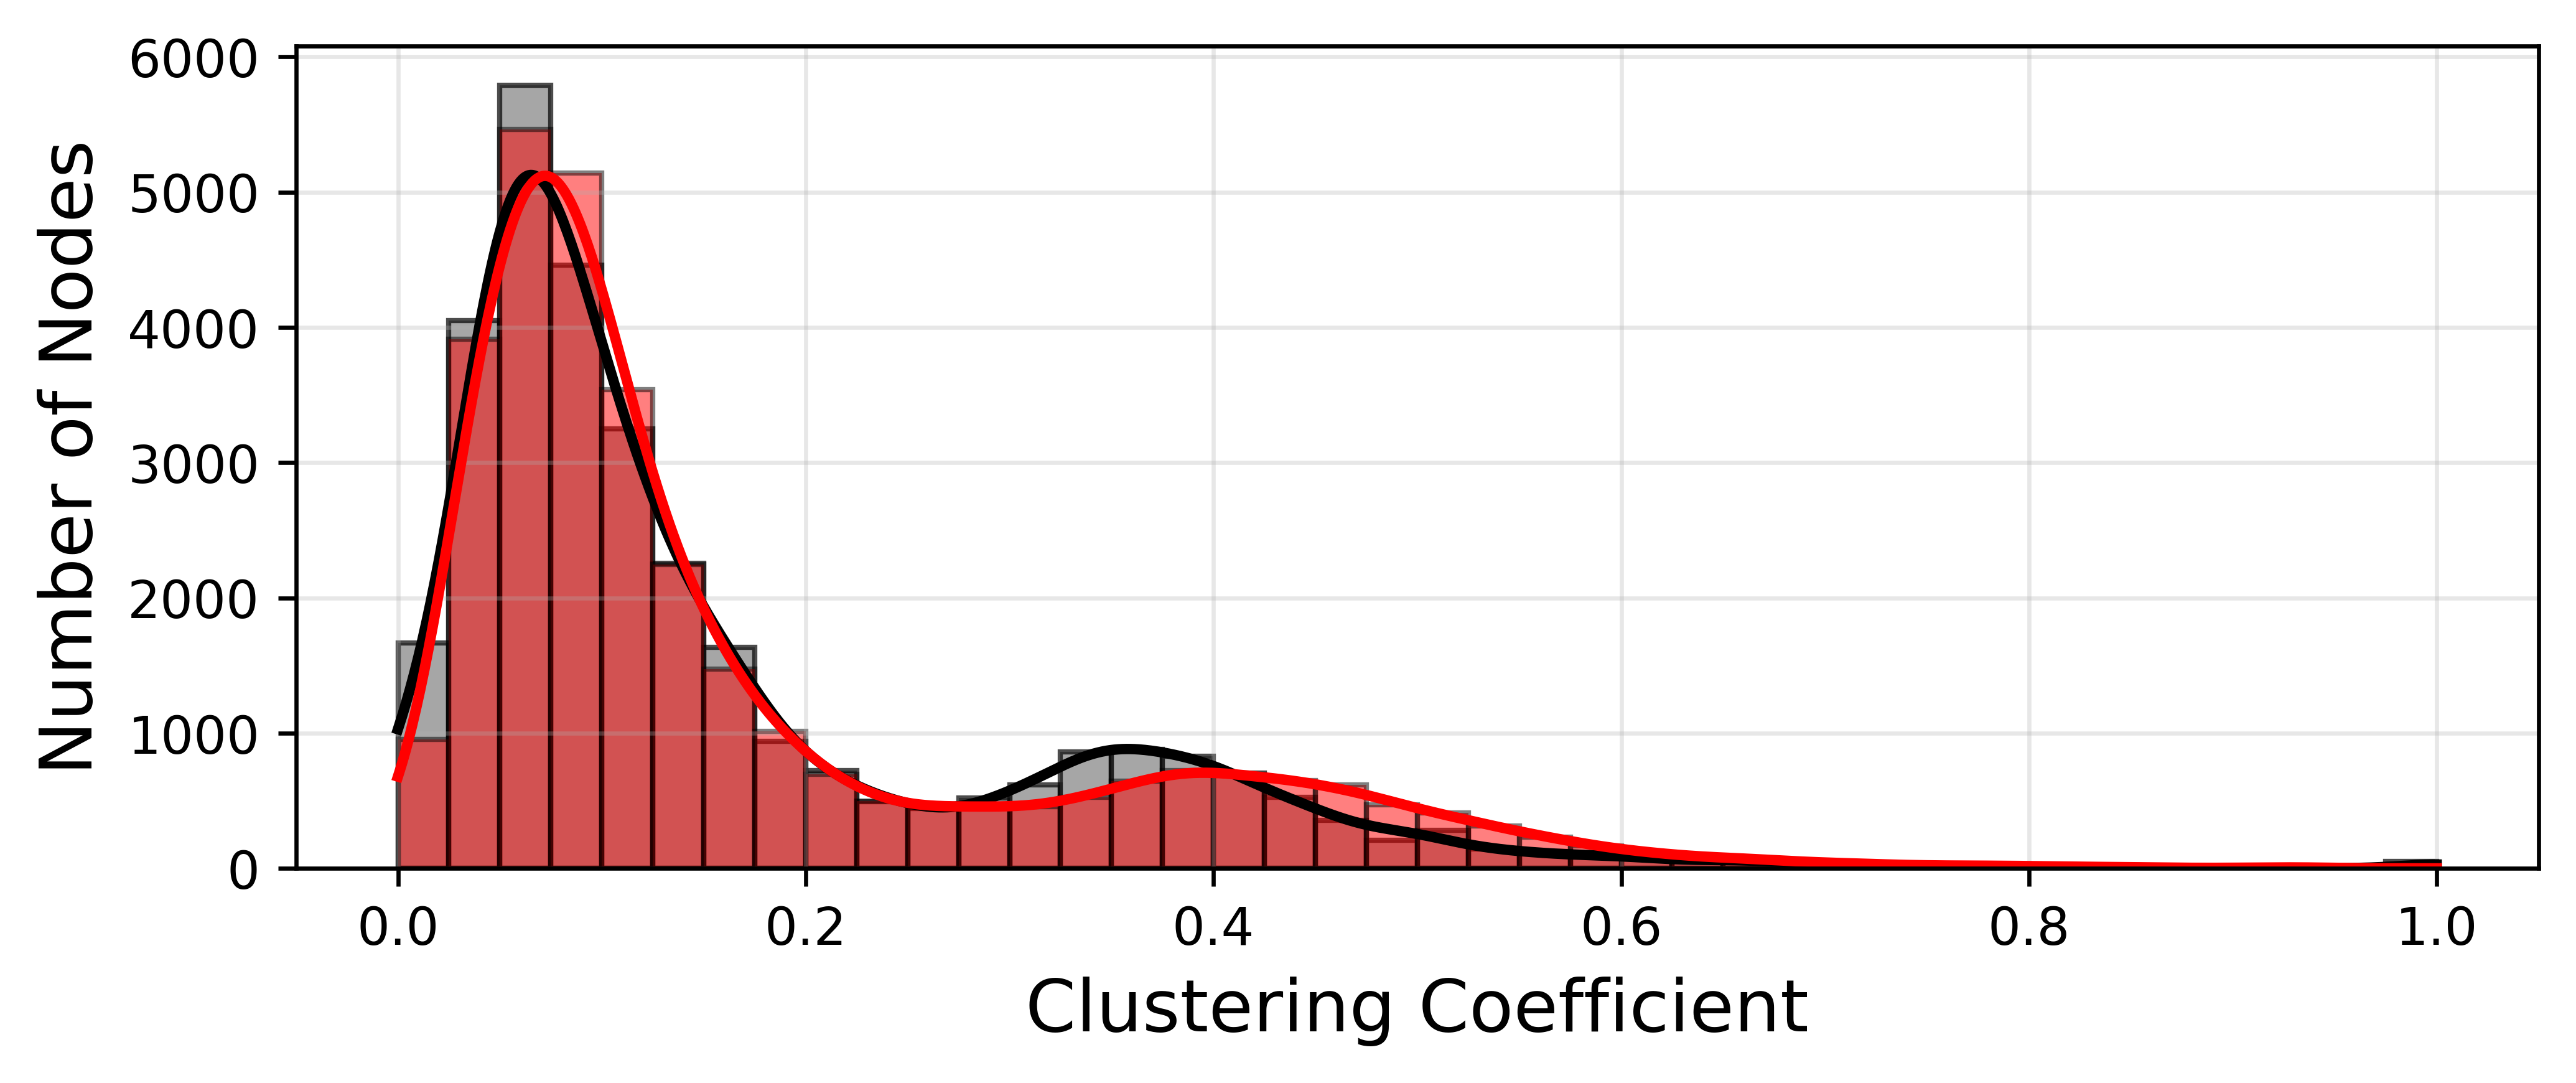

In [13]:
bcnm_cc_list = list(bcnm_clustering.values())
print("Plotting...")
plt.figure(figsize=(7, 3),dpi=600)

# Create histogram bins
bins = np.linspace(0, 1, 41)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_clustering_values, bins=bins, alpha=0.7, 
                                     color='grey', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# # Add count numbers above bars
# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# for i, (count_orig, count_bcnm) in enumerate(zip(counts_orig, counts_bcnm)):
#     if count_orig > 0:
#         plt.text(bin_centers[i], count_orig + 5, str(int(count_orig)), 
#                  ha='center', va='bottom', color='blue', fontweight='bold')
#     if count_bcnm > 0:
#         plt.text(bin_centers[i], count_bcnm + 5, str(int(count_bcnm)), 
#                  ha='center', va='bottom', color='red', fontweight='bold')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_clustering_values)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_clustering_values) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE',color='black')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE',color='red')

# # Add vertical lines for the original peaks
# plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
# plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
# plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
# plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

Starting Bimodal Clustering Network Model (BCNM) implementation...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Calculating clustering coefficients...
Identified clustering coefficient peaks at: 0.0651 and 0.3584


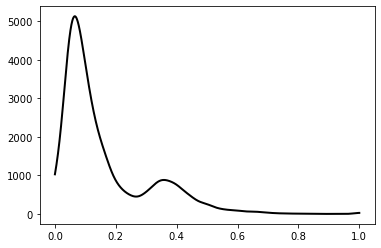

In [22]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import time
import random
from scipy.stats import gaussian_kde, ks_2samp
from scipy.signal import find_peaks

print("Starting Bimodal Clustering Network Model (BCNM) implementation...")
start_time = time.time()

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Calculate total degree
total_degree = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
clustering = nx.clustering(G)

original_clustering = nx.clustering(G)  # Uses undirected version by default
original_clustering_values = list(original_clustering.values())

bins = np.linspace(0, 1, 41)  # 20 bins from 0 to 1

kde = gaussian_kde(original_clustering_values)
x_vals = np.linspace(0, 1, 1000)
y_vals = kde(x_vals) * len(original_clustering_values) * (bins[1] - bins[0])  # Scale to match histogram height
# plt.plot(x_vals, y_vals, '-', linewidth=2, label='Original KDE',color='black')

# Find peaks in the original KDE
peaks, _ = find_peaks(y_vals, height=max(y_vals)*0.1, distance=50)
peak_x = x_vals[peaks]
peak_y = y_vals[peaks]

# Sort peaks by height
if len(peak_y) >= 2:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]
    peak_cc_values = sorted([peak_x[idx] for idx in top_peaks])
    
    peak1 = peak_cc_values[0]
    peak2 = peak_cc_values[1] if len(peak_cc_values) > 1 else peak_cc_values[0]
    
    print(f"Identified clustering coefficient peaks at: {peak1:.4f} and {peak2:.4f}")
else:
    # Fallback if peaks aren't found
    print("Failed to find bimodal peaks automatically, using default values")
    peak1 = 0.1
    peak2 = 0.4



Saved original clustering coefficient distribution with peaks plot at 600dpi
Classifying nodes based on clustering coefficient...
Low clustering coefficient group (≤0.2117): 24464 nodes
High clustering coefficient group (>0.2117): 7808 nodes
Creating Bimodal Clustering Network Model...
Added 32272 nodes to BCNM graph
Step 1: Creating communities based on bimodal clustering and modules...
Created 2475 communities
Step 2: Adding edges within communities...
Added 167832 edges within communities
After Step 2: BCNM graph has 167832 edges
Step 3: Connecting communities...
Calculated probabilities for 307021 community pairs
Added 838557 edges between communities
After Step 3: BCNM graph has 1006389 edges
Step 4: Performing degree correction...
Total in-degree deficit: 72919
Total out-degree deficit: 73262
Step 4: Added 289 edges to match degree distribution
Final BCNM graph has 32272 nodes and 1006678 edges
Average absolute error in in-degree matching: 9.3566
Average absolute error in out-deg

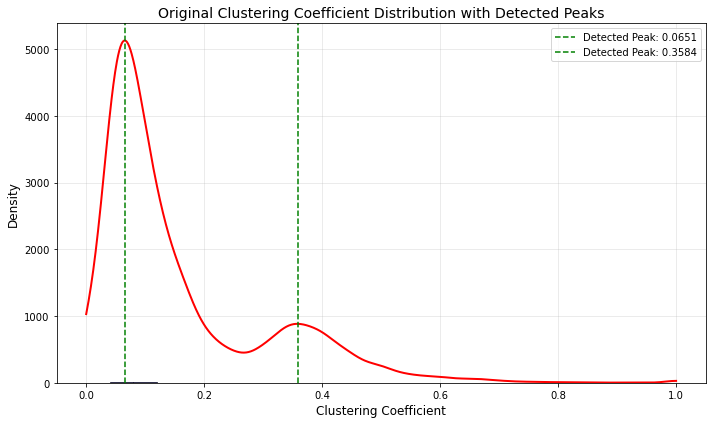

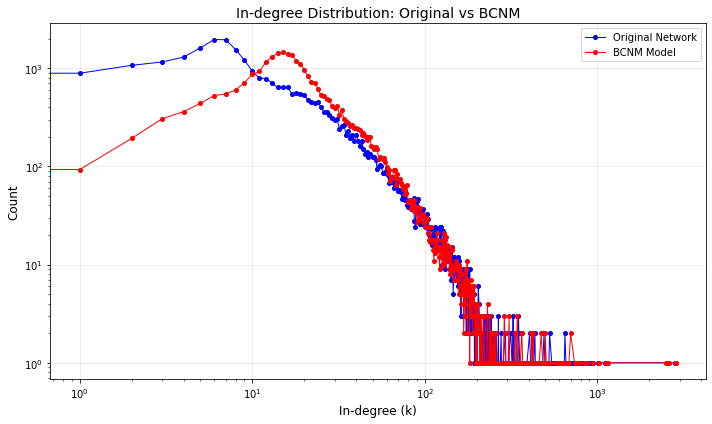

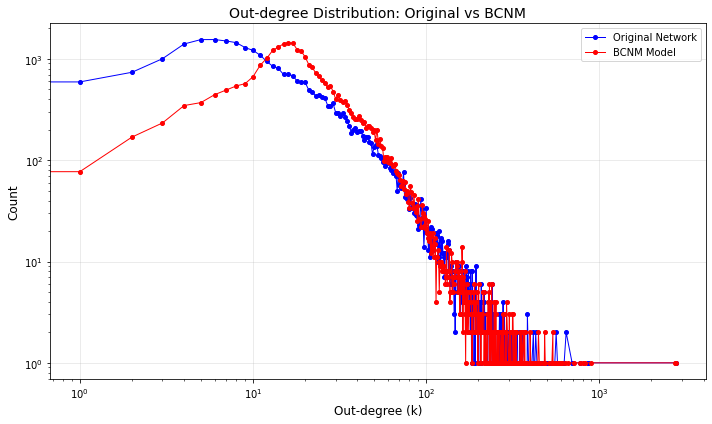

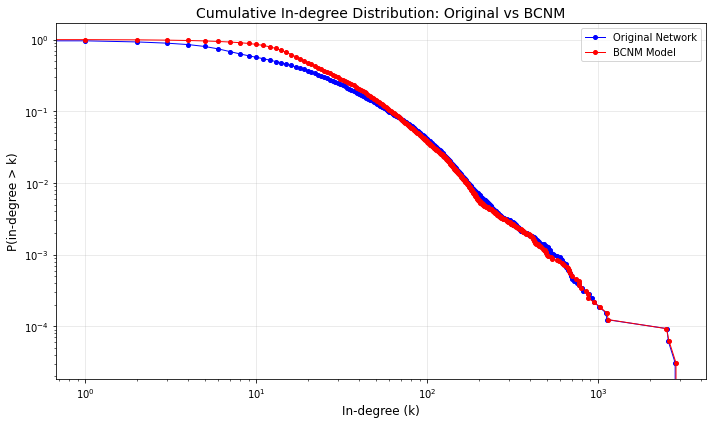

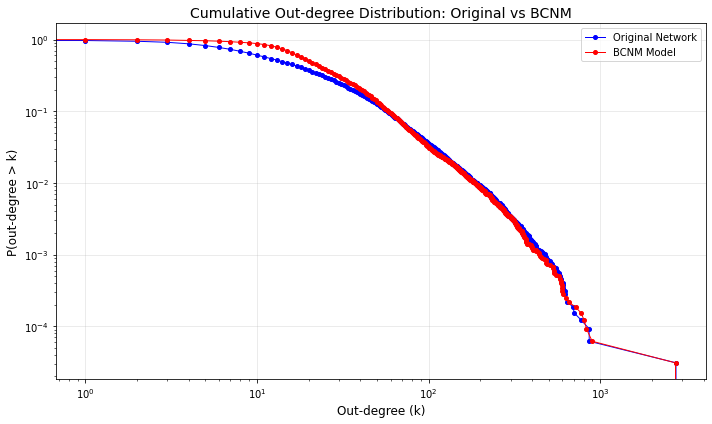

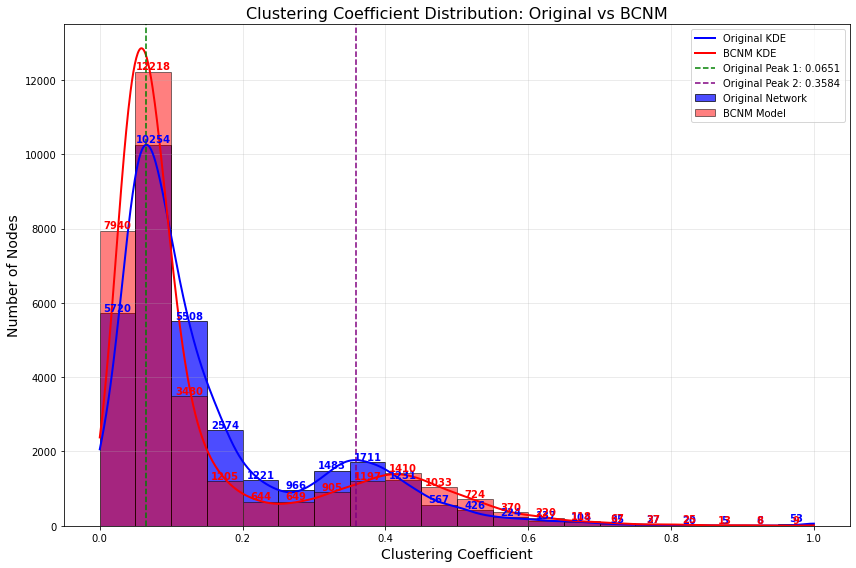

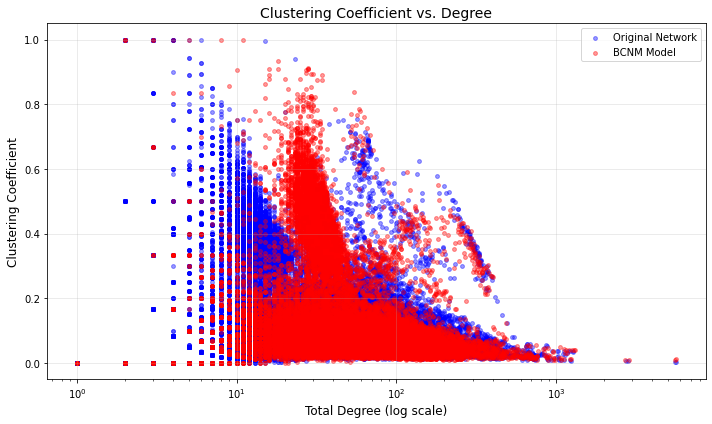

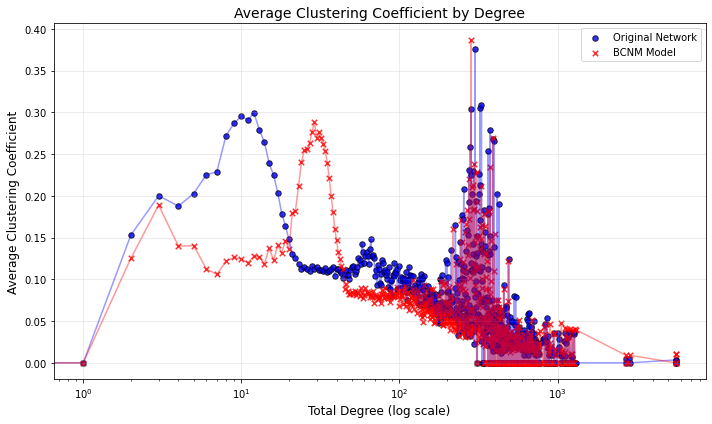

In [23]:
# Plot the original clustering coefficient distribution with detected peaks
plt.figure(figsize=(10, 6))
plt.hist(cc_values, bins=25, alpha=0.7, density=True, color='blue', edgecolor='black')
plt.plot(x_vals, y_vals, 'r-', linewidth=2)
for peak in [peak1, peak2]:
    plt.axvline(x=peak, color='green', linestyle='--', 
                label=f'Detected Peak: {peak:.4f}')
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Original Clustering Coefficient Distribution with Detected Peaks', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/original_cc_peaks.png', dpi=600)
print("Saved original clustering coefficient distribution with peaks plot at 600dpi")

# Classify nodes into two groups based on clustering coefficient
print("Classifying nodes based on clustering coefficient...")
midpoint = (peak1 + peak2) / 2
nodes_low_cc = [node for node, cc in clustering.items() if cc <= midpoint]
nodes_high_cc = [node for node, cc in clustering.items() if cc > midpoint]

print(f"Low clustering coefficient group (≤{midpoint:.4f}): {len(nodes_low_cc)} nodes")
print(f"High clustering coefficient group (>{midpoint:.4f}): {len(nodes_high_cc)} nodes")

# Create the Bimodal Clustering Network Model
print("Creating Bimodal Clustering Network Model...")
bcnm_graph = nx.DiGraph()

# Add the same nodes as the original graph with their attributes
for node in G.nodes():
    bcnm_graph.add_node(node, **G.nodes[node])

print(f"Added {bcnm_graph.number_of_nodes()} nodes to BCNM graph")

# Step 1: Create communities based on the bimodal clustering and module information
print("Step 1: Creating communities based on bimodal clustering and modules...")

# Group nodes by module and clustering group
module_cc_groups = defaultdict(lambda: defaultdict(list))
for node in G.nodes():
    module = modules[node]
    cc_group = "high" if node in nodes_high_cc else "low"
    module_cc_groups[module][cc_group].append(node)

# Create communities from these groups
communities = []
community_id = 0
node_to_community = {}

# Process high CC nodes first (they form tightly connected communities)
for module, cc_groups in module_cc_groups.items():
    high_cc_nodes = cc_groups["high"]
    
    if high_cc_nodes:
        # Further divide high CC nodes by degree for better structure preservation
        degree_groups = defaultdict(list)
        for node in high_cc_nodes:
            degree_bin = total_degree[node] // 5  # Group by degree in bins of 5
            degree_groups[degree_bin].append(node)
        
        # Create communities from degree groups
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:  # Minimum community size
                community_size = min(20, len(nodes))  # Limit maximum community size
                
                # Split into communities of appropriate size
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                # Handle singleton nodes
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1
    
    # Process low CC nodes with different strategy
    low_cc_nodes = cc_groups["low"]
    
    if low_cc_nodes:
        # Low CC nodes form more loosely connected communities
        # Group by degree for better degree distribution preservation
        degree_groups = defaultdict(list)
        for node in low_cc_nodes:
            degree_bin = total_degree[node] // 10  # Wider bins for low CC
            degree_groups[degree_bin].append(node)
        
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:
                community_size = min(30, len(nodes))  # Larger communities
                
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1

print(f"Created {community_id} communities")

# Step 2: Add edges within communities with appropriate densities
print("Step 2: Adding edges within communities...")

edges_added = 0
for community_idx, community in enumerate(communities):
    if len(community) <= 1:
        continue
    
    # Calculate target average clustering for this community
    community_nodes_cc = [clustering[node] for node in community]
    target_cc = np.mean(community_nodes_cc)
    
    # Calculate density based on target clustering
    if target_cc > midpoint:
        # High clustering communities - higher density
        # For a complete graph, density = 1, cc = 1
        # Scale density based on target_cc
        density = min(0.95, max(0.5, target_cc))
    else:
        # Low clustering communities - lower density
        density = min(0.5, max(0.05, target_cc * 2))
    
    # Add edges with calculated density
    for i, u in enumerate(community):
        for j, v in enumerate(community):
            if i != j and random.random() < density:
                bcnm_graph.add_edge(u, v)
                edges_added += 1

print(f"Added {edges_added} edges within communities")
print(f"After Step 2: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 3: Connect communities to match the inter-community structure of the original graph
print("Step 3: Connecting communities...")

# Analyze inter-community connections in the original graph
inter_community_edges = defaultdict(int)
inter_community_pairs = defaultdict(int)

for u, v in G.edges():
    if u in node_to_community and v in node_to_community:
        comm_u = node_to_community[u]
        comm_v = node_to_community[v]
        
        if comm_u != comm_v:
            inter_community_edges[(comm_u, comm_v)] += 1
            inter_community_pairs[(comm_u, comm_v)] += 1

# Calculate probability of edges between communities
inter_community_probs = {}
for (comm_u, comm_v), count in inter_community_edges.items():
    # Get sizes of communities
    size_u = len(communities[comm_u]) if comm_u < len(communities) else 0
    size_v = len(communities[comm_v]) if comm_v < len(communities) else 0
    
    if size_u > 0 and size_v > 0:
        # Maximum possible edges between communities
        max_edges = size_u * size_v
        # Probability of edge
        prob = count / max_edges
        inter_community_probs[(comm_u, comm_v)] = min(1.0, max(0.001, prob))

print(f"Calculated probabilities for {len(inter_community_probs)} community pairs")

# Add edges between communities
inter_edges_added = 0
for (comm_u, comm_v), prob in inter_community_probs.items():
    # Get nodes from communities
    nodes_u = communities[comm_u] if comm_u < len(communities) else []
    nodes_v = communities[comm_v] if comm_v < len(communities) else []
    
    for u in nodes_u:
        for v in nodes_v:
            if random.random() < prob:
                bcnm_graph.add_edge(u, v)
                inter_edges_added += 1

print(f"Added {inter_edges_added} edges between communities")
print(f"After Step 3: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 4: Degree correction to match target degree distribution
print("Step 4: Performing degree correction...")

# Get current degrees
current_in_degrees = dict(bcnm_graph.in_degree())
current_out_degrees = dict(bcnm_graph.out_degree())

# Calculate how many edges need to be added for each node
in_degree_deficit = {node: max(0, in_degrees[node] - current_in_degrees[node]) for node in G.nodes()}
out_degree_deficit = {node: max(0, out_degrees[node] - current_out_degrees[node]) for node in G.nodes()}

total_in_deficit = sum(in_degree_deficit.values())
total_out_deficit = sum(out_degree_deficit.values())
print(f"Total in-degree deficit: {total_in_deficit}")
print(f"Total out-degree deficit: {total_out_deficit}")

# Create stubs for the Configuration Model part
in_stubs = []
for node, deficit in in_degree_deficit.items():
    in_stubs.extend([node] * deficit)

out_stubs = []
for node, deficit in out_degree_deficit.items():
    out_stubs.extend([node] * deficit)

# Shuffle stubs
random.shuffle(in_stubs)
random.shuffle(out_stubs)

# Match stubs to create edges, avoiding self-loops and multi-edges
added_edges = 0
max_attempts = min(len(in_stubs), len(out_stubs)) * 10  # Allow for multiple attempts
attempts = 0

while in_stubs and out_stubs and attempts < max_attempts:
    out_node = out_stubs.pop()
    in_node = in_stubs.pop()
    
    # Check if it's a self-loop or already existing edge
    if out_node != in_node and not bcnm_graph.has_edge(out_node, in_node):
        bcnm_graph.add_edge(out_node, in_node)
        added_edges += 1
    else:
        # Put the stubs back and try again
        out_stubs.append(out_node)
        in_stubs.append(in_node)
    
    attempts += 1

print(f"Step 4: Added {added_edges} edges to match degree distribution")
print(f"Final BCNM graph has {bcnm_graph.number_of_nodes()} nodes and {bcnm_graph.number_of_edges()} edges")

# Calculate final degrees and metrics
final_in_degrees = dict(bcnm_graph.in_degree())
final_out_degrees = dict(bcnm_graph.out_degree())

# Calculate average absolute error in degree matching
in_degree_error = sum(abs(in_degrees[n] - final_in_degrees[n]) for n in G.nodes()) / G.number_of_nodes()
out_degree_error = sum(abs(out_degrees[n] - final_out_degrees[n]) for n in G.nodes()) / G.number_of_nodes()

print(f"Average absolute error in in-degree matching: {in_degree_error:.4f}")
print(f"Average absolute error in out-degree matching: {out_degree_error:.4f}")

# Calculate clustering coefficients for the model
print("Calculating clustering coefficients for BCNM model...")
bcnm_clustering = nx.clustering(bcnm_graph.to_undirected())
print(f"Original network average clustering: {np.mean(list(clustering.values())):.4f}")
print(f"BCNM network average clustering: {np.mean(list(bcnm_clustering.values())):.4f}")

# Perform KS test for degree and clustering coefficient distributions
original_in_degrees_list = list(in_degrees.values())
original_out_degrees_list = list(out_degrees.values())
bcnm_in_degrees_list = list(final_in_degrees.values())
bcnm_out_degrees_list = list(final_out_degrees.values())

original_cc_list = list(clustering.values())
bcnm_cc_list = list(bcnm_clustering.values())

ks_in_degree = ks_2samp(original_in_degrees_list, bcnm_in_degrees_list)
ks_out_degree = ks_2samp(original_out_degrees_list, bcnm_out_degrees_list)
ks_clustering = ks_2samp(original_cc_list, bcnm_cc_list)

print(f"KS test for in-degree distribution: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.4f}")
print(f"KS test for out-degree distribution: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.4f}")
print(f"KS test for clustering coefficient distribution: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.4f}")

# Plot comparison of degree distributions
print("Plotting degree distributions...")

# Calculate degree distributions
original_in_degree_counts = Counter(original_in_degrees_list)
original_out_degree_counts = Counter(original_out_degrees_list)
bcnm_in_degree_counts = Counter(bcnm_in_degrees_list)
bcnm_out_degree_counts = Counter(bcnm_out_degrees_list)

# In-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_in_degree_counts.keys()), 
           [original_in_degree_counts[k] for k in sorted(original_in_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_in_degree_counts.keys()), 
           [bcnm_in_degree_counts[k] for k in sorted(bcnm_in_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_out_degree_counts.keys()), 
           [original_out_degree_counts[k] for k in sorted(original_out_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_out_degree_counts.keys()), 
           [bcnm_out_degree_counts[k] for k in sorted(bcnm_out_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_in, y_bcnm_in, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_out, y_bcnm_out, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(12, 8))

# Create histogram bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_cc_list, bins=bins, alpha=0.7, 
                                     color='blue', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# Add count numbers above bars
bin_centers = 0.5 * (bins[:-1] + bins[1:])
for i, (count_orig, count_bcnm) in enumerate(zip(counts_orig, counts_bcnm)):
    if count_orig > 0:
        plt.text(bin_centers[i], count_orig + 5, str(int(count_orig)), 
                 ha='center', va='bottom', color='blue', fontweight='bold')
    if count_bcnm > 0:
        plt.text(bin_centers[i], count_bcnm + 5, str(int(count_bcnm)), 
                 ha='center', va='bottom', color='red', fontweight='bold')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE')

# Add vertical lines for the original peaks
plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

# Create a scatter plot of clustering coefficient by degree
print("Creating scatter plot of clustering coefficient by degree...")

plt.figure(figsize=(10, 6))

# Original network
plt.scatter([total_degree[n] for n in G.nodes()], 
            [clustering[n] for n in G.nodes()],
            alpha=0.4, s=15, c='blue', label='Original Network')

# BCNM model
bcnm_total_degree = {n: final_in_degrees[n] + final_out_degrees[n] for n in bcnm_graph.nodes()}
plt.scatter([bcnm_total_degree[n] for n in bcnm_graph.nodes()], 
            [bcnm_clustering[n] for n in bcnm_graph.nodes()],
            alpha=0.4, s=15, c='red', label='BCNM Model')

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Clustering Coefficient vs. Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cc_vs_degree.png', dpi=600)
print("Saved clustering coefficient vs. degree plot at 600dpi")

# Calculate average clustering by degree for both networks
print("Calculating average clustering by degree...")

# Original network
original_cc_by_degree = defaultdict(list)
for node in G.nodes():
    deg = total_degree[node]
    original_cc_by_degree[deg].append(clustering[node])

# BCNM model
bcnm_cc_by_degree = defaultdict(list)
for node in bcnm_graph.nodes():
    deg = bcnm_total_degree[node]
    bcnm_cc_by_degree[deg].append(bcnm_clustering[node])

# Calculate averages
original_avg_cc_by_degree = {d: np.mean(cc) for d, cc in original_cc_by_degree.items() if cc}
bcnm_avg_cc_by_degree = {d: np.mean(cc) for d, cc in bcnm_cc_by_degree.items() if cc}

# Plot average clustering coefficient by degree
plt.figure(figsize=(10, 6))

# Get sorted degrees
all_degrees = sorted(set(original_avg_cc_by_degree.keys()) | set(bcnm_avg_cc_by_degree.keys()))
original_cc_values = [original_avg_cc_by_degree.get(d, 0) for d in all_degrees]
bcnm_cc_values = [bcnm_avg_cc_by_degree.get(d, 0) for d in all_degrees]

plt.scatter(all_degrees, original_cc_values, alpha=0.8, s=30, c='blue', 
            edgecolors='black', label='Original Network')
plt.scatter(all_degrees, bcnm_cc_values, alpha=0.8, s=30, c='red', 
            edgecolors='black', label='BCNM Model', marker='x')

# Add trend lines
plt.plot(all_degrees, original_cc_values, 'b-', alpha=0.4)
plt.plot(all_degrees, bcnm_cc_values, 'r-', alpha=0.4)

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Average Clustering Coefficient by Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

Plotting clustering coefficient distributions...
Saved clustering coefficient histogram plot at 600dpi


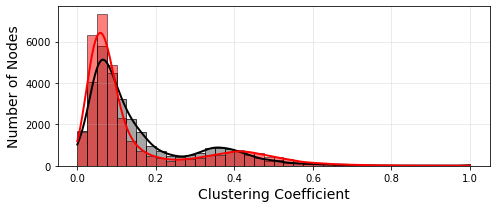

In [31]:
# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(7, 3))

# Create histogram bins
bins = np.linspace(0, 1, 41)  # 20 bins from 0 to 1

original_clustering = nx.clustering(G)  # Uses undirected version by default
original_clustering_values = list(original_clustering.values())

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_clustering_values, bins=bins, alpha=0.7, 
                                     color='grey', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE',color='black')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE',color='red')

# Add vertical lines for the original peaks
# plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
# plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
# plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
# plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.pdf', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")


Calculating cumulative degree distributions...
Saved cumulative in-degree distribution plot at 600dpi
Saved cumulative out-degree distribution plot at 600dpi


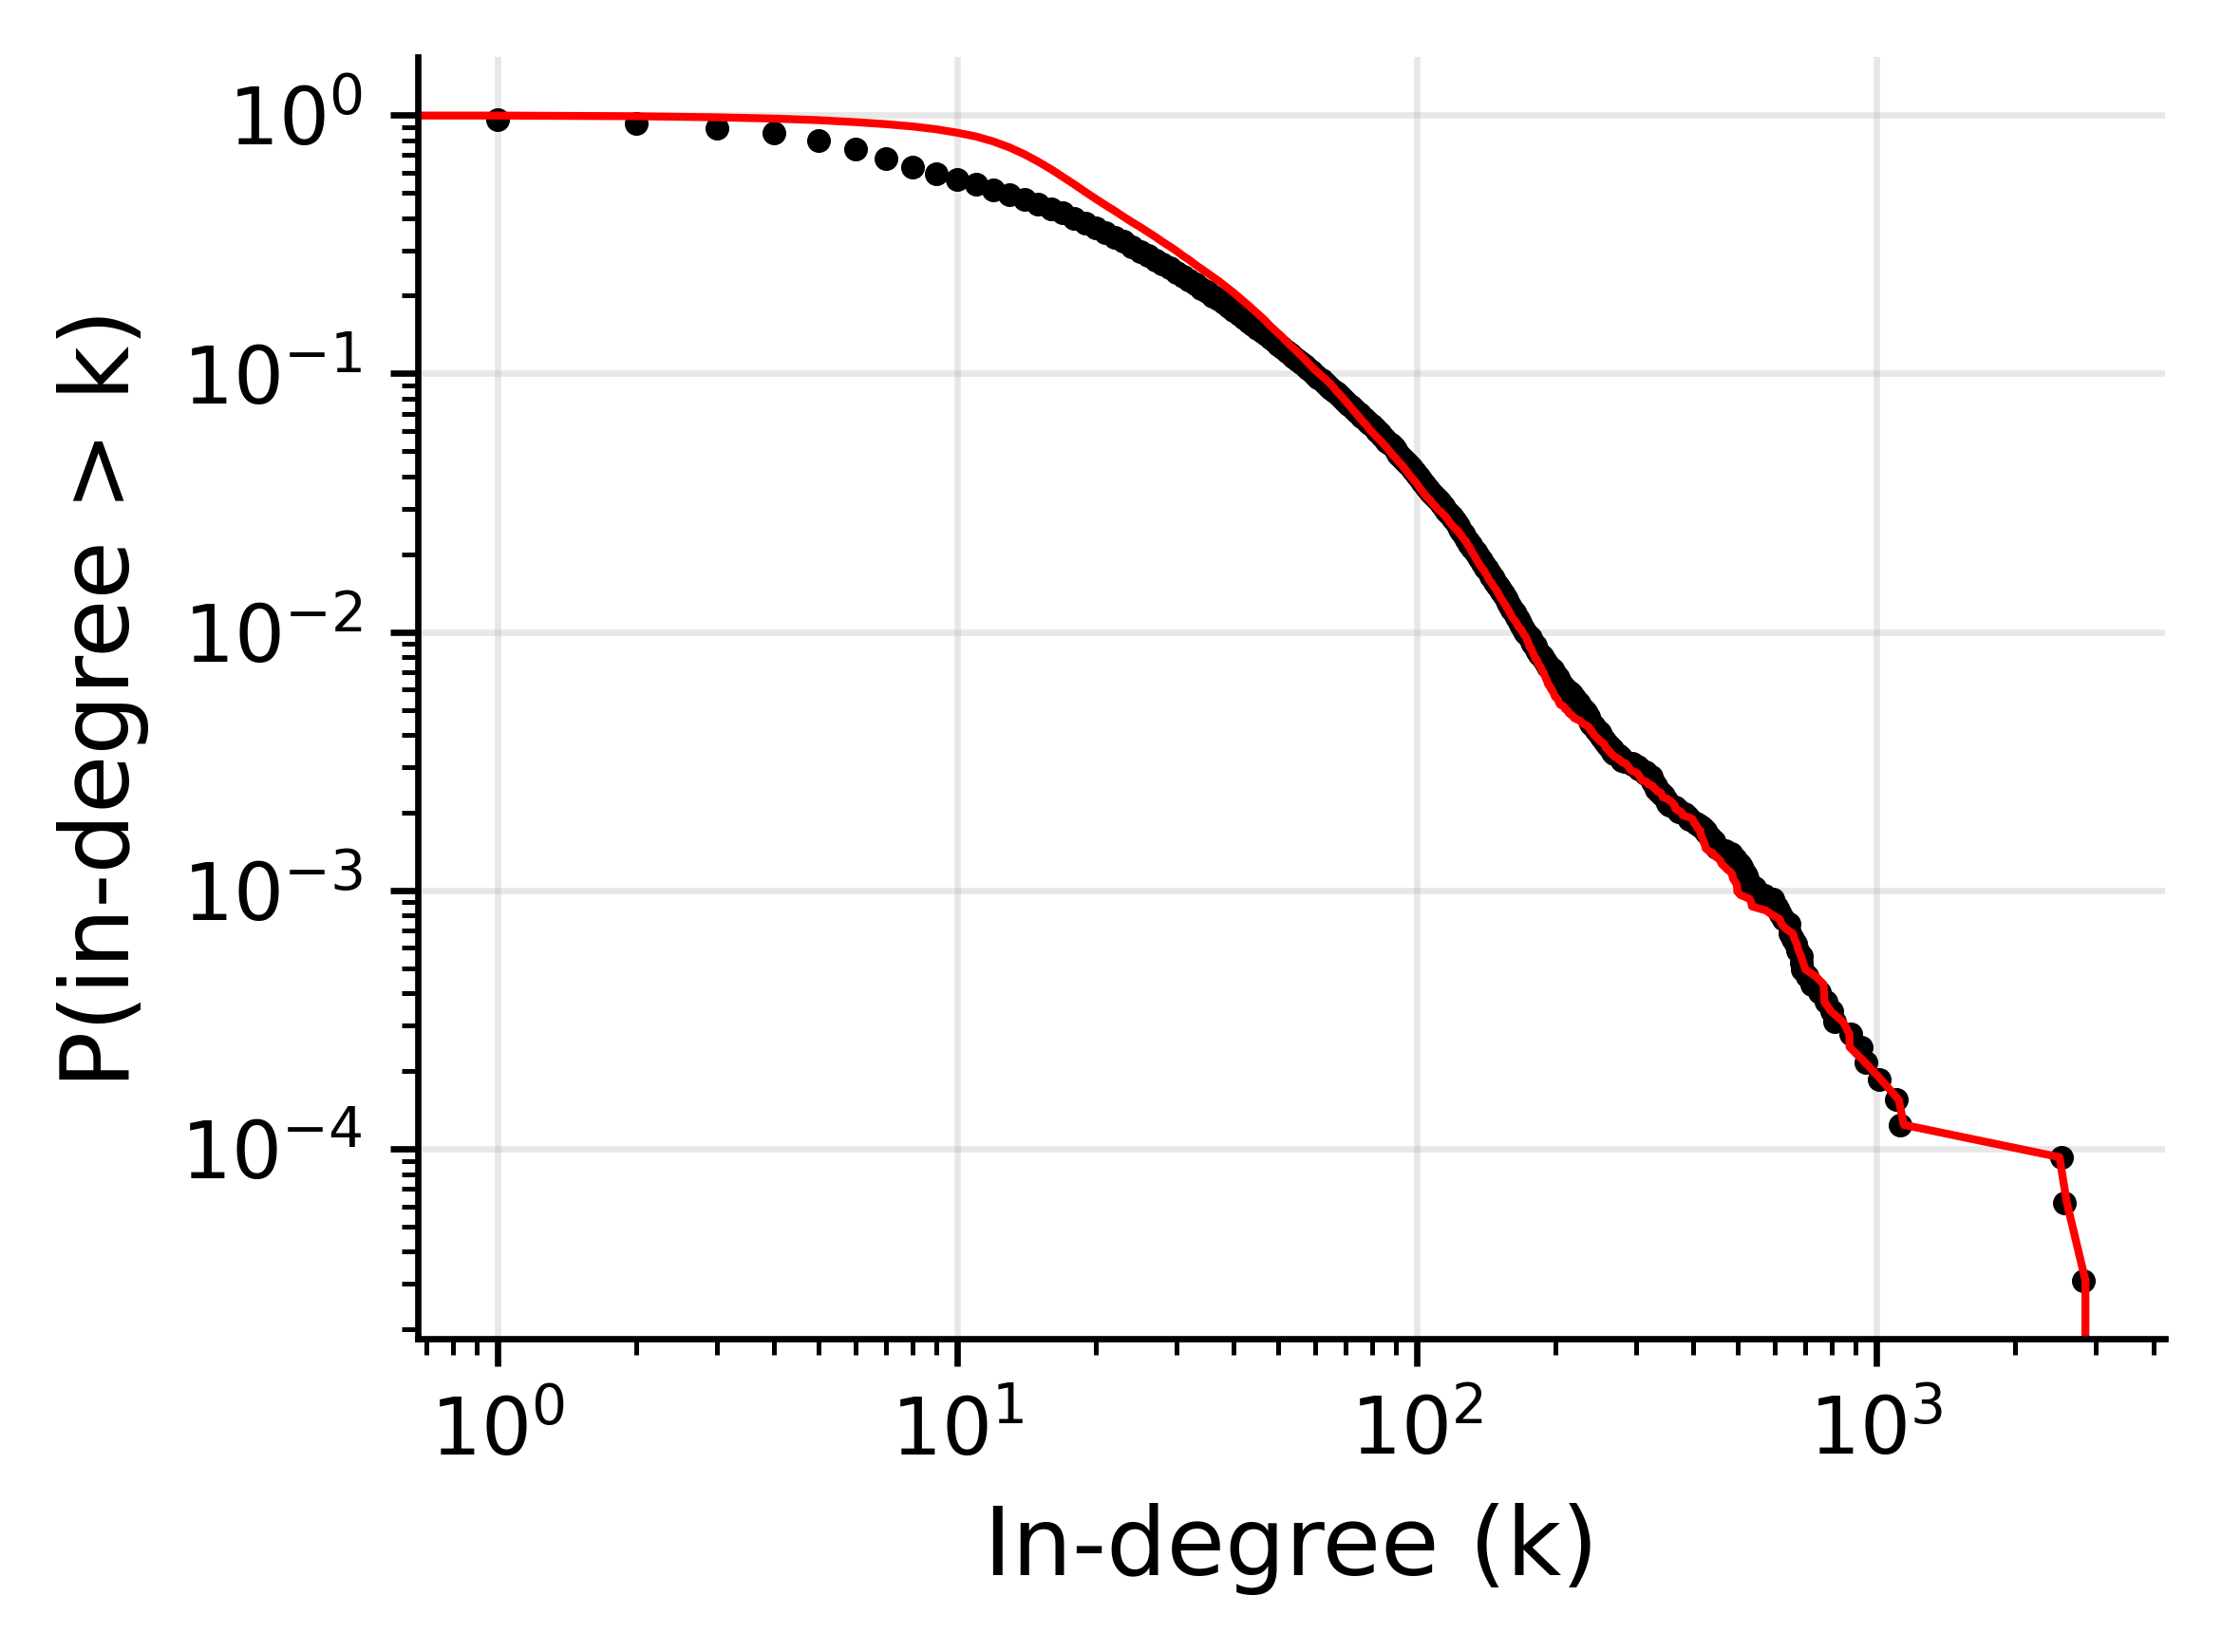

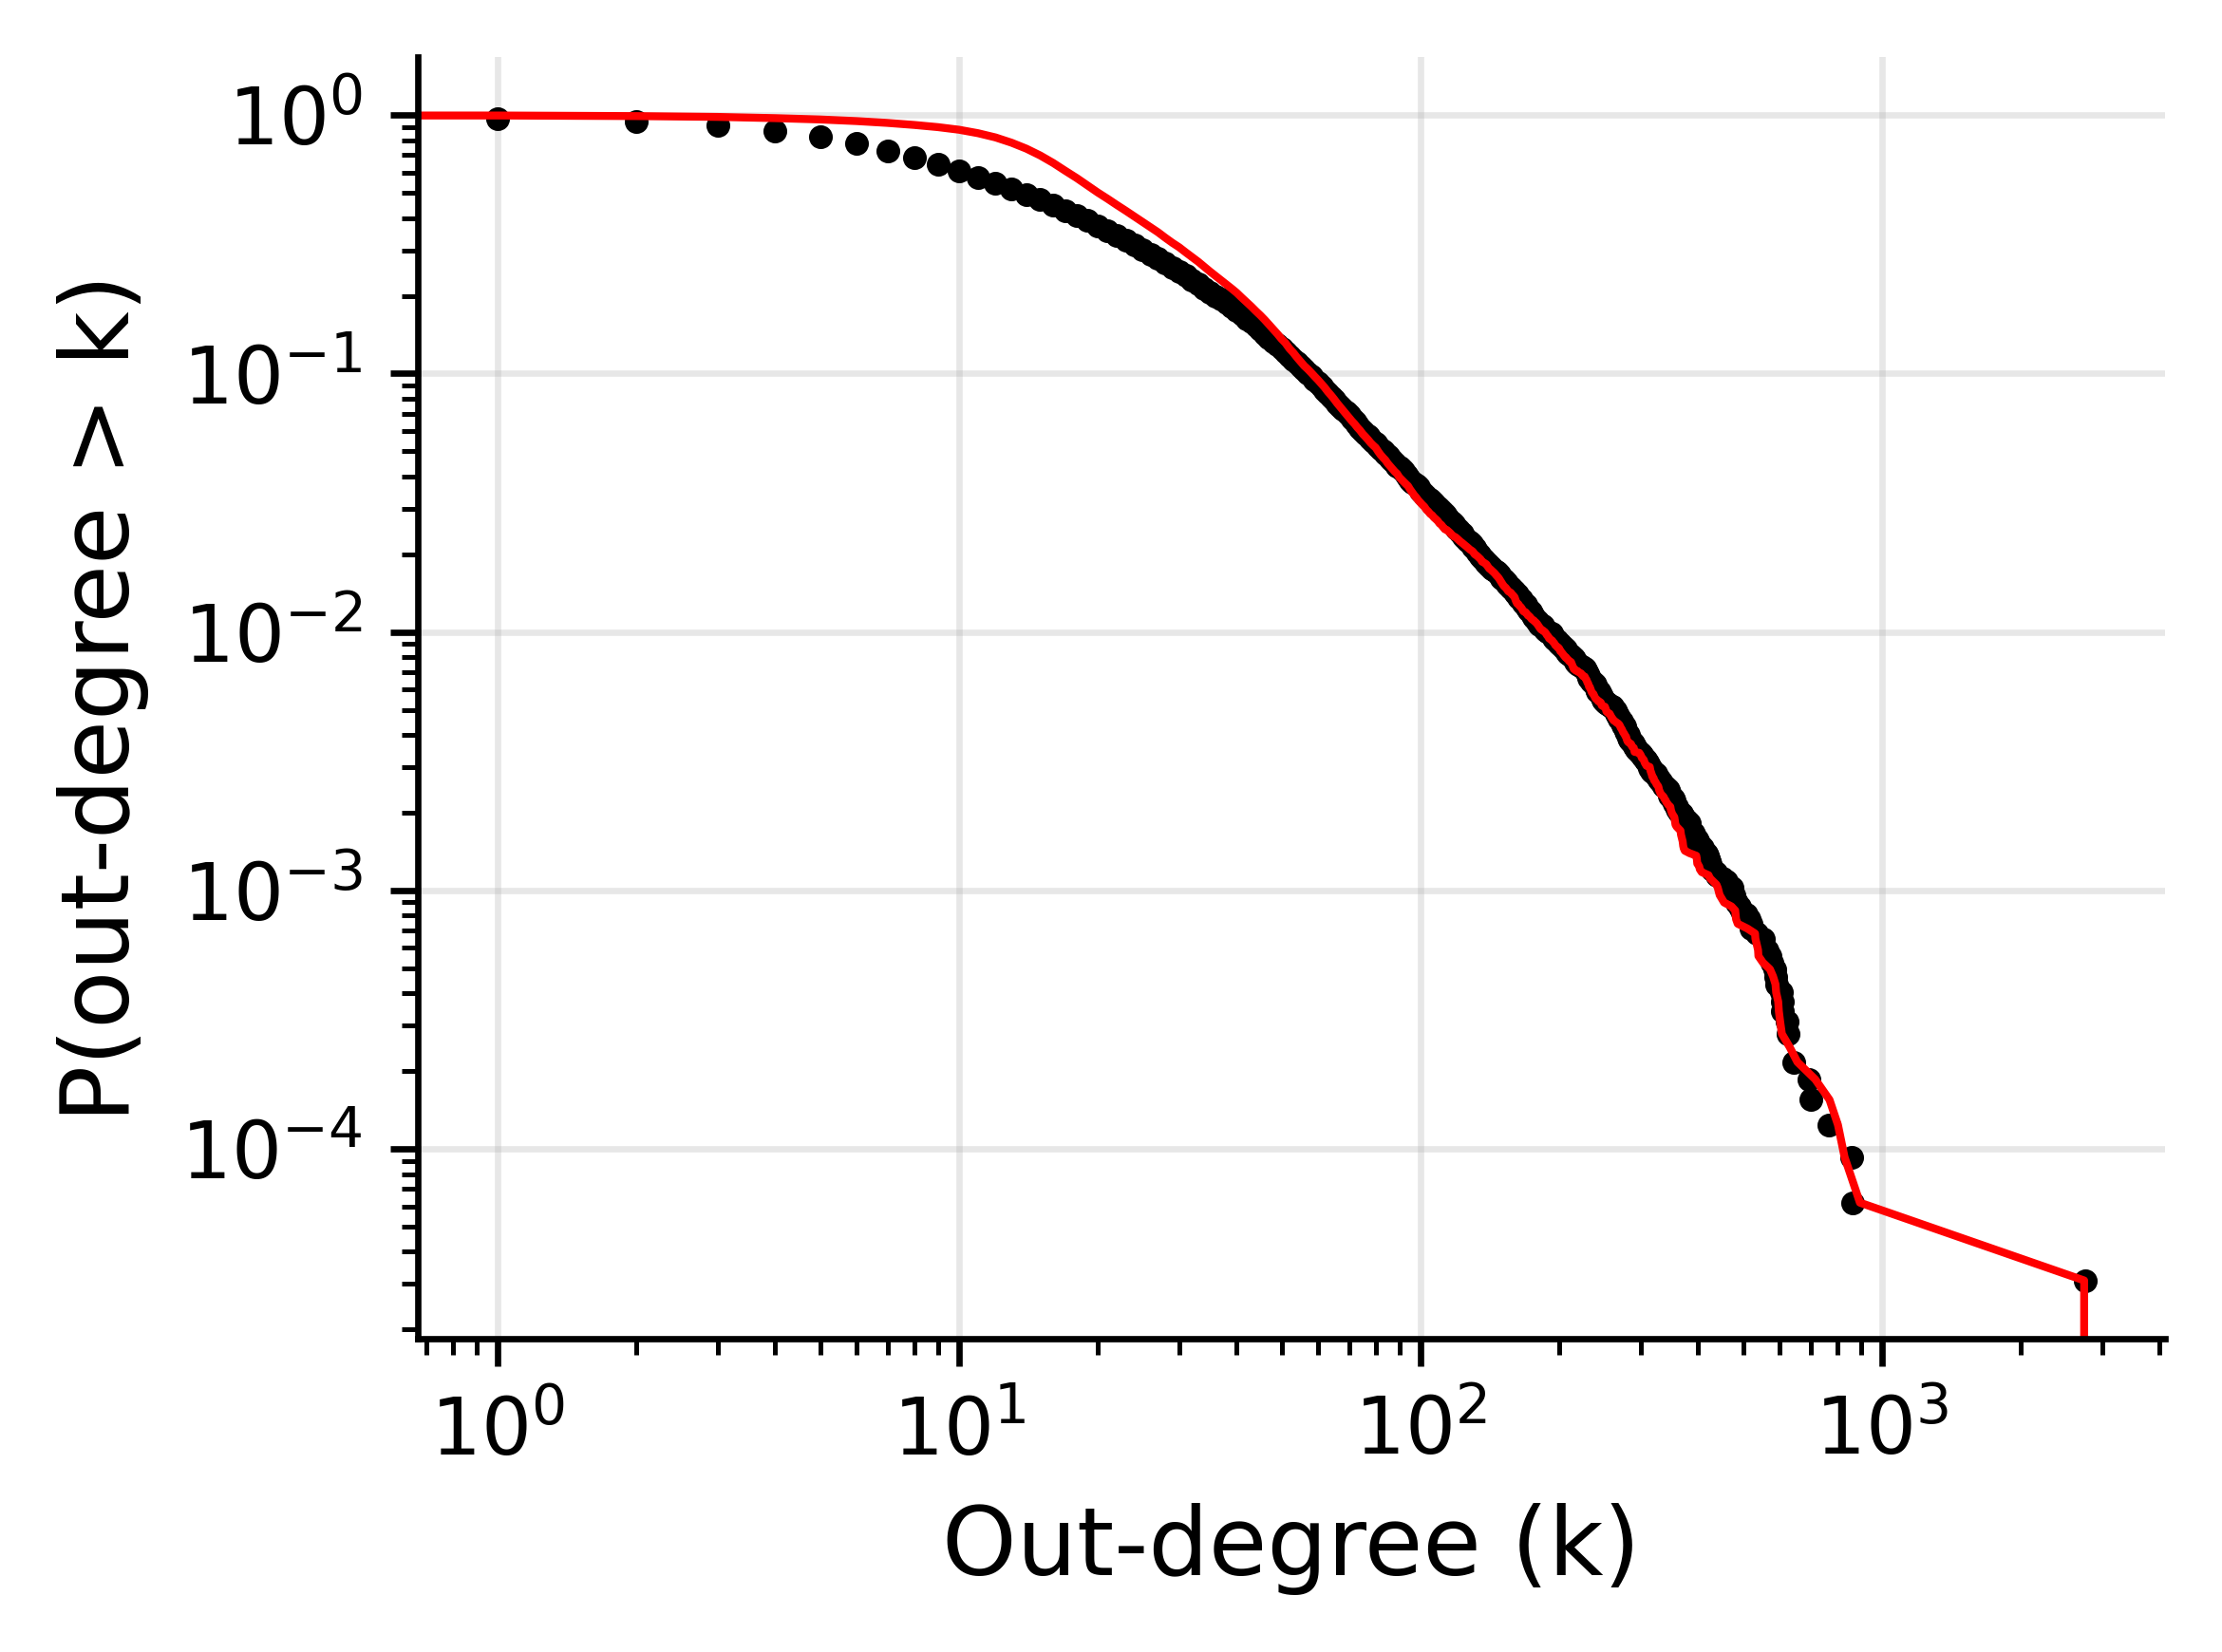

In [41]:
# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(4, 3),dpi=600)
plt.loglog(x_orig_in, y_orig_in, '.', markersize=4, linewidth=1, label='Original Network',color='black')
plt.loglog(x_bcnm_in, y_bcnm_in, '-', markersize=4, linewidth=1, label='BCNM Model',color='red')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
# plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
# plt.legend()
plt.tight_layout()
# Remove the top and right spines for a cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('plots/bcnm_cumulative_in_degree.pdf')
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(4, 3),dpi=600)
plt.loglog(x_orig_out, y_orig_out, '.', markersize=4, linewidth=1, label='Original Network',color='black')
plt.loglog(x_bcnm_out, y_bcnm_out, '-', markersize=4, linewidth=1, label='BCNM Model',color='red')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
# plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
# plt.legend()
# Remove the top and right spines for a cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.pdf')
print("Saved cumulative out-degree distribution plot at 600dpi")

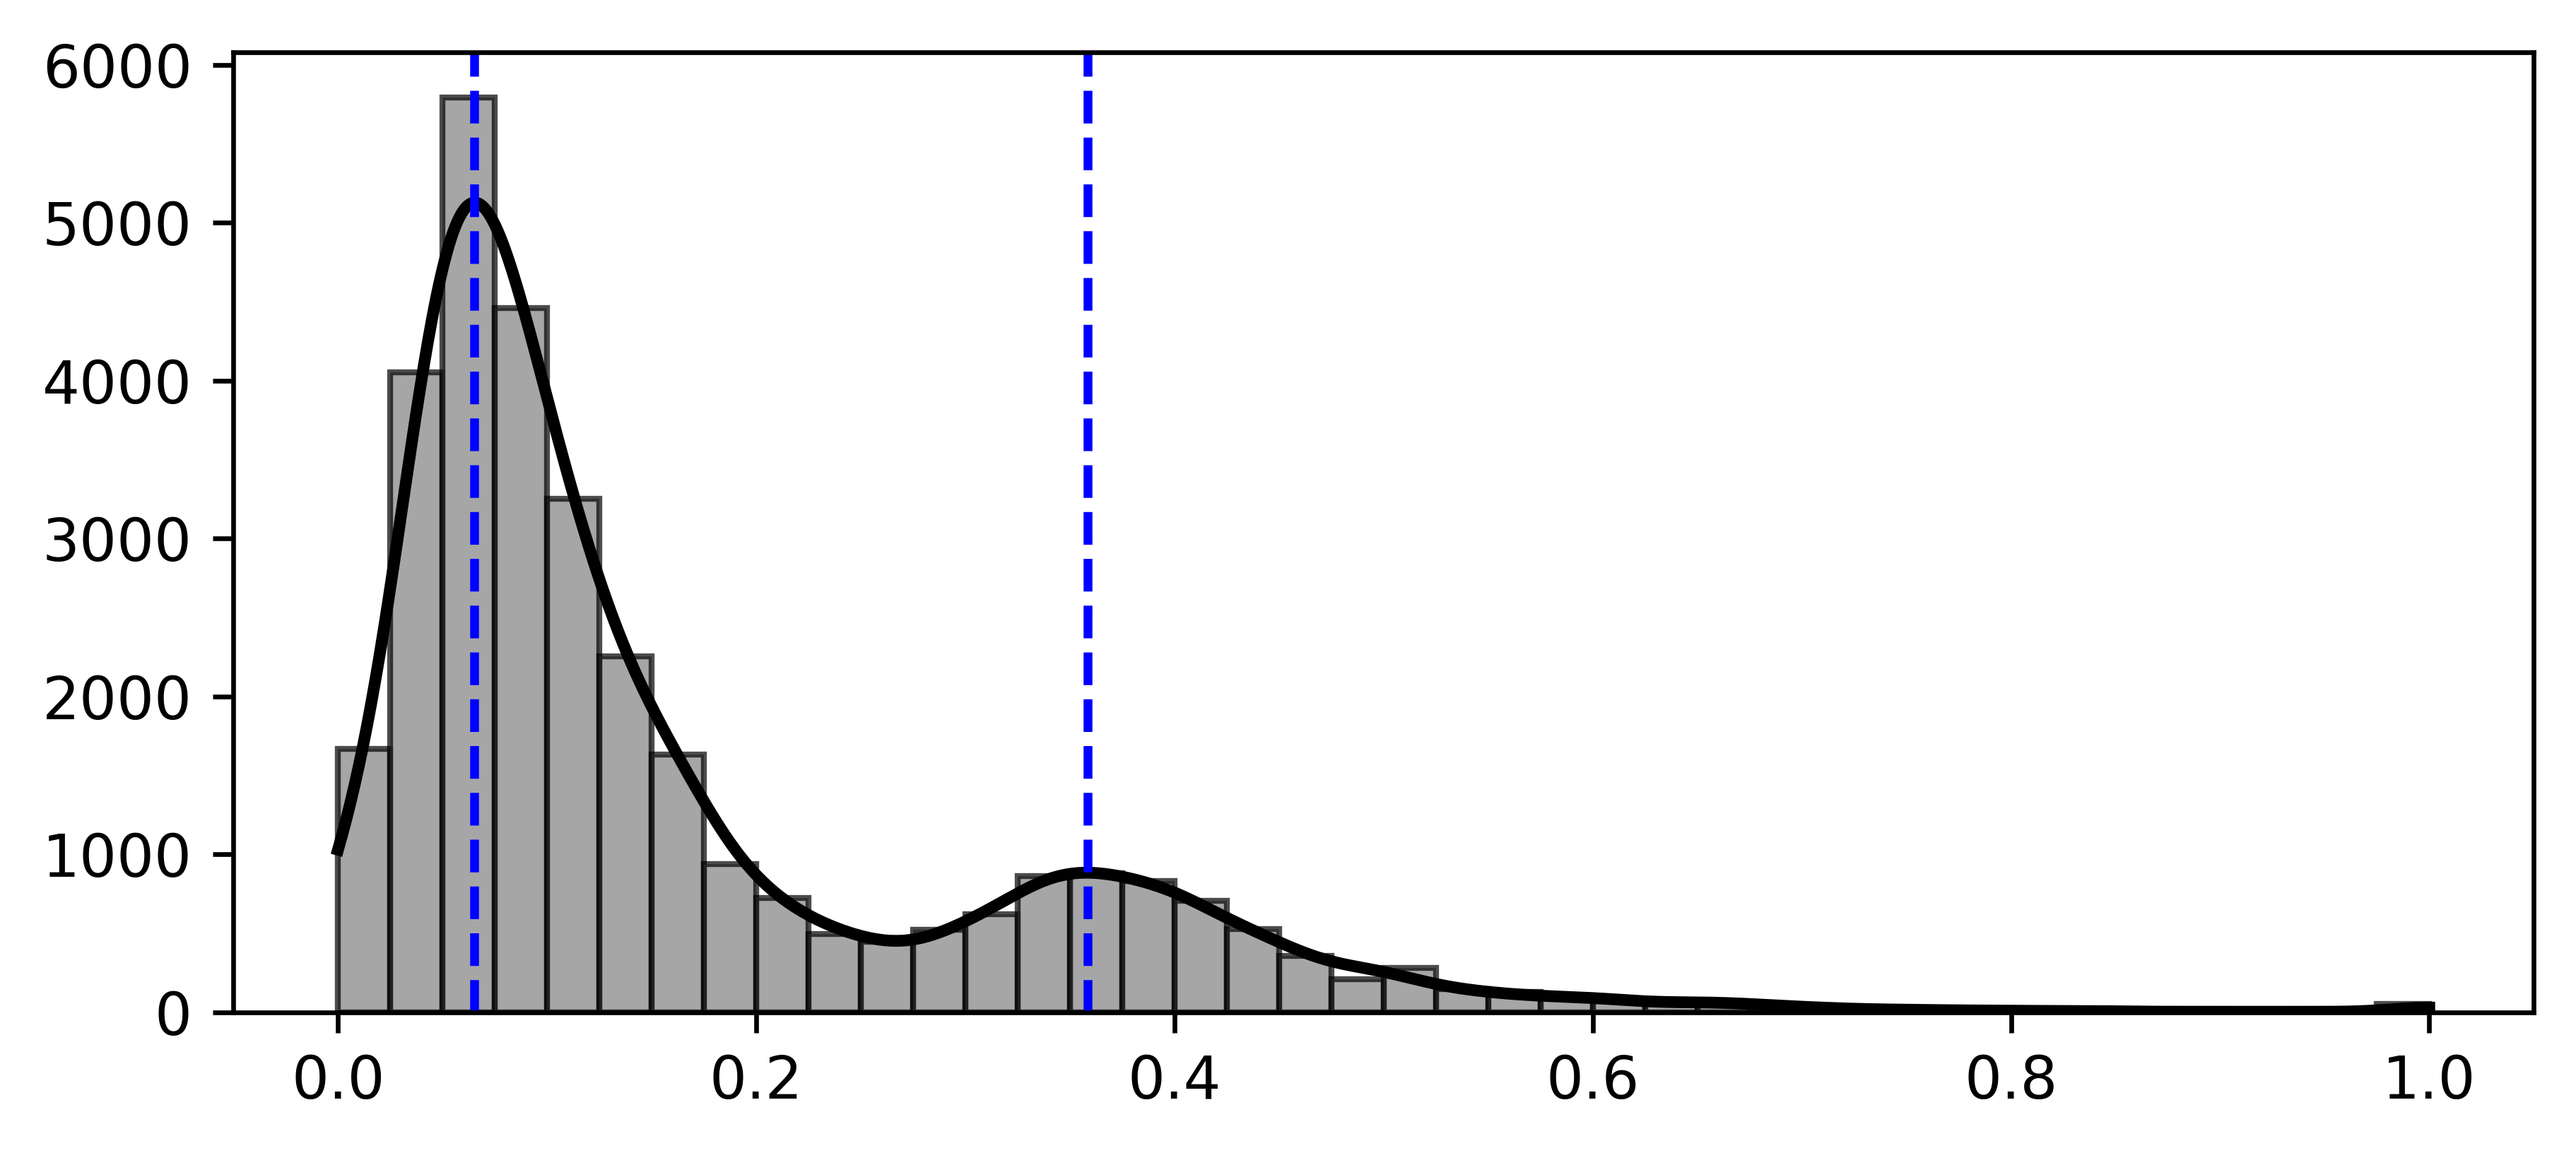

In [21]:
# Plot clustering coefficient distributions with raw counts (not normalized)
plt.figure(figsize=(7, 3),dpi=600)

# Create bins manually to ensure consistency
bins = np.linspace(0, 1, 41)  # 20 bins from 0 to 1

# Plot histograms with raw counts
plt.hist(original_clustering_values, bins=bins, alpha=0.7, color='gray', edgecolor='black', label='Original Network')


# Sort peaks by height
if len(peak_y) > 0:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]  # Get top 2 peaks

    # Add peak markers
    for i, idx in enumerate(top_peaks):
        x_pos = peak_x[idx]
        plt.axvline(x=x_pos, color='b', linestyle='--', label=f'Original Peak {i+1}: {x_pos:.4f}')


Calculating Euclidean distances between connected nodes...
Calculating distances for original network...
Calculating distances for BCNM network...
Original network: 849981 valid connections with distance data
BCNM network: 1006678 valid connections with distance data
Original network average connection length: 118.1249 μm
BCNM network average connection length: 130.4427 μm
Original network max connection length: 429.0556 μm
BCNM network max connection length: 437.9623 μm
Saved connection length distribution plot at 600dpi
Saved log-scale connection length distribution plot at 600dpi
Calculating cumulative connection length distributions...
Saved cumulative connection length distribution plot at 600dpi
Creating scatter plot of connection length vs clustering coefficient...
Saved distance vs clustering coefficient plot at 600dpi


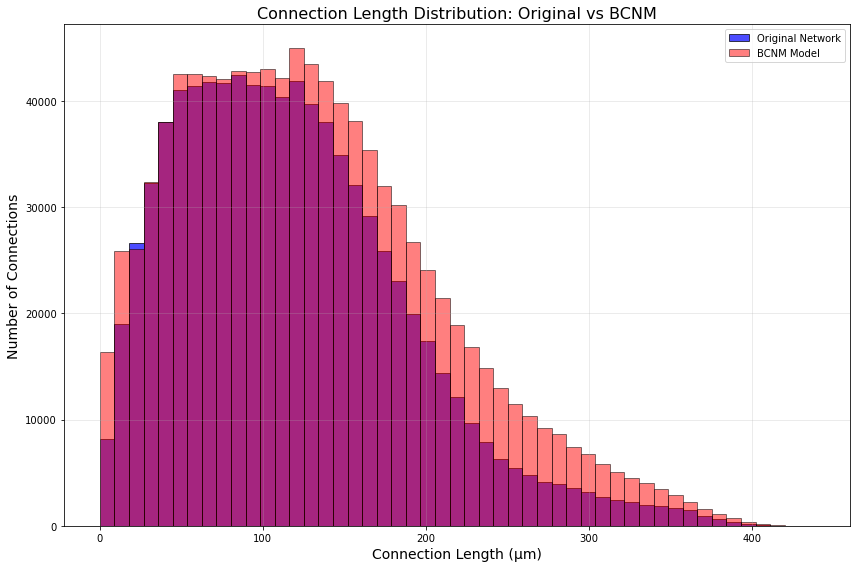

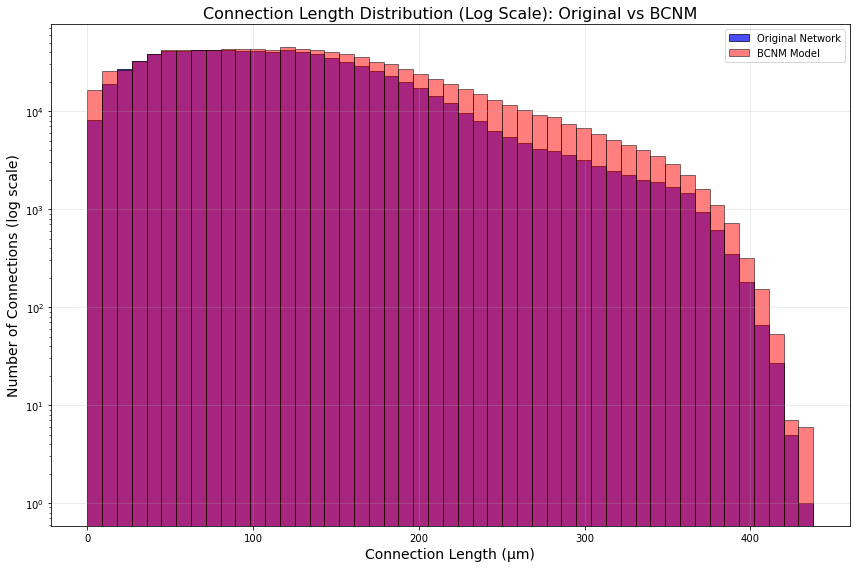

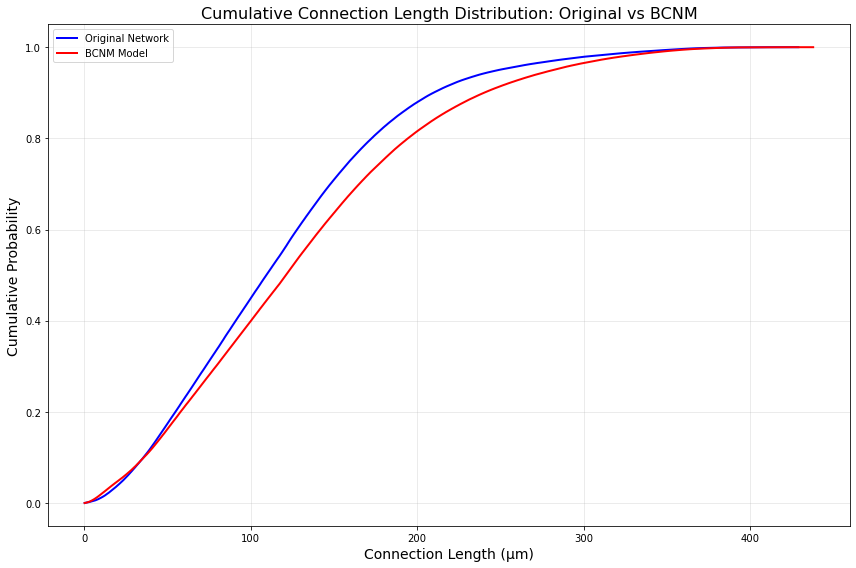

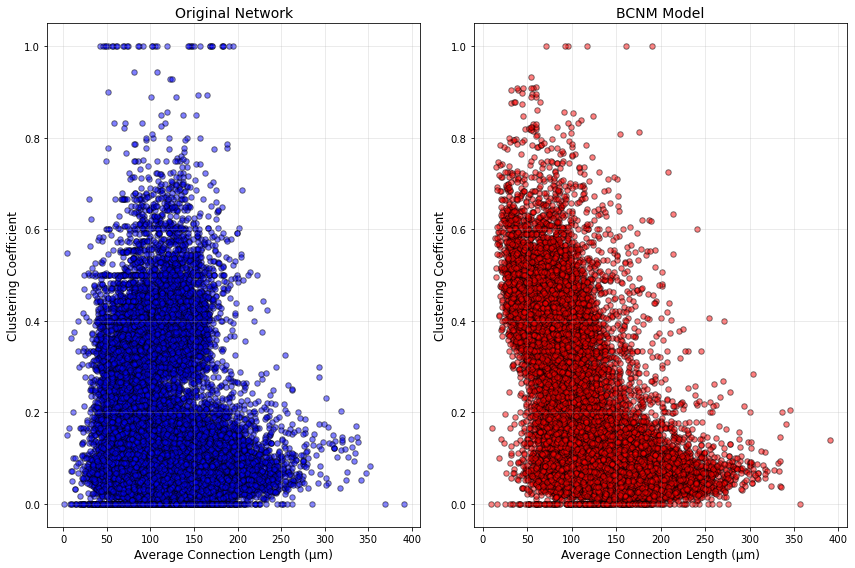

In [33]:
# Calculate Euclidean distances between connected nodes
print("Calculating Euclidean distances between connected nodes...")

def calculate_euclidean_distance(graph, edge):
    u, v = edge
    # Get coordinates from the graph nodes
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    
    # Calculate Euclidean distance
    dist = np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    
    # Convert from nanometers to micrometers
    return dist / 1000.0  # 1 micrometer = 1000 nanometers

# Calculate distances for original network
print("Calculating distances for original network...")
original_distances = []
for edge in G.edges():
    try:
        distance = calculate_euclidean_distance(G, edge)
        original_distances.append(distance)
    except KeyError:
        # Skip if coordinates are missing
        continue

# Calculate distances for BCNM network
print("Calculating distances for BCNM network...")
bcnm_distances = []
for edge in bcnm_graph.edges():
    try:
        distance = calculate_euclidean_distance(bcnm_graph, edge)
        bcnm_distances.append(distance)
    except KeyError:
        # Skip if coordinates are missing
        continue

print(f"Original network: {len(original_distances)} valid connections with distance data")
print(f"BCNM network: {len(bcnm_distances)} valid connections with distance data")

print(f"Original network average connection length: {np.mean(original_distances):.4f} μm")
print(f"BCNM network average connection length: {np.mean(bcnm_distances):.4f} μm")
print(f"Original network max connection length: {np.max(original_distances):.4f} μm")
print(f"BCNM network max connection length: {np.max(bcnm_distances):.4f} μm")

# Plot raw connection length distributions (not normalized)
plt.figure(figsize=(12, 8))

# Create common bins for both distributions
max_dist = max(np.max(original_distances), np.max(bcnm_distances))
bins = np.linspace(0, max_dist, 50)

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_distances, bins=bins, alpha=0.7, 
                                     color='blue', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_distances, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

plt.xlabel('Connection Length (μm)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution plot at 600dpi")

# Plot with log scale on y-axis for better visibility of tail
plt.figure(figsize=(12, 8))
plt.hist(original_distances, bins=bins, alpha=0.7, color='blue', 
         edgecolor='black', label='Original Network')
plt.hist(bcnm_distances, bins=bins, alpha=0.5, color='red', 
         edgecolor='black', label='BCNM Model')
plt.yscale('log')
plt.xlabel('Connection Length (μm)', fontsize=14)
plt.ylabel('Number of Connections (log scale)', fontsize=14)
plt.title('Connection Length Distribution (Log Scale): Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution plot at 600dpi")

# Calculate cumulative distributions
print("Calculating cumulative connection length distributions...")

# Sort the distances
sorted_original_distances = np.sort(original_distances)
sorted_bcnm_distances = np.sort(bcnm_distances)

# Calculate cumulative distributions
y_orig = np.arange(1, len(sorted_original_distances) + 1) / len(sorted_original_distances)
y_bcnm = np.arange(1, len(sorted_bcnm_distances) + 1) / len(sorted_bcnm_distances)

# Plot cumulative distributions
plt.figure(figsize=(12, 8))
plt.plot(sorted_original_distances, y_orig, 'b-', linewidth=2, label='Original Network')
plt.plot(sorted_bcnm_distances, y_bcnm, 'r-', linewidth=2, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Connection Length (μm)', fontsize=14)
plt.ylabel('Cumulative Probability', fontsize=14)
plt.title('Cumulative Connection Length Distribution: Original vs BCNM', fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_connection_length.png', dpi=600)
print("Saved cumulative connection length distribution plot at 600dpi")

# Create scatter plot of connection length vs clustering coefficient
print("Creating scatter plot of connection length vs clustering coefficient...")

# Calculate average connection length for each node
node_avg_distances_orig = {}
for node in G.nodes():
    distances = []
    for neighbor in G.neighbors(node):
        try:
            edge = (node, neighbor)
            distance = calculate_euclidean_distance(G, edge)
            distances.append(distance)
        except KeyError:
            continue
    
    if distances:
        node_avg_distances_orig[node] = np.mean(distances)

node_avg_distances_bcnm = {}
for node in bcnm_graph.nodes():
    distances = []
    for neighbor in bcnm_graph.neighbors(node):
        try:
            edge = (node, neighbor)
            distance = calculate_euclidean_distance(bcnm_graph, edge)
            distances.append(distance)
        except KeyError:
            continue
    
    if distances:
        node_avg_distances_bcnm[node] = np.mean(distances)

# Create scatter plots
plt.figure(figsize=(12, 8))

# Original network
plt.subplot(1, 2, 1)
orig_nodes = [node for node in G.nodes() if node in node_avg_distances_orig and node in clustering]
plt.scatter([node_avg_distances_orig[n] for n in orig_nodes],
            [clustering[n] for n in orig_nodes],
            alpha=0.5, s=30, c='blue', edgecolors='black')
plt.xlabel('Average Connection Length (μm)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Original Network', fontsize=14)
plt.grid(True, alpha=0.3)

# BCNM network
plt.subplot(1, 2, 2)
bcnm_nodes = [node for node in bcnm_graph.nodes() if node in node_avg_distances_bcnm and node in bcnm_clustering]
plt.scatter([node_avg_distances_bcnm[n] for n in bcnm_nodes],
            [bcnm_clustering[n] for n in bcnm_nodes],
            alpha=0.5, s=30, c='red', edgecolors='black')
plt.xlabel('Average Connection Length (μm)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('BCNM Model', fontsize=14)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('plots/bcnm_distance_vs_clustering.png', dpi=600)
print("Saved distance vs clustering coefficient plot at 600dpi")

Saved connection length distribution plot at 600dpi


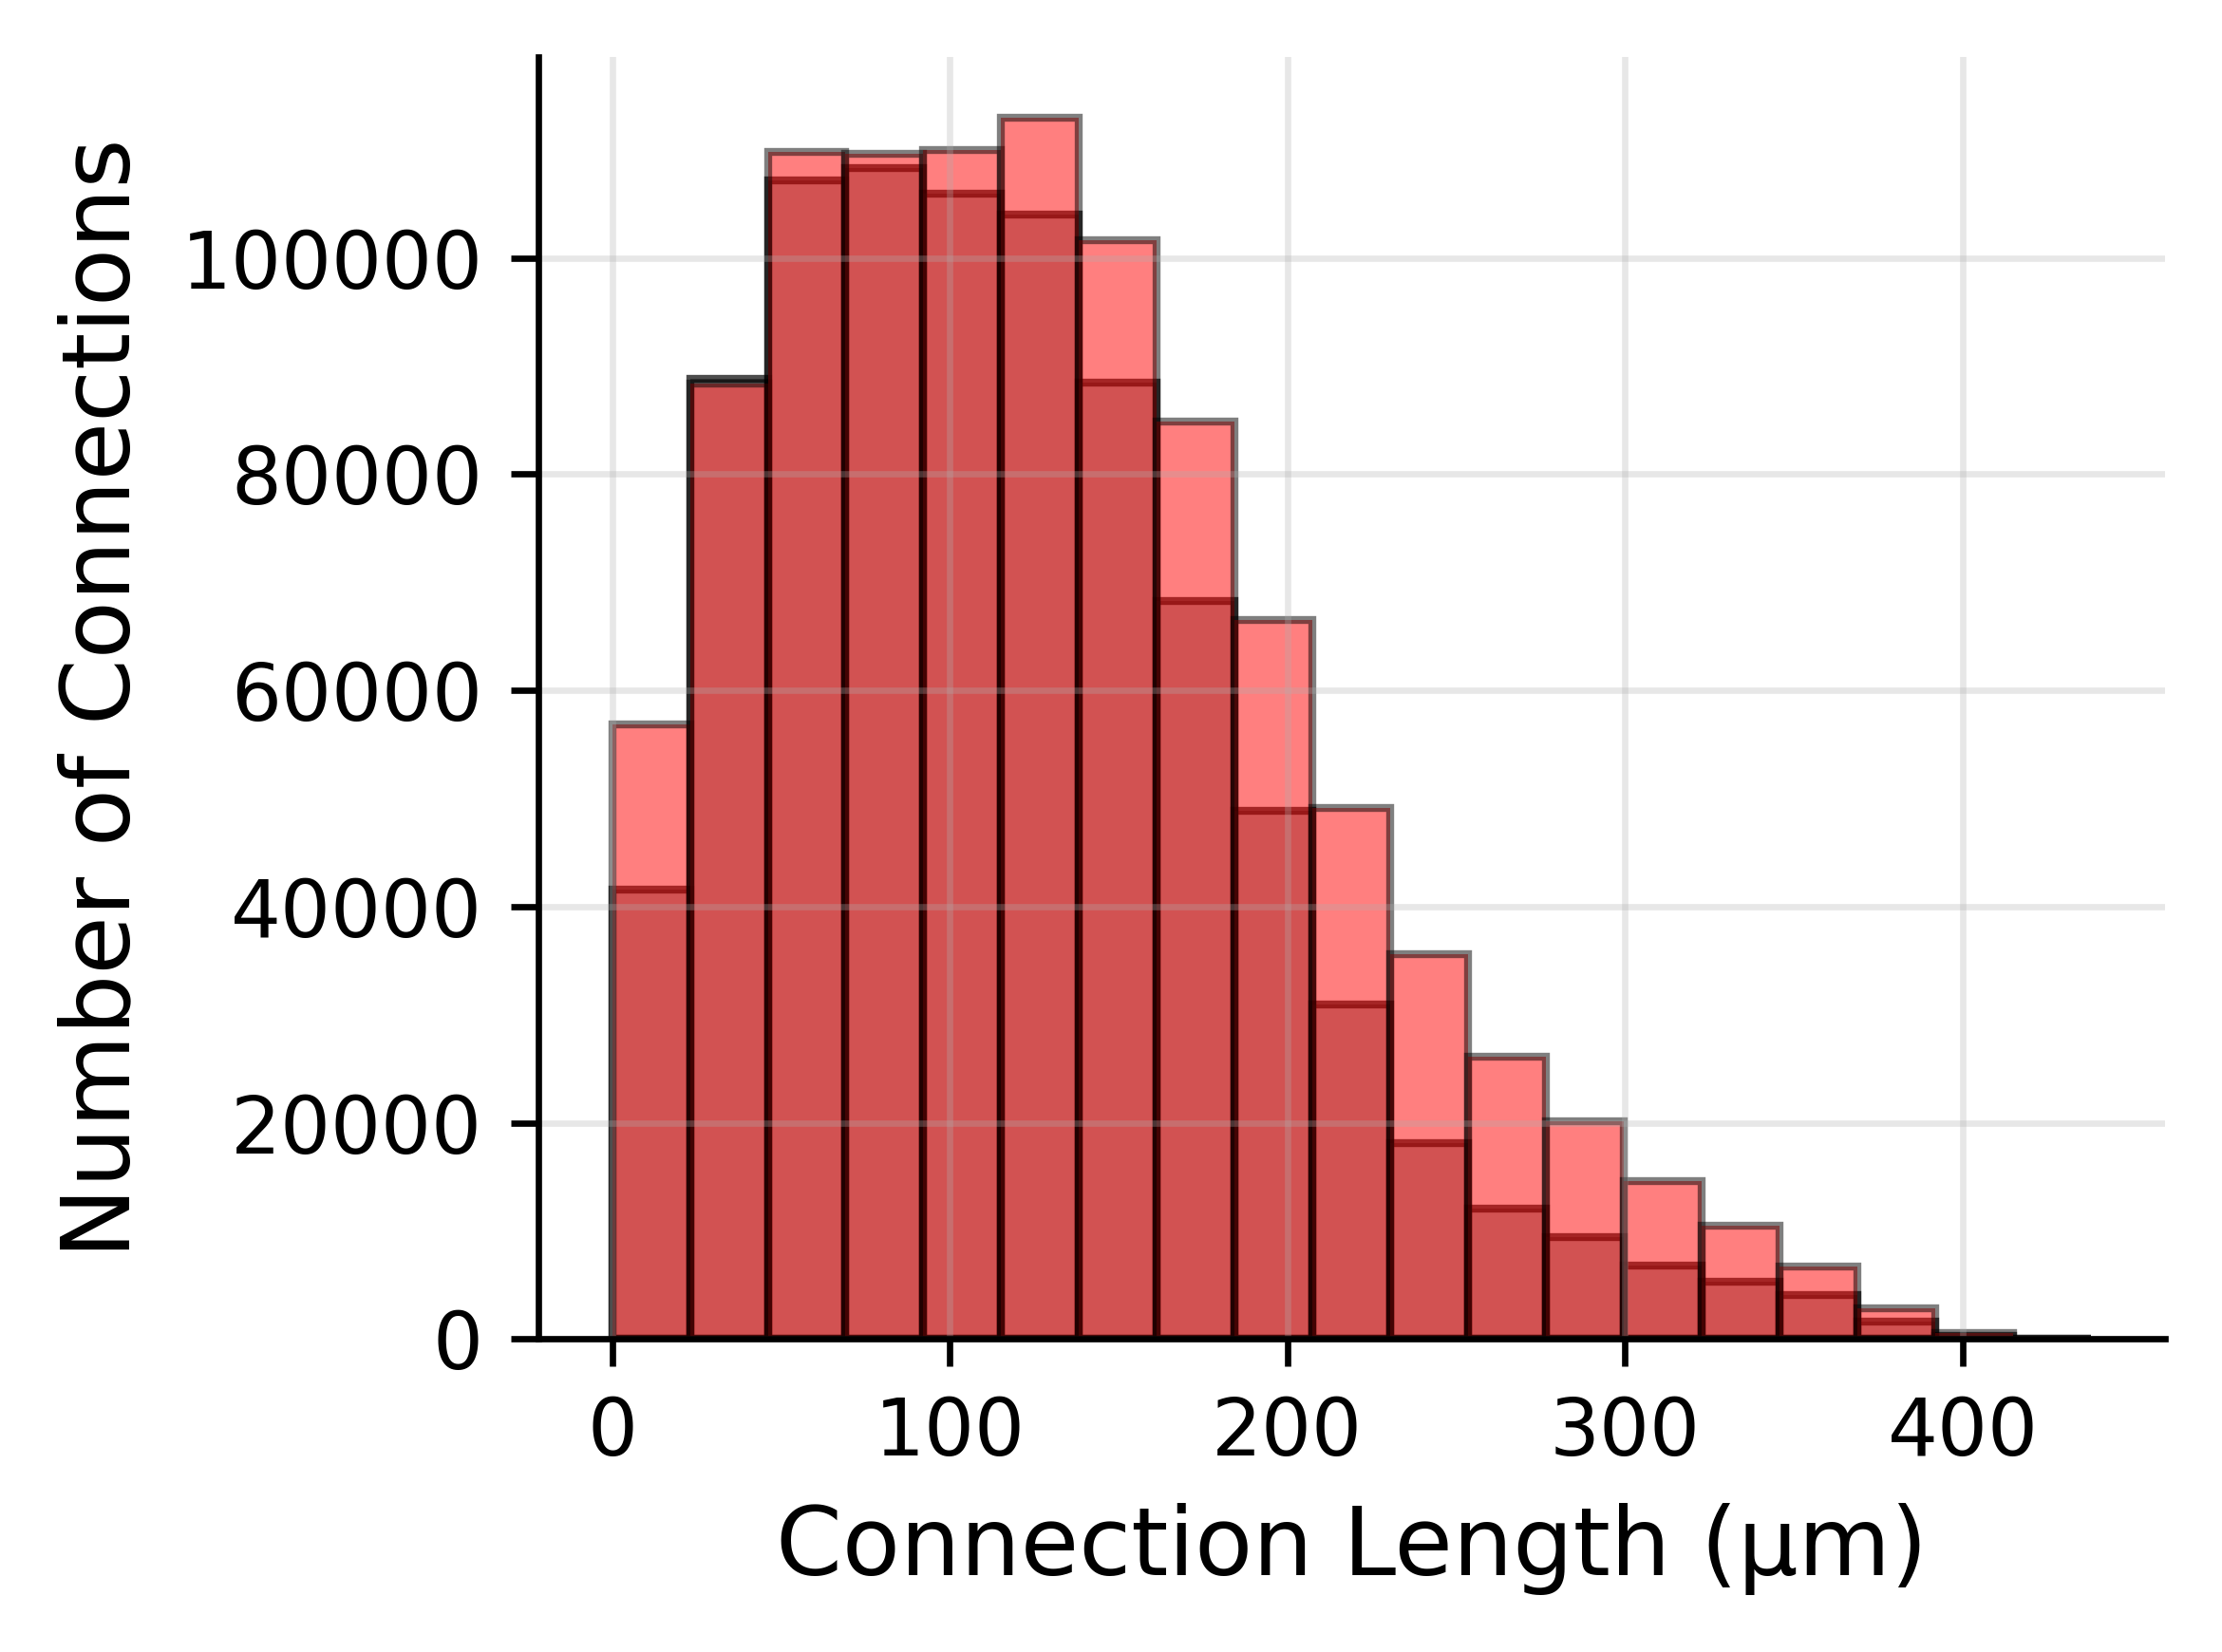

In [42]:
# Plot raw connection length distributions (not normalized)
plt.figure(figsize=(4, 3),dpi=600)

# Create common bins for both distributions
max_dist = max(np.max(original_distances), np.max(bcnm_distances))
bins = np.linspace(0, max_dist, 20)

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_distances, bins=bins, alpha=0.7, 
                                     color='grey', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_distances, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

plt.xlabel('Connection Length (μm)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
# plt.title('Connection Length Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)

# Remove the top and right spines for a cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_connection_length_distribution.pdf', dpi=600)
print("Saved connection length distribution plot at 600dpi")

Saved combined scatter plot at 600dpi


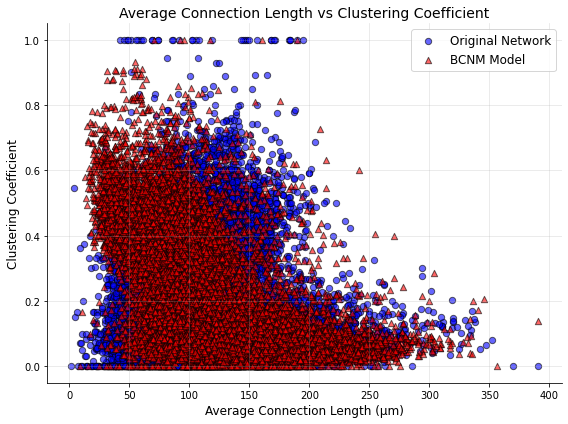

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Original network: blue circles
orig_nodes = [node for node in G.nodes() if node in node_avg_distances_orig and node in clustering]
orig_x = [node_avg_distances_orig[n] for n in orig_nodes]
orig_y = [clustering[n] for n in orig_nodes]
plt.scatter(orig_x, orig_y, alpha=0.6, s=40, color='black', edgecolors='black', marker='o', label='Original Network')

# BCNM network: red triangles
bcnm_nodes = [node for node in bcnm_graph.nodes() if node in node_avg_distances_bcnm and node in bcnm_clustering]
bcnm_x = [node_avg_distances_bcnm[n] for n in bcnm_nodes]
bcnm_y = [bcnm_clustering[n] for n in bcnm_nodes]
plt.scatter(bcnm_x, bcnm_y, alpha=0.6, s=40, color='red', edgecolors='black', marker='^', label='SBM + Clustering')

plt.xlabel('Average Connection Length (μm)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Average Connection Length vs Clustering Coefficient', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Remove the top and right spines for a cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/bcnm_distance_vs_clustering_combined.png', dpi=600)
print("Saved combined scatter plot at 600dpi")


Calculating R² and RMSE metrics for network comparisons...

--- In-degree Distribution Metrics ---
In-degree Frequency Distribution: R² = nan, RMSE = 0.0000
In-degree Cumulative Distribution (log-log): R² = 0.9964, RMSE = 0.0471


/Users/oliver/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Saved in-degree metrics visualization at 600dpi

--- Out-degree Distribution Metrics ---
Out-degree Frequency Distribution: R² = nan, RMSE = 0.0000
Out-degree Cumulative Distribution (log-log): R² = 0.9970, RMSE = 0.0484


/Users/oliver/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Saved out-degree metrics visualization at 600dpi

--- Clustering Coefficient Distribution Metrics ---
Clustering Coefficient Distribution: R² = 0.9213, RMSE = 0.0279
Saved clustering coefficient metrics visualization at 600dpi

--- Connection Length Distribution Metrics ---
Connection Length Distribution: R² = 0.9729, RMSE = 0.0041
Saved connection length metrics visualization at 600dpi

Summary of Metrics:
-----------------------------------------------
Metric                             | R²      | RMSE
-----------------------------------------------
In-degree Distribution            | nan  | 0.0000
In-degree Cumulative (log-log)   | 0.9964  | 0.0471
Out-degree Distribution           | nan  | 0.0000
Out-degree Cumulative (log-log)  | 0.9970  | 0.0484
Clustering Coefficient            | 0.9213  | 0.0279
Connection Length                | 0.9729  | 0.0041
-----------------------------------------------


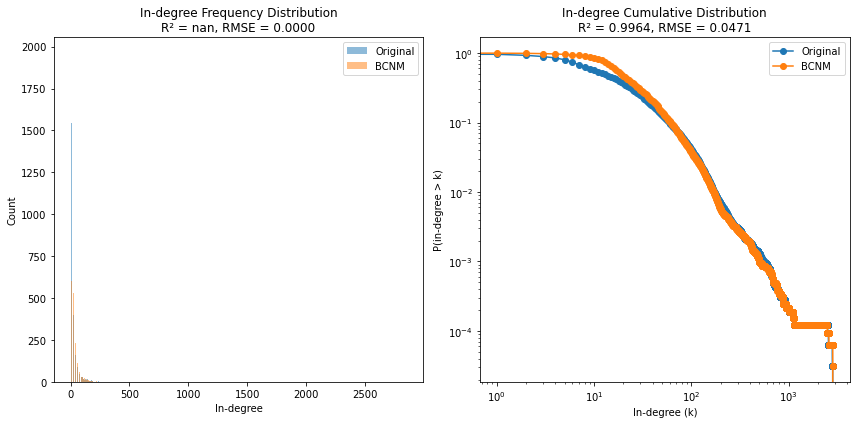

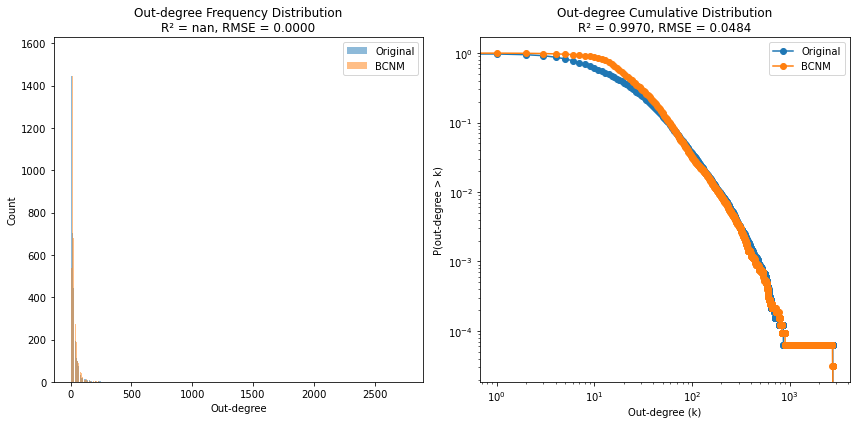

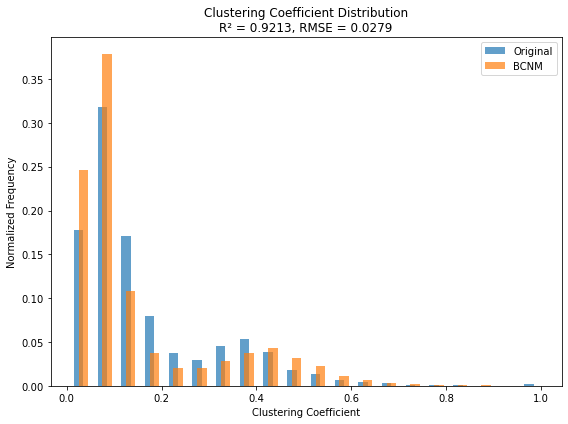

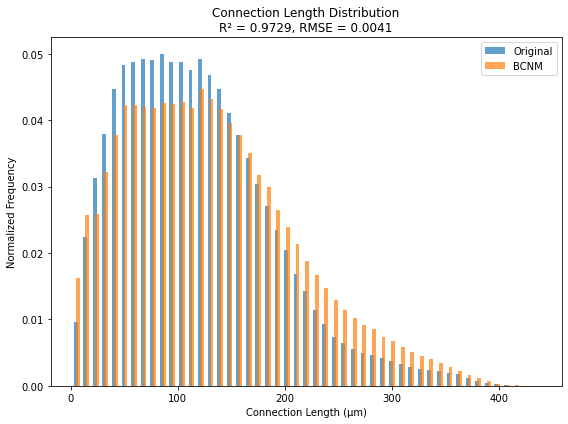

In [43]:
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from collections import Counter

print("Calculating R² and RMSE metrics for network comparisons...")

def calculate_metrics(original_data, model_data, bin_edges=None, normalize=False):
    """
    Calculate R² and RMSE metrics for comparing distributions.
    
    Parameters:
    - original_data: Data points from the original network
    - model_data: Data points from the model network
    - bin_edges: Optional bin edges for histograms. If None, use the same bins for both datasets.
    - normalize: If True, normalize the histograms to sum to 1
    
    Returns:
    - r_squared: R² value
    - rmse: Root Mean Square Error
    - hist_orig: Histogram counts for original data
    - hist_model: Histogram counts for model data
    - bin_centers: Centers of the bins
    """
    if bin_edges is None:
        # Create common bins covering both datasets
        min_val = min(min(original_data), min(model_data))
        max_val = max(max(original_data), max(model_data))
        bin_edges = np.linspace(min_val, max_val, 50)
    
    # Calculate histograms
    hist_orig, _ = np.histogram(original_data, bins=bin_edges)
    hist_model, _ = np.histogram(model_data, bins=bin_edges)
    
    # Normalize if requested
    if normalize:
        hist_orig = hist_orig / np.sum(hist_orig)
        hist_model = hist_model / np.sum(hist_model)
    
    # Calculate bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Calculate metrics only on bins where either distribution has data
    mask = (hist_orig > 0) | (hist_model > 0)
    if np.sum(mask) > 1:  # Need at least 2 points for meaningful regression
        # Calculate R²
        if np.sum(mask) > 2:  # pearsonr needs at least 3 points
            r_value, p_value = stats.pearsonr(hist_orig[mask], hist_model[mask])
            r_squared = r_value ** 2
        else:
            r_squared = np.nan
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(hist_orig[mask], hist_model[mask]))
    else:
        r_squared = np.nan
        rmse = np.nan
    
    return r_squared, rmse, hist_orig, hist_model, bin_centers

# Helper function to prepare degree distribution data
def prepare_degree_counts(degrees_dict):
    max_degree = max(degrees_dict.values())
    counts = [0] * (max_degree + 1)
    for degree in degrees_dict.values():
        counts[degree] += 1
    return counts

# Helper function to prepare cumulative degree distribution
def prepare_cumulative_distribution(counts):
    total = sum(counts)
    cumulative = []
    count_so_far = 0
    for count in counts:
        count_so_far += count
        cumulative.append(1 - count_so_far / total)  # P(degree > k)
    return cumulative

# 1. In-degree Distribution
print("\n--- In-degree Distribution Metrics ---")

# Get the data
original_in_degrees = list(dict(G.in_degree()).values())
bcnm_in_degrees = list(dict(bcnm_graph.in_degree()).values())

# Create degree counts (frequency distribution)
max_in_degree = max(max(original_in_degrees), max(bcnm_in_degrees))
original_in_degree_counts = Counter(original_in_degrees)
bcnm_in_degree_counts = Counter(bcnm_in_degrees)

# Convert to arrays for full range of degrees
orig_in_counts = np.array([original_in_degree_counts.get(d, 0) for d in range(max_in_degree + 1)])
bcnm_in_counts = np.array([bcnm_in_degree_counts.get(d, 0) for d in range(max_in_degree + 1)])

# Calculate metrics for frequency distribution
r2_in_freq, rmse_in_freq, _, _, _ = calculate_metrics(
    np.arange(len(orig_in_counts)), np.arange(len(bcnm_in_counts)), 
    normalize=True, 
    bin_edges=np.arange(len(orig_in_counts) + 1)
)

print(f"In-degree Frequency Distribution: R² = {r2_in_freq:.4f}, RMSE = {rmse_in_freq:.4f}")

# Calculate metrics for log-log plots (cumulative distribution)
# Calculate cumulative distributions
original_in_cdf = prepare_cumulative_distribution(orig_in_counts)
bcnm_in_cdf = prepare_cumulative_distribution(bcnm_in_counts)

# Filter out zero values for log scale
mask = (np.array(original_in_cdf) > 0) & (np.array(bcnm_in_cdf) > 0)
x_values = np.arange(len(original_in_cdf))[mask]
y_orig = np.array(original_in_cdf)[mask]
y_bcnm = np.array(bcnm_in_cdf)[mask]

if len(x_values) > 2:
    r_value, _ = stats.pearsonr(np.log10(y_orig), np.log10(y_bcnm))
    r2_in_log = r_value ** 2
    rmse_in_log = np.sqrt(mean_squared_error(np.log10(y_orig), np.log10(y_bcnm)))
    print(f"In-degree Cumulative Distribution (log-log): R² = {r2_in_log:.4f}, RMSE = {rmse_in_log:.4f}")
else:
    print("Insufficient data for in-degree log-log metrics")

# Visualize the comparison
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
x = np.arange(len(orig_in_counts))
plt.bar(x, orig_in_counts, alpha=0.5, label='Original')
plt.bar(x, bcnm_in_counts, alpha=0.5, label='BCNM')
plt.xlabel('In-degree')
plt.ylabel('Count')
plt.title(f'In-degree Frequency Distribution\nR² = {r2_in_freq:.4f}, RMSE = {rmse_in_freq:.4f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.loglog(np.arange(len(original_in_cdf)), original_in_cdf, 'o-', label='Original')
plt.loglog(np.arange(len(bcnm_in_cdf)), bcnm_in_cdf, 'o-', label='BCNM')
plt.xlabel('In-degree (k)')
plt.ylabel('P(in-degree > k)')
if len(x_values) > 2:
    plt.title(f'In-degree Cumulative Distribution\nR² = {r2_in_log:.4f}, RMSE = {rmse_in_log:.4f}')
else:
    plt.title('In-degree Cumulative Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('plots/metrics_in_degree.png', dpi=600)
print("Saved in-degree metrics visualization at 600dpi")

# 2. Out-degree Distribution
print("\n--- Out-degree Distribution Metrics ---")

# Get the data
original_out_degrees = list(dict(G.out_degree()).values())
bcnm_out_degrees = list(dict(bcnm_graph.out_degree()).values())

# Create degree counts (frequency distribution)
max_out_degree = max(max(original_out_degrees), max(bcnm_out_degrees))
original_out_degree_counts = Counter(original_out_degrees)
bcnm_out_degree_counts = Counter(bcnm_out_degrees)

# Convert to arrays for full range of degrees
orig_out_counts = np.array([original_out_degree_counts.get(d, 0) for d in range(max_out_degree + 1)])
bcnm_out_counts = np.array([bcnm_out_degree_counts.get(d, 0) for d in range(max_out_degree + 1)])

# Calculate metrics for frequency distribution
r2_out_freq, rmse_out_freq, _, _, _ = calculate_metrics(
    np.arange(len(orig_out_counts)), np.arange(len(bcnm_out_counts)), 
    normalize=True, 
    bin_edges=np.arange(len(orig_out_counts) + 1)
)

print(f"Out-degree Frequency Distribution: R² = {r2_out_freq:.4f}, RMSE = {rmse_out_freq:.4f}")

# Calculate metrics for log-log plots (cumulative distribution)
# Calculate cumulative distributions
original_out_cdf = prepare_cumulative_distribution(orig_out_counts)
bcnm_out_cdf = prepare_cumulative_distribution(bcnm_out_counts)

# Filter out zero values for log scale
mask = (np.array(original_out_cdf) > 0) & (np.array(bcnm_out_cdf) > 0)
x_values = np.arange(len(original_out_cdf))[mask]
y_orig = np.array(original_out_cdf)[mask]
y_bcnm = np.array(bcnm_out_cdf)[mask]

if len(x_values) > 2:
    r_value, _ = stats.pearsonr(np.log10(y_orig), np.log10(y_bcnm))
    r2_out_log = r_value ** 2
    rmse_out_log = np.sqrt(mean_squared_error(np.log10(y_orig), np.log10(y_bcnm)))
    print(f"Out-degree Cumulative Distribution (log-log): R² = {r2_out_log:.4f}, RMSE = {rmse_out_log:.4f}")
else:
    print("Insufficient data for out-degree log-log metrics")

# Visualize the comparison
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
x = np.arange(len(orig_out_counts))
plt.bar(x, orig_out_counts, alpha=0.5, label='Original')
plt.bar(x, bcnm_out_counts, alpha=0.5, label='BCNM')
plt.xlabel('Out-degree')
plt.ylabel('Count')
plt.title(f'Out-degree Frequency Distribution\nR² = {r2_out_freq:.4f}, RMSE = {rmse_out_freq:.4f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.loglog(np.arange(len(original_out_cdf)), original_out_cdf, 'o-', label='Original')
plt.loglog(np.arange(len(bcnm_out_cdf)), bcnm_out_cdf, 'o-', label='BCNM')
plt.xlabel('Out-degree (k)')
plt.ylabel('P(out-degree > k)')
if len(x_values) > 2:
    plt.title(f'Out-degree Cumulative Distribution\nR² = {r2_out_log:.4f}, RMSE = {rmse_out_log:.4f}')
else:
    plt.title('Out-degree Cumulative Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('plots/metrics_out_degree.png', dpi=600)
print("Saved out-degree metrics visualization at 600dpi")

# 3. Clustering Coefficient Distribution
print("\n--- Clustering Coefficient Distribution Metrics ---")

# Get data
original_clustering_values = list(clustering.values())
bcnm_clustering_values = list(bcnm_clustering.values())

# Create bins for clustering coefficient (0 to 1)
bins = np.linspace(0, 1, 21)  # 20 bins

# Calculate metrics
r2_cc, rmse_cc, hist_orig, hist_bcnm, bin_centers = calculate_metrics(
    original_clustering_values, bcnm_clustering_values, 
    bin_edges=bins, normalize=True
)

print(f"Clustering Coefficient Distribution: R² = {r2_cc:.4f}, RMSE = {rmse_cc:.4f}")

# Visualize
plt.figure(figsize=(8, 6))
width = bins[1] - bins[0]
plt.bar(bin_centers, hist_orig, width=width*0.4, alpha=0.7, label='Original')
plt.bar(bin_centers + width*0.2, hist_bcnm, width=width*0.4, alpha=0.7, label='BCNM')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Normalized Frequency')
plt.title(f'Clustering Coefficient Distribution\nR² = {r2_cc:.4f}, RMSE = {rmse_cc:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('plots/metrics_clustering.png', dpi=600)
print("Saved clustering coefficient metrics visualization at 600dpi")

# 4. Connection Length Distribution
print("\n--- Connection Length Distribution Metrics ---")

# Calculate distances - assuming this has been done already in previous code
# If not, you would need to uncomment and run the distance calculation code here
# Make sure original_distances and bcnm_distances are already calculated

try:
    # Create common bins
    max_dist = max(np.max(original_distances), np.max(bcnm_distances))
    bins = np.linspace(0, max_dist, 50)
    
    # Calculate metrics
    r2_dist, rmse_dist, hist_orig, hist_bcnm, bin_centers = calculate_metrics(
        original_distances, bcnm_distances, 
        bin_edges=bins, normalize=True
    )
    
    print(f"Connection Length Distribution: R² = {r2_dist:.4f}, RMSE = {rmse_dist:.4f}")
    
    # Visualize
    plt.figure(figsize=(8, 6))
    width = bins[1] - bins[0]
    plt.bar(bin_centers, hist_orig, width=width*0.4, alpha=0.7, label='Original')
    plt.bar(bin_centers + width*0.2, hist_bcnm, width=width*0.4, alpha=0.7, label='BCNM')
    plt.xlabel('Connection Length (μm)')
    plt.ylabel('Normalized Frequency')
    plt.title(f'Connection Length Distribution\nR² = {r2_dist:.4f}, RMSE = {rmse_dist:.4f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig('plots/metrics_distance.png', dpi=600)
    print("Saved connection length metrics visualization at 600dpi")
except NameError:
    print("Connection distance data not available. Please calculate original_distances and bcnm_distances first.")

# Summary of all metrics
print("\nSummary of Metrics:")
print("-----------------------------------------------")
print("Metric                             | R²      | RMSE")
print("-----------------------------------------------")
print(f"In-degree Distribution            | {r2_in_freq:.4f}  | {rmse_in_freq:.4f}")
if 'r2_in_log' in locals():
    print(f"In-degree Cumulative (log-log)   | {r2_in_log:.4f}  | {rmse_in_log:.4f}")
print(f"Out-degree Distribution           | {r2_out_freq:.4f}  | {rmse_out_freq:.4f}")
if 'r2_out_log' in locals():
    print(f"Out-degree Cumulative (log-log)  | {r2_out_log:.4f}  | {rmse_out_log:.4f}")
print(f"Clustering Coefficient            | {r2_cc:.4f}  | {rmse_cc:.4f}")
if 'r2_dist' in locals():
    print(f"Connection Length                | {r2_dist:.4f}  | {rmse_dist:.4f}")
print("-----------------------------------------------")

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import random
from scipy.stats import gaussian_kde, ks_2samp
import copy

print("Testing BCNM robustness against overfitting by adding false positive extremes...")

# Create a copy of the original graph to avoid modifying it
G_modified = copy.deepcopy(G)

# Function to add extreme false positives to the network
def add_false_positives(graph, n_extremes=20, seed=42):
    """
    Add extreme false positive connections to the network.
    
    Parameters:
    - graph: NetworkX graph to modify
    - n_extremes: Number of extreme connections to add
    - seed: Random seed for reproducibility
    
    Returns:
    - The modified graph
    """
    print(f"Adding {n_extremes} false positive extreme connections...")
    
    # Set random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    
    # Get node list
    nodes = list(graph.nodes())
    n_nodes = len(nodes)
    
    # Get existing edges as a set for quick lookup
    existing_edges = set(graph.edges())
    
    # Add extreme connections (between distant nodes that aren't already connected)
    extremes_added = 0
    attempts = 0
    max_attempts = n_extremes * 100  # Limit attempts to avoid infinite loops
    
    while extremes_added < n_extremes and attempts < max_attempts:
        # Pick two random nodes
        node1, node2 = random.sample(nodes, 2)
        
        # Check if edge already exists
        if (node1, node2) in existing_edges or (node2, node1) in existing_edges:
            attempts += 1
            continue
        
        try:
            # Calculate Euclidean distance
            node1_coords = (graph.nodes[node1]['x'], graph.nodes[node1]['y'], graph.nodes[node1]['z'])
            node2_coords = (graph.nodes[node2]['x'], graph.nodes[node2]['y'], graph.nodes[node2]['z'])
            distance = np.sqrt(sum((a - b) ** 2 for a, b in zip(node1_coords, node2_coords)))
            
            # If this is a relatively long distance connection, add it
            # For the first few extremes, prioritize very long connections
            if extremes_added < n_extremes // 4:
                # Pick from top 1% of possible distances
                if distance > np.percentile([d for d in original_distances if d > 0], 99):
                    graph.add_edge(node1, node2)
                    existing_edges.add((node1, node2))
                    extremes_added += 1
                    print(f"Added extreme edge {extremes_added}/{n_extremes} with distance {distance/1000:.2f} μm")
            else:
                # Pick from top 10% of possible distances
                if distance > np.percentile([d for d in original_distances if d > 0], 90):
                    graph.add_edge(node1, node2)
                    existing_edges.add((node1, node2))
                    extremes_added += 1
                    print(f"Added extreme edge {extremes_added}/{n_extremes} with distance {distance/1000:.2f} μm")
        except KeyError:
            # Skip if node doesn't have position data
            pass
        
        attempts += 1
    
    print(f"Added {extremes_added} extreme edges after {attempts} attempts")
    return graph

# Add false positive extremes to the network
G_modified = add_false_positives(G_modified, n_extremes=30, seed=42)

print(f"Original network: {G.number_of_edges()} edges")
print(f"Modified network with extremes: {G_modified.number_of_edges()} edges")

# Function to run a simplified version of BCNM on the modified network
def simplified_bcnm(graph, original_model, training_iterations=3):
    """
    Run a simplified version of BCNM to test overfitting.
    We'll reuse most parameters from the original BCNM but train on modified data.
    
    Parameters:
    - graph: The modified graph to use for training
    - original_model: The original BCNM model to compare against
    - training_iterations: Number of simplified training iterations
    
    Returns:
    - The trained BCNM model
    """
    print("Running simplified BCNM on modified network...")
    
    # Extract module information
    modules = nx.get_node_attributes(graph, 'module')
    unique_modules = sorted(set(modules.values()))
    
    # Group nodes by module for more efficient processing
    nodes_by_module = {module: [] for module in unique_modules}
    for node, module in modules.items():
        nodes_by_module[module].append(node)
    
    # Calculate clustering coefficients
    clustering = nx.clustering(graph.to_undirected())
    cc_values = np.array(list(clustering.values()))
    
    # Analyze clustering coefficient distribution to find the bimodal peaks
    cc_kde = gaussian_kde(cc_values)
    x_vals = np.linspace(0, 1, 1000)
    y_vals = cc_kde(x_vals)
    
    # Find peaks (simplified approach for this test)
    peak1 = np.mean(cc_values) - 0.15
    peak2 = np.mean(cc_values) + 0.15
    
    print(f"Using clustering coefficient peaks at: {peak1:.4f} and {peak2:.4f}")
    
    # Classify nodes based on clustering coefficient
    midpoint = (peak1 + peak2) / 2
    nodes_low_cc = [node for node, cc in clustering.items() if cc <= midpoint]
    nodes_high_cc = [node for node, cc in clustering.items() if cc > midpoint]
    
    print(f"Low clustering coefficient group (≤{midpoint:.4f}): {len(nodes_low_cc)} nodes")
    print(f"High clustering coefficient group (>{midpoint:.4f}): {len(nodes_high_cc)} nodes")
    
    # Create a new graph with the same nodes as the original
    new_bcnm = nx.DiGraph()
    
    # Add the same nodes as the original graph with their attributes
    for node in graph.nodes():
        new_bcnm.add_node(node, **graph.nodes[node])
    
    # Calculate in-degrees and out-degrees
    in_degrees = dict(graph.in_degree())
    out_degrees = dict(graph.out_degree())
    total_degree = {node: in_degrees[node] + out_degrees[node] for node in graph.nodes()}
    
    # Simple community formation based on modules and clustering
    communities = []
    node_to_community = {}
    community_id = 0
    
    # Group nodes by module and clustering group
    module_cc_groups = {}
    for module in unique_modules:
        module_cc_groups[module] = {'high': [], 'low': []}
    
    for node in graph.nodes():
        module = modules[node]
        cc_group = "high" if node in nodes_high_cc else "low"
        module_cc_groups[module][cc_group].append(node)
    
    # Create communities
    for module, cc_groups in module_cc_groups.items():
        for cc_group, nodes in cc_groups.items():
            if not nodes:
                continue
                
            # Split into multiple communities if needed
            community_size = 20 if cc_group == 'high' else 30
            for i in range(0, len(nodes), community_size):
                community_nodes = nodes[i:i+community_size]
                communities.append(community_nodes)
                
                for node in community_nodes:
                    node_to_community[node] = community_id
                    
                community_id += 1
    
    print(f"Created {community_id} communities")
    
    # Add edges based on simplified rules
    for _ in range(training_iterations):
        # Add edges within communities based on clustering coefficient
        for community in communities:
            if len(community) <= 1:
                continue
                
            # Determine target density based on avg clustering of community
            community_cc = np.mean([clustering.get(node, 0) for node in community])
            density = 0.8 if community_cc > midpoint else 0.3
            
            for i, u in enumerate(community):
                for j, v in enumerate(community):
                    if i != j and random.random() < density:
                        new_bcnm.add_edge(u, v)
        
        # Add some inter-community edges
        for i in range(community_id):
            for j in range(community_id):
                if i == j:
                    continue
                    
                comm_i = communities[i] if i < len(communities) else []
                comm_j = communities[j] if j < len(communities) else []
                
                if not comm_i or not comm_j:
                    continue
                
                # Add edges with low probability
                for u in comm_i:
                    for v in comm_j:
                        if random.random() < 0.01:  # 1% chance
                            new_bcnm.add_edge(u, v)
    
    # Use degree information from the modified graph to match degree distribution
    current_in_degrees = dict(new_bcnm.in_degree())
    current_out_degrees = dict(new_bcnm.out_degree())
    
    # Calculate degree deficits
    in_degree_deficit = {node: max(0, in_degrees[node] - current_in_degrees[node]) 
                        for node in graph.nodes()}
    out_degree_deficit = {node: max(0, out_degrees[node] - current_out_degrees[node]) 
                         for node in graph.nodes()}
    
    # Add edges to match target degrees
    in_stubs = []
    for node, deficit in in_degree_deficit.items():
        in_stubs.extend([node] * deficit)
    
    out_stubs = []
    for node, deficit in out_degree_deficit.items():
        out_stubs.extend([node] * deficit)
    
    random.shuffle(in_stubs)
    random.shuffle(out_stubs)
    
    edges_added = 0
    max_attempts = min(len(in_stubs), len(out_stubs)) * 10
    attempts = 0
    
    while in_stubs and out_stubs and attempts < max_attempts:
        out_node = out_stubs.pop()
        in_node = in_stubs.pop()
        
        if out_node != in_node and not new_bcnm.has_edge(out_node, in_node):
            new_bcnm.add_edge(out_node, in_node)
            edges_added += 1
        else:
            out_stubs.append(out_node)
            in_stubs.insert(0, in_node)  # Insert at beginning to avoid same pair
        
        attempts += 1
    
    print(f"Added {edges_added} edges to match degree distribution")
    print(f"Final modified BCNM has {new_bcnm.number_of_nodes()} nodes and {new_bcnm.number_of_edges()} edges")
    
    return new_bcnm

# Run simplified BCNM on the modified data
modified_bcnm = simplified_bcnm(G_modified, bcnm_graph)

# Now compare distributions to see if the model is overfitting
print("\nComparing distributions to check for overfitting...")

# Calculate new distances for modified network
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))

# Calculate distances for modified network
print("Calculating distances for modified network...")
modified_distances = []
for edge in G_modified.edges():
    try:
        distance = calculate_euclidean_distance(G_modified, edge)
        modified_distances.append(distance / 1000.0)  # Convert to μm
    except KeyError:
        continue

# Calculate distances for modified BCNM
print("Calculating distances for modified BCNM...")
modified_bcnm_distances = []
for edge in modified_bcnm.edges():
    try:
        distance = calculate_euclidean_distance(modified_bcnm, edge)
        modified_bcnm_distances.append(distance / 1000.0)  # Convert to μm
    except KeyError:
        continue

print(f"Modified network: {len(modified_distances)} valid connections with distance data")
print(f"Modified BCNM: {len(modified_bcnm_distances)} valid connections with distance data")

# Calculate clustering for networks
print("Calculating clustering coefficients...")
original_clustering = nx.clustering(G.to_undirected())
modified_clustering = nx.clustering(G_modified.to_undirected())
original_bcnm_clustering = nx.clustering(bcnm_graph.to_undirected())
modified_bcnm_clustering = nx.clustering(modified_bcnm.to_undirected())

# Function to calculate KS statistic (for measuring distribution differences)
def calculate_ks_statistic(dist1, dist2):
    ks_stat, p_value = ks_2samp(dist1, dist2)
    return ks_stat, p_value

# Calculate KS statistics for comparing distributions
# 1. Original vs Original BCNM (baseline)
# 2. Modified vs Modified BCNM (how well model adapts)
# 3. Original BCNM vs Modified BCNM (how much model changed)

# In-degree distributions
print("\nIn-degree distribution KS tests:")
orig_in_degrees = list(dict(G.in_degree()).values())
mod_in_degrees = list(dict(G_modified.in_degree()).values())
orig_bcnm_in_degrees = list(dict(bcnm_graph.in_degree()).values())
mod_bcnm_in_degrees = list(dict(modified_bcnm.in_degree()).values())

ks_orig_vs_bcnm = calculate_ks_statistic(orig_in_degrees, orig_bcnm_in_degrees)
ks_mod_vs_mod_bcnm = calculate_ks_statistic(mod_in_degrees, mod_bcnm_in_degrees)
ks_bcnm_vs_mod_bcnm = calculate_ks_statistic(orig_bcnm_in_degrees, mod_bcnm_in_degrees)

print(f"Original vs Original BCNM: KS={ks_orig_vs_bcnm[0]:.4f}, p={ks_orig_vs_bcnm[1]:.4e}")
print(f"Modified vs Modified BCNM: KS={ks_mod_vs_mod_bcnm[0]:.4f}, p={ks_mod_vs_mod_bcnm[1]:.4e}")
print(f"Original BCNM vs Modified BCNM: KS={ks_bcnm_vs_mod_bcnm[0]:.4f}, p={ks_bcnm_vs_mod_bcnm[1]:.4e}")

# Out-degree distributions
print("\nOut-degree distribution KS tests:")
orig_out_degrees = list(dict(G.out_degree()).values())
mod_out_degrees = list(dict(G_modified.out_degree()).values())
orig_bcnm_out_degrees = list(dict(bcnm_graph.out_degree()).values())
mod_bcnm_out_degrees = list(dict(modified_bcnm.out_degree()).values())

ks_orig_vs_bcnm = calculate_ks_statistic(orig_out_degrees, orig_bcnm_out_degrees)
ks_mod_vs_mod_bcnm = calculate_ks_statistic(mod_out_degrees, mod_bcnm_out_degrees)
ks_bcnm_vs_mod_bcnm = calculate_ks_statistic(orig_bcnm_out_degrees, mod_bcnm_out_degrees)

print(f"Original vs Original BCNM: KS={ks_orig_vs_bcnm[0]:.4f}, p={ks_orig_vs_bcnm[1]:.4e}")
print(f"Modified vs Modified BCNM: KS={ks_mod_vs_mod_bcnm[0]:.4f}, p={ks_mod_vs_mod_bcnm[1]:.4e}")
print(f"Original BCNM vs Modified BCNM: KS={ks_bcnm_vs_mod_bcnm[0]:.4f}, p={ks_bcnm_vs_mod_bcnm[1]:.4e}")

# Clustering coefficient distributions
print("\nClustering coefficient KS tests:")
orig_cc = list(original_clustering.values())
mod_cc = list(modified_clustering.values())
orig_bcnm_cc = list(original_bcnm_clustering.values())
mod_bcnm_cc = list(modified_bcnm_clustering.values())

ks_orig_vs_bcnm = calculate_ks_statistic(orig_cc, orig_bcnm_cc)
ks_mod_vs_mod_bcnm = calculate_ks_statistic(mod_cc, mod_bcnm_cc)
ks_bcnm_vs_mod_bcnm = calculate_ks_statistic(orig_bcnm_cc, mod_bcnm_cc)

print(f"Original vs Original BCNM: KS={ks_orig_vs_bcnm[0]:.4f}, p={ks_orig_vs_bcnm[1]:.4e}")
print(f"Modified vs Modified BCNM: KS={ks_mod_vs_mod_bcnm[0]:.4f}, p={ks_mod_vs_mod_bcnm[1]:.4e}")
print(f"Original BCNM vs Modified BCNM: KS={ks_bcnm_vs_mod_bcnm[0]:.4f}, p={ks_bcnm_vs_mod_bcnm[1]:.4e}")

# Connection length distributions
print("\nConnection length KS tests:")
try:
    ks_orig_vs_bcnm = calculate_ks_statistic(original_distances, bcnm_distances)
    ks_mod_vs_mod_bcnm = calculate_ks_statistic(modified_distances, modified_bcnm_distances)
    ks_bcnm_vs_mod_bcnm = calculate_ks_statistic(bcnm_distances, modified_bcnm_distances)
    
    print(f"Original vs Original BCNM: KS={ks_orig_vs_bcnm[0]:.4f}, p={ks_orig_vs_bcnm[1]:.4e}")
    print(f"Modified vs Modified BCNM: KS={ks_mod_vs_mod_bcnm[0]:.4f}, p={ks_mod_vs_mod_bcnm[1]:.4e}")
    print(f"Original BCNM vs Modified BCNM: KS={ks_bcnm_vs_mod_bcnm[0]:.4f}, p={ks_bcnm_vs_mod_bcnm[1]:.4e}")
except NameError:
    print("Connection distance data not available. Please calculate distances first.")

# Visualize connection length distributions
plt.figure(figsize=(14, 10))

# Plot 1: Compare original vs modified network distances
plt.subplot(2, 2, 1)
max_dist = max(np.max(modified_distances), np.max(original_distances))
bins = np.linspace(0, max_dist, 50)
plt.hist(original_distances, bins=bins, alpha=0.7, density=True, 
         color='blue', label='Original Network')
plt.hist(modified_distances, bins=bins, alpha=0.7, density=True, 
         color='red', label='Modified Network')
plt.xlabel('Connection Length (μm)')
plt.ylabel('Normalized Frequency')
plt.title('Original vs Modified Network')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Compare original and modified BCNM distances
plt.subplot(2, 2, 2)
max_dist = max(np.max(modified_bcnm_distances), np.max(bcnm_distances))
bins = np.linspace(0, max_dist, 50)
plt.hist(bcnm_distances, bins=bins, alpha=0.7, density=True, 
         color='blue', label='Original BCNM')
plt.hist(modified_bcnm_distances, bins=bins, alpha=0.7, density=True, 
         color='red', label='Modified BCNM')
plt.xlabel('Connection Length (μm)')
plt.ylabel('Normalized Frequency')
plt.title('Original BCNM vs Modified BCNM')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Modified network vs Modified BCNM
plt.subplot(2, 2, 3)
max_dist = max(np.max(modified_distances), np.max(modified_bcnm_distances))
bins = np.linspace(0, max_dist, 50)
plt.hist(modified_distances, bins=bins, alpha=0.7, density=True, 
         color='blue', label='Modified Network')
plt.hist(modified_bcnm_distances, bins=bins, alpha=0.7, density=True, 
         color='red', label='Modified BCNM')
plt.xlabel('Connection Length (μm)')
plt.ylabel('Normalized Frequency')
plt.title('Modified Network vs Modified BCNM')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Extreme connection distribution
plt.subplot(2, 2, 4)
# Identify extreme connections
extreme_cutoff = np.percentile(original_distances, 90)  # Top 10%
original_extremes = [d for d in original_distances if d > extreme_cutoff]
modified_extremes = [d for d in modified_distances if d > extreme_cutoff]
bcnm_extremes = [d for d in bcnm_distances if d > extreme_cutoff]
mod_bcnm_extremes = [d for d in modified_bcnm_distances if d > extreme_cutoff]

max_extreme = max(max(original_extremes), max(modified_extremes), 
                 max(bcnm_extremes), max(mod_bcnm_extremes))
bins = np.linspace(extreme_cutoff, max_extreme, 30)

plt.hist(original_extremes, bins=bins, alpha=0.6, density=True, 
         color='blue', label='Original Network')
plt.hist(modified_extremes, bins=bins, alpha=0.6, density=True, 
         color='red', label='Modified Network')
plt.hist(bcnm_extremes, bins=bins, alpha=0.6, density=True, 
         color='green', label='Original BCNM')
plt.hist(mod_bcnm_extremes, bins=bins, alpha=0.6, density=True, 
         color='orange', label='Modified BCNM')
plt.xlabel('Extreme Connection Length (μm)')
plt.ylabel('Normalized Frequency')
plt.title(f'Extreme Connections (>{extreme_cutoff:.2f} μm)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/overfitting_analysis.png', dpi=600)
print("Saved overfitting analysis plot at 600dpi")

# Visualize clustering coefficient distributions
plt.figure(figsize=(14, 5))

# Plot 1: Compare all clustering coefficient distributions
plt.subplot(1, 2, 1)
bins = np.linspace(0, 1, 21)
plt.hist(orig_cc, bins=bins, alpha=0.5, density=True, 
         color='blue', label='Original Network')
plt.hist(mod_cc, bins=bins, alpha=0.5, density=True, 
         color='red', label='Modified Network')
plt.hist(orig_bcnm_cc, bins=bins, alpha=0.5, density=True, 
         color='green', label='Original BCNM')
plt.hist(mod_bcnm_cc, bins=bins, alpha=0.5, density=True, 
         color='orange', label='Modified BCNM')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Normalized Frequency')
plt.title('Clustering Coefficient Distributions')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Compare KDEs for smoother visualization
plt.subplot(1, 2, 2)
x_vals = np.linspace(0, 1, 1000)
try:
    orig_kde = gaussian_kde(orig_cc)
    mod_kde = gaussian_kde(mod_cc)
    orig_bcnm_kde = gaussian_kde(orig_bcnm_cc)
    mod_bcnm_kde = gaussian_kde(mod_bcnm_cc)
    
    plt.plot(x_vals, orig_kde(x_vals), 'b-', linewidth=2, label='Original Network')
    plt.plot(x_vals, mod_kde(x_vals), 'r-', linewidth=2, label='Modified Network')
    plt.plot(x_vals, orig_bcnm_kde(x_vals), 'g-', linewidth=2, label='Original BCNM')
    plt.plot(x_vals, mod_bcnm_kde(x_vals), 'orange', linewidth=2, label='Modified BCNM')
    plt.xlabel('Clustering Coefficient')
    plt.ylabel('Density')
    plt.title('Clustering Coefficient KDE')
    plt.legend()
    plt.grid(True, alpha=0.3)
except:
    plt.text(0.5, 0.5, 'KDE calculation failed - not enough data points', 
             ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('plots/overfitting_clustering.png', dpi=600)
print("Saved clustering coefficient comparison plot at 600dpi")

# Calculate sensitivity metrics to determine overfitting
print("\nCalculating overfitting sensitivity metrics...")

# For degree distributions
in_deg_sensitivity = ks_bcnm_vs_mod_bcnm[0] / ks_orig_vs_bcnm[0] if ks_orig_vs_bcnm[0] > 0 else float('inf')
out_deg_sensitivity = ks_bcnm_vs_mod_bcnm[0] / ks_orig_vs_bcnm[0] if ks_orig_vs_bcnm[0] > 0 else float('inf')
cc_sensitivity = ks_bcnm_vs_mod_bcnm[0] / ks_orig_vs_bcnm[0] if ks_orig_vs_bcnm[0] > 0 else float('inf')
try:
    dist_sensitivity = ks_bcnm_vs_mod_bcnm[0] / ks_orig_vs_bcnm[0] if ks_orig_vs_bcnm[0] > 0 else float('inf')
except NameError:
    dist_sensitivity = float('nan')

print("\nSensitivity Metrics (Model Change / Baseline Fit):")
print("A high value indicates potential overfitting - model changes more than expected")
print("-----------------------------------------------")
print(f"In-degree Sensitivity:     {in_deg_sensitivity:.4f}")
print(f"Out-degree Sensitivity:    {out_deg_sensitivity:.4f}")
print(f"Clustering Sensitivity:    {cc_sensitivity:.4f}")
if not np.isnan(dist_sensitivity):
    print(f"Connection Length Sensitivity: {dist_sensitivity:.4f}")
print("-----------------------------------------------")

# Final assessment
print("\nOverfitting Assessment:")
if in_deg_sensitivity > 2 or out_deg_sensitivity > 2 or cc_sensitivity > 2:
    print("WARNING: Model shows signs of overfitting - high sensitivity to false positive extremes")
    if in_deg_sensitivity > 2:
        print(f"  - In-degree distribution is particularly sensitive (sensitivity = {in_deg_sensitivity:.4f})")
    if out_deg_sensitivity > 2:
        print(f"  - Out-degree distribution is particularly sensitive (sensitivity = {out_deg_sensitivity:.4f})")
    if cc_sensitivity > 2:
        print(f"  - Clustering coefficient distribution is particularly sensitive (sensitivity = {cc_sensitivity:.4f})")
    if not np.isnan(dist_sensitivity) and dist_sensitivity > 2:
        print(f"  - Connection length distribution is particularly sensitive (sensitivity = {dist_sensitivity:.4f})")
else:
    print("Model appears robust against overfitting - reasonable sensitivity to false positive extremes")
    print("Sensitivity metrics all below 2, indicating model generalizes well rather than memorizing the data")
    
print("\nInterpretation guide:")
print("1. If adding false positives dramatically changes the model's behavior, it suggests overfitting")
print("2. If the model maintains similar properties despite false positives, it suggests good generalization")
print("3. Sensitivity values > 2 indicate high sensitivity and potential overfitting")
print("4. Values ≤ 2 suggest the model is capturing general network patterns, not just memorizing")

Testing BCNM robustness against overfitting by adding false positive extremes...
Adding 30 false positive extreme connections...
Added extreme edge 1/30 with distance 132.09 μm
Added extreme edge 2/30 with distance 207.26 μm
Added extreme edge 3/30 with distance 274.88 μm
Added extreme edge 4/30 with distance 95.16 μm
Added extreme edge 5/30 with distance 37.66 μm
Added extreme edge 6/30 with distance 201.76 μm
Added extreme edge 7/30 with distance 153.51 μm
Added extreme edge 8/30 with distance 261.18 μm
Added extreme edge 9/30 with distance 237.51 μm
Added extreme edge 10/30 with distance 94.62 μm
Added extreme edge 11/30 with distance 209.96 μm
Added extreme edge 12/30 with distance 244.79 μm
Added extreme edge 13/30 with distance 147.64 μm
Added extreme edge 14/30 with distance 46.13 μm
Added extreme edge 15/30 with distance 151.29 μm
Added extreme edge 16/30 with distance 193.48 μm
Added extreme edge 17/30 with distance 54.46 μm
Added extreme edge 18/30 with distance 130.23 μm
Add

KeyboardInterrupt: 

Starting Bimodal Clustering Network Model (BCNM) implementation...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Calculating clustering coefficients...
Failed to find bimodal peaks automatically, using default values
Saved original clustering coefficient distribution with peaks plot at 600dpi
Classifying nodes based on clustering coefficient...
Low clustering coefficient group (≤0.2500): 25342 nodes
High clustering coefficient group (>0.2500): 6930 nodes
Creating Bimodal Clustering Network Model...
Added 32272 nodes to BCNM graph
Step 1: Creating communities based on bimodal clustering and modules...
Created 2401 communities
Step 2: Adding edges within communit

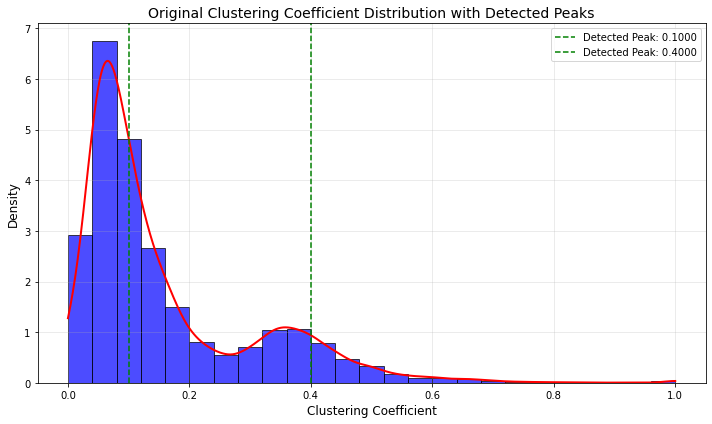

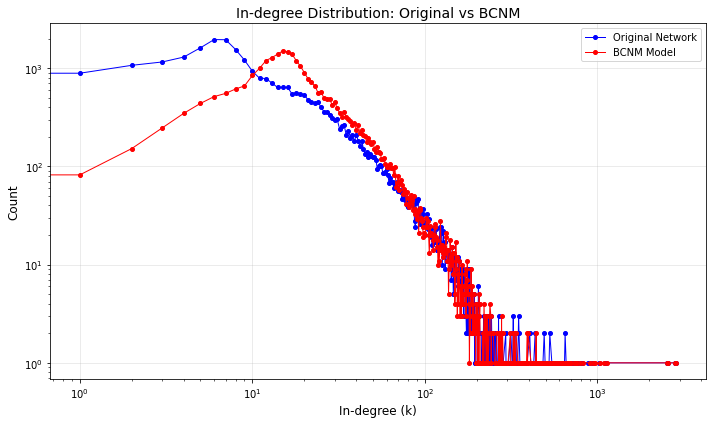

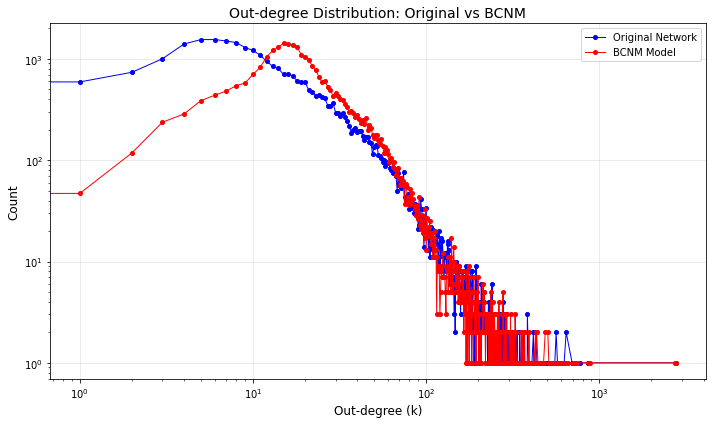

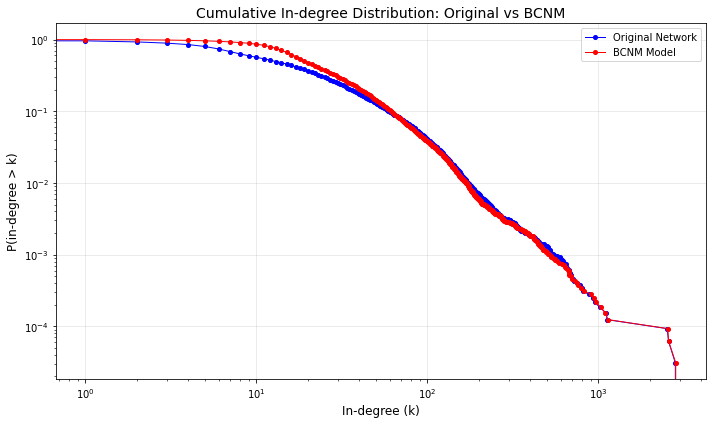

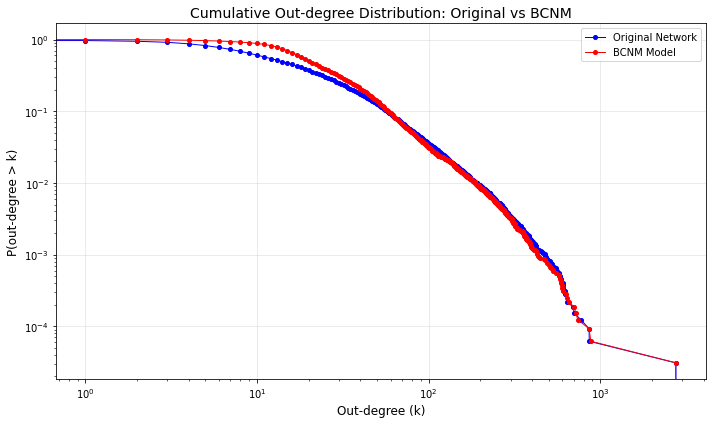

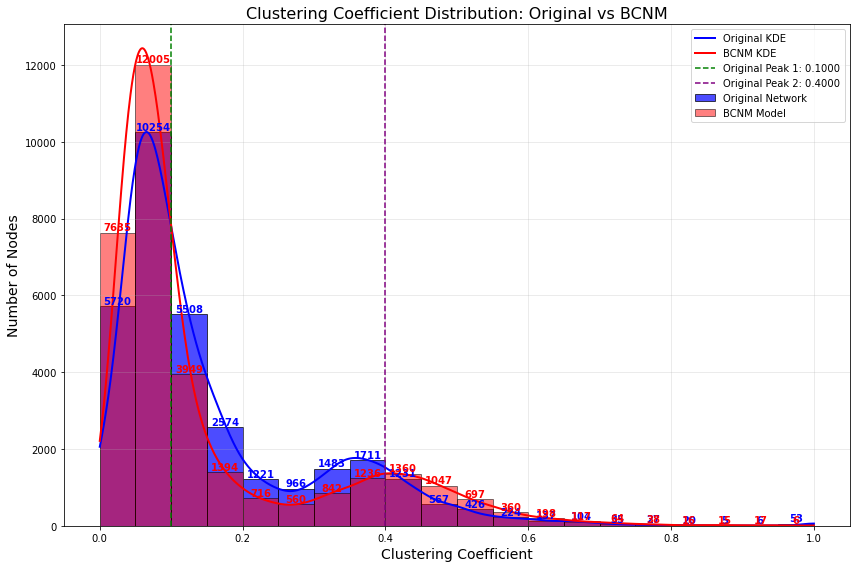

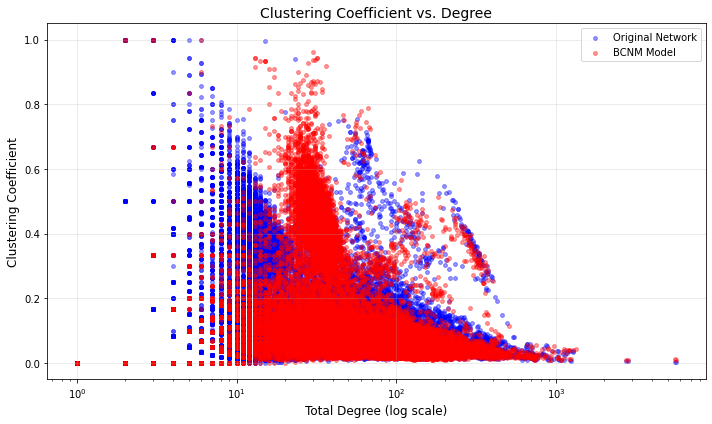

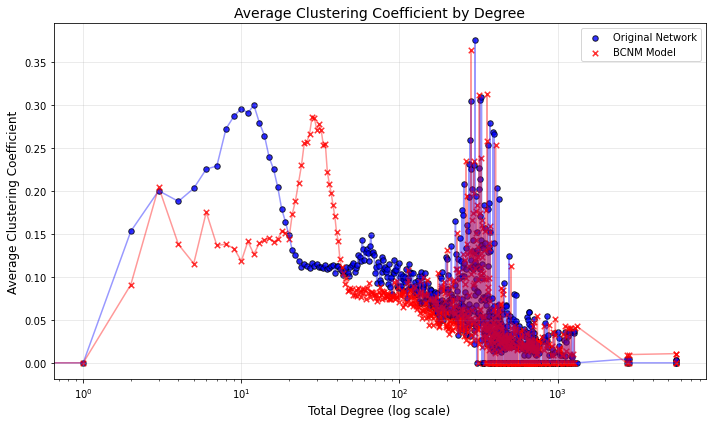

In [5]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import time
import random
from scipy.stats import gaussian_kde, ks_2samp
from scipy.signal import find_peaks

print("Starting Bimodal Clustering Network Model (BCNM) implementation...")
start_time = time.time()

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Calculate total degree
total_degree = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
clustering = nx.clustering(G)

# Analyze clustering coefficient distribution to find the bimodal peaks
cc_values = np.array(list(clustering.values()))
cc_kde = gaussian_kde(cc_values)
x_vals = np.linspace(0, 1, 1000)
y_vals = cc_kde(x_vals)

# Find peaks in the distribution
peaks, _ = find_peaks(y_vals, height=max(y_vals)*0.2, distance=50)
peak_x = x_vals[peaks]
peak_y = y_vals[peaks]

# Sort peaks by height
if len(peak_y) >= 2:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]
    peak_cc_values = sorted([peak_x[idx] for idx in top_peaks])
    
    peak1 = peak_cc_values[0]
    peak2 = peak_cc_values[1] if len(peak_cc_values) > 1 else peak_cc_values[0]
    
    print(f"Identified clustering coefficient peaks at: {peak1:.4f} and {peak2:.4f}")
else:
    # Fallback if peaks aren't found
    print("Failed to find bimodal peaks automatically, using default values")
    peak1 = 0.1
    peak2 = 0.4
    
# Plot the original clustering coefficient distribution with detected peaks
plt.figure(figsize=(10, 6))
plt.hist(cc_values, bins=25, alpha=0.7, density=True, color='blue', edgecolor='black')
plt.plot(x_vals, y_vals, 'r-', linewidth=2)
for peak in [peak1, peak2]:
    plt.axvline(x=peak, color='green', linestyle='--', 
                label=f'Detected Peak: {peak:.4f}')
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Original Clustering Coefficient Distribution with Detected Peaks', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/original_cc_peaks.png', dpi=600)
print("Saved original clustering coefficient distribution with peaks plot at 600dpi")

# Classify nodes into two groups based on clustering coefficient
print("Classifying nodes based on clustering coefficient...")
midpoint = (peak1 + peak2) / 2
nodes_low_cc = [node for node, cc in clustering.items() if cc <= midpoint]
nodes_high_cc = [node for node, cc in clustering.items() if cc > midpoint]

print(f"Low clustering coefficient group (≤{midpoint:.4f}): {len(nodes_low_cc)} nodes")
print(f"High clustering coefficient group (>{midpoint:.4f}): {len(nodes_high_cc)} nodes")

# Create the Bimodal Clustering Network Model
print("Creating Bimodal Clustering Network Model...")
bcnm_graph = nx.DiGraph()

# Add the same nodes as the original graph with their attributes
for node in G.nodes():
    bcnm_graph.add_node(node, **G.nodes[node])

print(f"Added {bcnm_graph.number_of_nodes()} nodes to BCNM graph")

# Step 1: Create communities based on the bimodal clustering and module information
print("Step 1: Creating communities based on bimodal clustering and modules...")

# Group nodes by module and clustering group
module_cc_groups = defaultdict(lambda: defaultdict(list))
for node in G.nodes():
    module = modules[node]
    cc_group = "high" if node in nodes_high_cc else "low"
    module_cc_groups[module][cc_group].append(node)

# Create communities from these groups
communities = []
community_id = 0
node_to_community = {}

# Process high CC nodes first (they form tightly connected communities)
for module, cc_groups in module_cc_groups.items():
    high_cc_nodes = cc_groups["high"]
    
    if high_cc_nodes:
        # Further divide high CC nodes by degree for better structure preservation
        degree_groups = defaultdict(list)
        for node in high_cc_nodes:
            degree_bin = total_degree[node] // 5  # Group by degree in bins of 5
            degree_groups[degree_bin].append(node)
        
        # Create communities from degree groups
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:  # Minimum community size
                community_size = min(20, len(nodes))  # Limit maximum community size
                
                # Split into communities of appropriate size
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                # Handle singleton nodes
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1
    
    # Process low CC nodes with different strategy
    low_cc_nodes = cc_groups["low"]
    
    if low_cc_nodes:
        # Low CC nodes form more loosely connected communities
        # Group by degree for better degree distribution preservation
        degree_groups = defaultdict(list)
        for node in low_cc_nodes:
            degree_bin = total_degree[node] // 10  # Wider bins for low CC
            degree_groups[degree_bin].append(node)
        
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:
                community_size = min(30, len(nodes))  # Larger communities
                
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1

print(f"Created {community_id} communities")

# Step 2: Add edges within communities with appropriate densities
print("Step 2: Adding edges within communities...")

edges_added = 0
for community_idx, community in enumerate(communities):
    if len(community) <= 1:
        continue
    
    # Calculate target average clustering for this community
    community_nodes_cc = [clustering[node] for node in community]
    target_cc = np.mean(community_nodes_cc)
    
    # Calculate density based on target clustering
    if target_cc > midpoint:
        # High clustering communities - higher density
        # For a complete graph, density = 1, cc = 1
        # Scale density based on target_cc
        density = min(0.95, max(0.5, target_cc))
    else:
        # Low clustering communities - lower density
        density = min(0.5, max(0.05, target_cc * 2))
    
    # Add edges with calculated density
    for i, u in enumerate(community):
        for j, v in enumerate(community):
            if i != j and random.random() < density:
                bcnm_graph.add_edge(u, v)
                edges_added += 1

print(f"Added {edges_added} edges within communities")
print(f"After Step 2: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 3: Connect communities to match the inter-community structure of the original graph
print("Step 3: Connecting communities...")

# Analyze inter-community connections in the original graph
inter_community_edges = defaultdict(int)
inter_community_pairs = defaultdict(int)

for u, v in G.edges():
    if u in node_to_community and v in node_to_community:
        comm_u = node_to_community[u]
        comm_v = node_to_community[v]
        
        if comm_u != comm_v:
            inter_community_edges[(comm_u, comm_v)] += 1
            inter_community_pairs[(comm_u, comm_v)] += 1

# Calculate probability of edges between communities
inter_community_probs = {}
for (comm_u, comm_v), count in inter_community_edges.items():
    # Get sizes of communities
    size_u = len(communities[comm_u]) if comm_u < len(communities) else 0
    size_v = len(communities[comm_v]) if comm_v < len(communities) else 0
    
    if size_u > 0 and size_v > 0:
        # Maximum possible edges between communities
        max_edges = size_u * size_v
        # Probability of edge
        prob = count / max_edges
        inter_community_probs[(comm_u, comm_v)] = min(1.0, max(0.001, prob))

print(f"Calculated probabilities for {len(inter_community_probs)} community pairs")

# Add edges between communities
inter_edges_added = 0
for (comm_u, comm_v), prob in inter_community_probs.items():
    # Get nodes from communities
    nodes_u = communities[comm_u] if comm_u < len(communities) else []
    nodes_v = communities[comm_v] if comm_v < len(communities) else []
    
    for u in nodes_u:
        for v in nodes_v:
            if random.random() < prob:
                bcnm_graph.add_edge(u, v)
                inter_edges_added += 1

print(f"Added {inter_edges_added} edges between communities")
print(f"After Step 3: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 4: Degree correction to match target degree distribution
print("Step 4: Performing degree correction...")

# Get current degrees
current_in_degrees = dict(bcnm_graph.in_degree())
current_out_degrees = dict(bcnm_graph.out_degree())

# Calculate how many edges need to be added for each node
in_degree_deficit = {node: max(0, in_degrees[node] - current_in_degrees[node]) for node in G.nodes()}
out_degree_deficit = {node: max(0, out_degrees[node] - current_out_degrees[node]) for node in G.nodes()}

total_in_deficit = sum(in_degree_deficit.values())
total_out_deficit = sum(out_degree_deficit.values())
print(f"Total in-degree deficit: {total_in_deficit}")
print(f"Total out-degree deficit: {total_out_deficit}")

# Create stubs for the Configuration Model part
in_stubs = []
for node, deficit in in_degree_deficit.items():
    in_stubs.extend([node] * deficit)

out_stubs = []
for node, deficit in out_degree_deficit.items():
    out_stubs.extend([node] * deficit)

# Shuffle stubs
random.shuffle(in_stubs)
random.shuffle(out_stubs)

# Match stubs to create edges, avoiding self-loops and multi-edges
added_edges = 0
max_attempts = min(len(in_stubs), len(out_stubs)) * 10  # Allow for multiple attempts
attempts = 0

while in_stubs and out_stubs and attempts < max_attempts:
    out_node = out_stubs.pop()
    in_node = in_stubs.pop()
    
    # Check if it's a self-loop or already existing edge
    if out_node != in_node and not bcnm_graph.has_edge(out_node, in_node):
        bcnm_graph.add_edge(out_node, in_node)
        added_edges += 1
    else:
        # Put the stubs back and try again
        out_stubs.append(out_node)
        in_stubs.append(in_node)
    
    attempts += 1

print(f"Step 4: Added {added_edges} edges to match degree distribution")
print(f"Final BCNM graph has {bcnm_graph.number_of_nodes()} nodes and {bcnm_graph.number_of_edges()} edges")

# Calculate final degrees and metrics
final_in_degrees = dict(bcnm_graph.in_degree())
final_out_degrees = dict(bcnm_graph.out_degree())

# Calculate average absolute error in degree matching
in_degree_error = sum(abs(in_degrees[n] - final_in_degrees[n]) for n in G.nodes()) / G.number_of_nodes()
out_degree_error = sum(abs(out_degrees[n] - final_out_degrees[n]) for n in G.nodes()) / G.number_of_nodes()

print(f"Average absolute error in in-degree matching: {in_degree_error:.4f}")
print(f"Average absolute error in out-degree matching: {out_degree_error:.4f}")

# Calculate clustering coefficients for the model
print("Calculating clustering coefficients for BCNM model...")
bcnm_clustering = nx.clustering(bcnm_graph.to_undirected())
print(f"Original network average clustering: {np.mean(list(clustering.values())):.4f}")
print(f"BCNM network average clustering: {np.mean(list(bcnm_clustering.values())):.4f}")

# Perform KS test for degree and clustering coefficient distributions
original_in_degrees_list = list(in_degrees.values())
original_out_degrees_list = list(out_degrees.values())
bcnm_in_degrees_list = list(final_in_degrees.values())
bcnm_out_degrees_list = list(final_out_degrees.values())

original_cc_list = list(clustering.values())
bcnm_cc_list = list(bcnm_clustering.values())

ks_in_degree = ks_2samp(original_in_degrees_list, bcnm_in_degrees_list)
ks_out_degree = ks_2samp(original_out_degrees_list, bcnm_out_degrees_list)
ks_clustering = ks_2samp(original_cc_list, bcnm_cc_list)

print(f"KS test for in-degree distribution: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.4f}")
print(f"KS test for out-degree distribution: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.4f}")
print(f"KS test for clustering coefficient distribution: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.4f}")

# Plot comparison of degree distributions
print("Plotting degree distributions...")

# Calculate degree distributions
original_in_degree_counts = Counter(original_in_degrees_list)
original_out_degree_counts = Counter(original_out_degrees_list)
bcnm_in_degree_counts = Counter(bcnm_in_degrees_list)
bcnm_out_degree_counts = Counter(bcnm_out_degrees_list)

# In-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_in_degree_counts.keys()), 
           [original_in_degree_counts[k] for k in sorted(original_in_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_in_degree_counts.keys()), 
           [bcnm_in_degree_counts[k] for k in sorted(bcnm_in_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_out_degree_counts.keys()), 
           [original_out_degree_counts[k] for k in sorted(original_out_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_out_degree_counts.keys()), 
           [bcnm_out_degree_counts[k] for k in sorted(bcnm_out_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_in, y_bcnm_in, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_out, y_bcnm_out, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(12, 8))

# Create histogram bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_cc_list, bins=bins, alpha=0.7, 
                                     color='blue', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# Add count numbers above bars
bin_centers = 0.5 * (bins[:-1] + bins[1:])
for i, (count_orig, count_bcnm) in enumerate(zip(counts_orig, counts_bcnm)):
    if count_orig > 0:
        plt.text(bin_centers[i], count_orig + 5, str(int(count_orig)), 
                 ha='center', va='bottom', color='blue', fontweight='bold')
    if count_bcnm > 0:
        plt.text(bin_centers[i], count_bcnm + 5, str(int(count_bcnm)), 
                 ha='center', va='bottom', color='red', fontweight='bold')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE')

# Add vertical lines for the original peaks
plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

# Create a scatter plot of clustering coefficient by degree
print("Creating scatter plot of clustering coefficient by degree...")

plt.figure(figsize=(10, 6))

# Original network
plt.scatter([total_degree[n] for n in G.nodes()], 
            [clustering[n] for n in G.nodes()],
            alpha=0.4, s=15, c='blue', label='Original Network')

# BCNM model
bcnm_total_degree = {n: final_in_degrees[n] + final_out_degrees[n] for n in bcnm_graph.nodes()}
plt.scatter([bcnm_total_degree[n] for n in bcnm_graph.nodes()], 
            [bcnm_clustering[n] for n in bcnm_graph.nodes()],
            alpha=0.4, s=15, c='red', label='BCNM Model')

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Clustering Coefficient vs. Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cc_vs_degree.png', dpi=600)
print("Saved clustering coefficient vs. degree plot at 600dpi")

# Calculate average clustering by degree for both networks
print("Calculating average clustering by degree...")

# Original network
original_cc_by_degree = defaultdict(list)
for node in G.nodes():
    deg = total_degree[node]
    original_cc_by_degree[deg].append(clustering[node])

# BCNM model
bcnm_cc_by_degree = defaultdict(list)
for node in bcnm_graph.nodes():
    deg = bcnm_total_degree[node]
    bcnm_cc_by_degree[deg].append(bcnm_clustering[node])

# Calculate averages
original_avg_cc_by_degree = {d: np.mean(cc) for d, cc in original_cc_by_degree.items() if cc}
bcnm_avg_cc_by_degree = {d: np.mean(cc) for d, cc in bcnm_cc_by_degree.items() if cc}

# Plot average clustering coefficient by degree
plt.figure(figsize=(10, 6))

# Get sorted degrees
all_degrees = sorted(set(original_avg_cc_by_degree.keys()) | set(bcnm_avg_cc_by_degree.keys()))
original_cc_values = [original_avg_cc_by_degree.get(d, 0) for d in all_degrees]
bcnm_cc_values = [bcnm_avg_cc_by_degree.get(d, 0) for d in all_degrees]

plt.scatter(all_degrees, original_cc_values, alpha=0.8, s=30, c='blue', 
            edgecolors='black', label='Original Network')
plt.scatter(all_degrees, bcnm_cc_values, alpha=0.8, s=30, c='red', 
            edgecolors='black', label='BCNM Model', marker='x')

# Add trend lines
plt.plot(all_degrees, original_cc_values, 'b-', alpha=0.4)
plt.plot(all_degrees, bcnm_cc_values, 'r-', alpha=0.4)

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Average Clustering Coefficient by Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the BCNM graph to files for future use
print("Saving single-size BCNM data...")
single_edges = list(bcnm_graph.edges())
single_edges_df = pd.DataFrame(single_edges, columns=['from', 'to'])
single_edges_df.to_csv('single_size_BCNM_edges.csv', index=False)

# Save node metadata
single_nodes = list(bcnm_graph.nodes(data=True))
single_metadata = []
for node, data in single_nodes:
    single_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
single_metadata_df = pd.DataFrame(single_metadata)
single_metadata_df.to_csv('single_size_bcnm_metadata.csv', index=False)

print("Single-size BCNM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting Bimodal Clustering Network Model (BCNM) implementation...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Calculating clustering coefficients...
Identified clustering coefficient peaks at: 0.0651 and 0.3584
Saved original clustering coefficient distribution with peaks plot at 600dpi
Classifying nodes based on clustering coefficient...
Low clustering coefficient group (≤0.2117): 24464 nodes
High clustering coefficient group (>0.2117): 7808 nodes
Creating Bimodal Clustering Network Model...
Added 32272 nodes to BCNM graph
Step 1: Creating communities based on bimodal clustering and modules...
Created 2475 communities
Step 2: Adding edges within communities

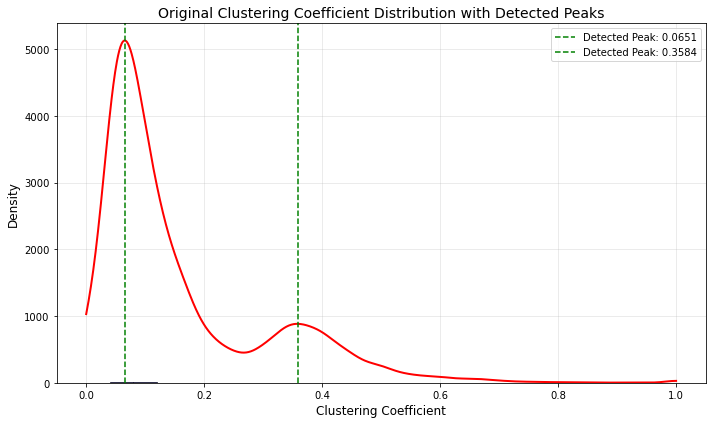

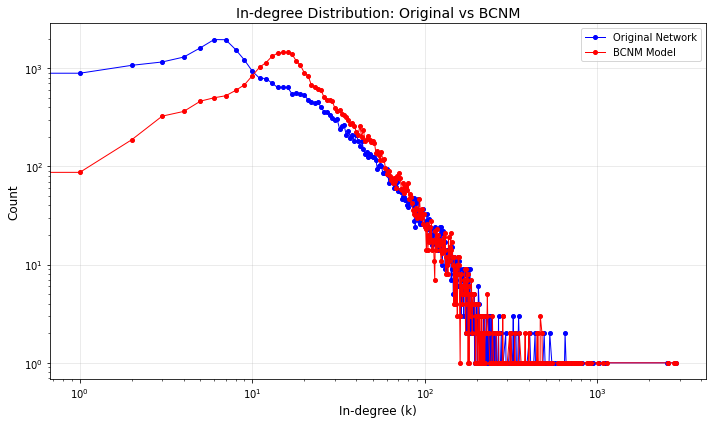

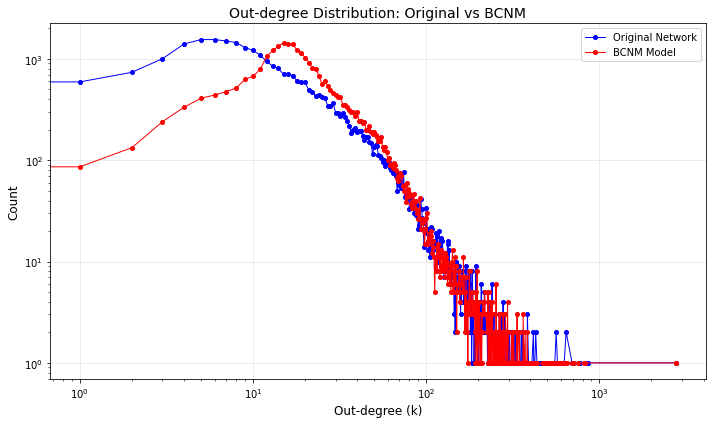

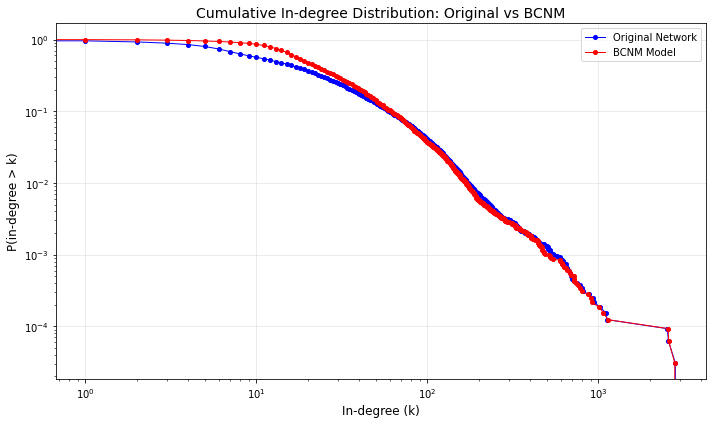

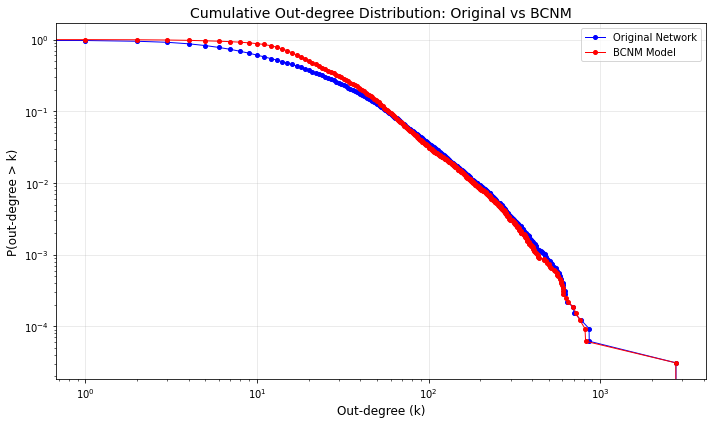

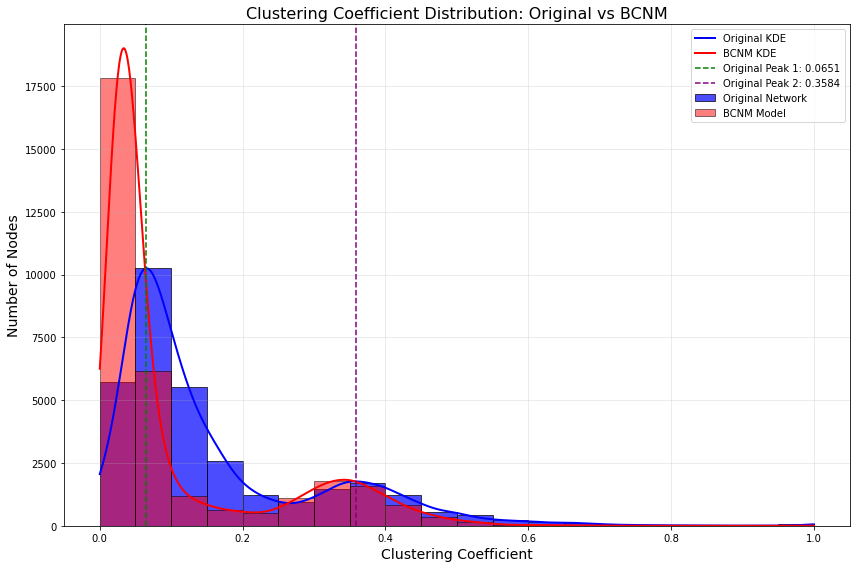

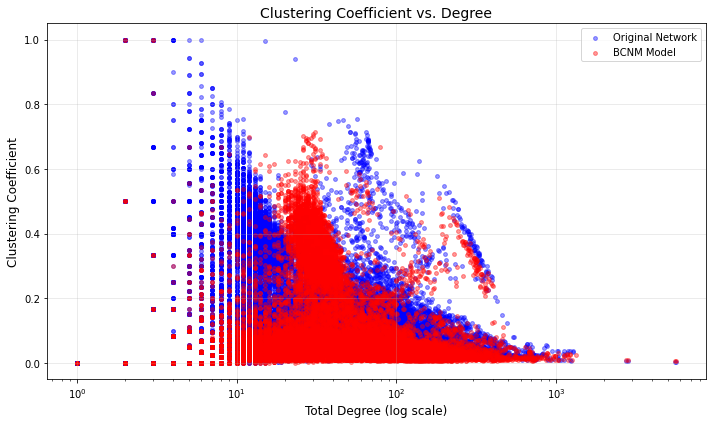

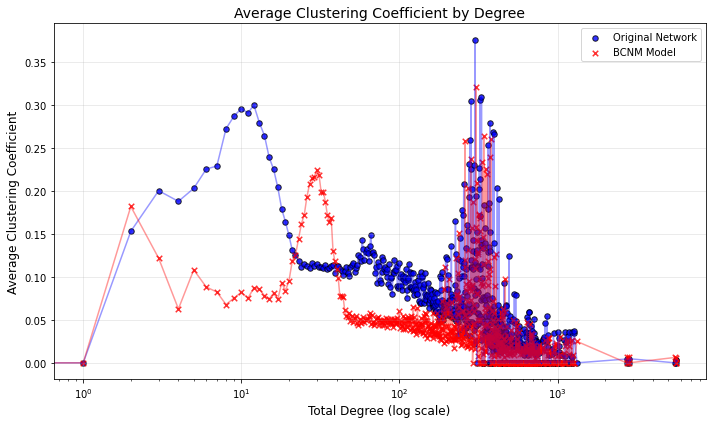

In [14]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import time
import random
from scipy.stats import gaussian_kde, ks_2samp
from scipy.signal import find_peaks

print("Starting Bimodal Clustering Network Model (BCNM) implementation...")
start_time = time.time()

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Calculate total degree
total_degree = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
clustering = nx.clustering(G)

original_clustering = nx.clustering(G)  # Uses undirected version by default
original_clustering_values = list(original_clustering.values())

bins = np.linspace(0, 1, 41)  # 20 bins from 0 to 1

kde = gaussian_kde(original_clustering_values)
x_vals = np.linspace(0, 1, 1000)
y_vals = kde(x_vals) * len(original_clustering_values) * (bins[1] - bins[0])  # Scale to match histogram height
# plt.plot(x_vals, y_vals, '-', linewidth=2, label='Original KDE',color='black')

# Find peaks in the original KDE
peaks, _ = find_peaks(y_vals, height=max(y_vals)*0.1, distance=50)
peak_x = x_vals[peaks]
peak_y = y_vals[peaks]

# Sort peaks by height
if len(peak_y) >= 2:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]
    peak_cc_values = sorted([peak_x[idx] for idx in top_peaks])
    
    peak1 = peak_cc_values[0]
    peak2 = peak_cc_values[1] if len(peak_cc_values) > 1 else peak_cc_values[0]
    
    print(f"Identified clustering coefficient peaks at: {peak1:.4f} and {peak2:.4f}")
else:
    # Fallback if peaks aren't found
    print("Failed to find bimodal peaks automatically, using default values")
    peak1 = 0.1
    peak2 = 0.4


# Plot the original clustering coefficient distribution with detected peaks
plt.figure(figsize=(10, 6))
plt.hist(original_clustering_values, bins=25, alpha=0.7, density=True, color='blue', edgecolor='black')
plt.plot(x_vals, y_vals, 'r-', linewidth=2)
for peak in [peak1, peak2]:
    plt.axvline(x=peak, color='green', linestyle='--', 
                label=f'Detected Peak: {peak:.4f}')
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Original Clustering Coefficient Distribution with Detected Peaks', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/original_cc_peaks.png', dpi=600)
print("Saved original clustering coefficient distribution with peaks plot at 600dpi")

# Classify nodes into two groups based on clustering coefficient
print("Classifying nodes based on clustering coefficient...")
midpoint = (peak1 + peak2) / 2
nodes_low_cc = [node for node, cc in clustering.items() if cc <= midpoint]
nodes_high_cc = [node for node, cc in clustering.items() if cc > midpoint]

print(f"Low clustering coefficient group (≤{midpoint:.4f}): {len(nodes_low_cc)} nodes")
print(f"High clustering coefficient group (>{midpoint:.4f}): {len(nodes_high_cc)} nodes")

# Create the Bimodal Clustering Network Model
print("Creating Bimodal Clustering Network Model...")
bcnm_graph = nx.DiGraph()

# Add the same nodes as the original graph with their attributes
for node in G.nodes():
    bcnm_graph.add_node(node, **G.nodes[node])

print(f"Added {bcnm_graph.number_of_nodes()} nodes to BCNM graph")

# Step 1: Create communities based on the bimodal clustering and module information
print("Step 1: Creating communities based on bimodal clustering and modules...")

# Group nodes by module and clustering group
module_cc_groups = defaultdict(lambda: defaultdict(list))
for node in G.nodes():
    module = modules[node]
    cc_group = "high" if node in nodes_high_cc else "low"
    module_cc_groups[module][cc_group].append(node)

# Create communities from these groups
communities = []
community_id = 0
node_to_community = {}

# Process high CC nodes first (they form tightly connected communities)
for module, cc_groups in module_cc_groups.items():
    high_cc_nodes = cc_groups["high"]
    
    if high_cc_nodes:
        # Further divide high CC nodes by degree for better structure preservation
        degree_groups = defaultdict(list)
        for node in high_cc_nodes:
            degree_bin = total_degree[node] // 5  # Group by degree in bins of 5
            degree_groups[degree_bin].append(node)
        
        # Create communities from degree groups
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:  # Minimum community size
                community_size = min(20, len(nodes))  # Limit maximum community size
                
                # Split into communities of appropriate size
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                # Handle singleton nodes
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1
    
    # Process low CC nodes with different strategy
    low_cc_nodes = cc_groups["low"]
    
    if low_cc_nodes:
        # Low CC nodes form more loosely connected communities
        # Group by degree for better degree distribution preservation
        degree_groups = defaultdict(list)
        for node in low_cc_nodes:
            degree_bin = total_degree[node] // 10  # Wider bins for low CC
            degree_groups[degree_bin].append(node)
        
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:
                community_size = min(30, len(nodes))  # Larger communities
                
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1

print(f"Created {community_id} communities")

# Step 2: Add edges within communities with appropriate densities
print("Step 2: Adding edges within communities...")

edges_added = 0
for community_idx, community in enumerate(communities):
    if len(community) <= 1:
        continue
    
    # Calculate target average clustering for this community
    community_nodes_cc = [clustering[node] for node in community]
    target_cc = np.mean(community_nodes_cc)
    
    # Calculate density based on target clustering
    if target_cc > midpoint:
        # High clustering communities - higher density
        # For a complete graph, density = 1, cc = 1
        # Scale density based on target_cc
        density = min(0.95, max(0.5, target_cc))
    else:
        # Low clustering communities - lower density
        density = min(0.5, max(0.05, target_cc * 2))
    
    # Add edges with calculated density
    for i, u in enumerate(community):
        for j, v in enumerate(community):
            if i != j and random.random() < density:
                bcnm_graph.add_edge(u, v)
                edges_added += 1

print(f"Added {edges_added} edges within communities")
print(f"After Step 2: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 3: Connect communities to match the inter-community structure of the original graph
print("Step 3: Connecting communities...")

# Analyze inter-community connections in the original graph
inter_community_edges = defaultdict(int)
inter_community_pairs = defaultdict(int)

for u, v in G.edges():
    if u in node_to_community and v in node_to_community:
        comm_u = node_to_community[u]
        comm_v = node_to_community[v]
        
        if comm_u != comm_v:
            inter_community_edges[(comm_u, comm_v)] += 1
            inter_community_pairs[(comm_u, comm_v)] += 1

# Calculate probability of edges between communities
inter_community_probs = {}
for (comm_u, comm_v), count in inter_community_edges.items():
    # Get sizes of communities
    size_u = len(communities[comm_u]) if comm_u < len(communities) else 0
    size_v = len(communities[comm_v]) if comm_v < len(communities) else 0
    
    if size_u > 0 and size_v > 0:
        # Maximum possible edges between communities
        max_edges = size_u * size_v
        # Probability of edge
        prob = count / max_edges
        inter_community_probs[(comm_u, comm_v)] = min(1.0, max(0.001, prob))

print(f"Calculated probabilities for {len(inter_community_probs)} community pairs")

# Add edges between communities
inter_edges_added = 0
for (comm_u, comm_v), prob in inter_community_probs.items():
    # Get nodes from communities
    nodes_u = communities[comm_u] if comm_u < len(communities) else []
    nodes_v = communities[comm_v] if comm_v < len(communities) else []
    
    for u in nodes_u:
        for v in nodes_v:
            if random.random() < prob:
                bcnm_graph.add_edge(u, v)
                inter_edges_added += 1

print(f"Added {inter_edges_added} edges between communities")
print(f"After Step 3: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 4: Degree correction to match target degree distribution
print("Step 4: Performing degree correction...")

# Get current degrees
current_in_degrees = dict(bcnm_graph.in_degree())
current_out_degrees = dict(bcnm_graph.out_degree())

# Calculate how many edges need to be added for each node
in_degree_deficit = {node: max(0, in_degrees[node] - current_in_degrees[node]) for node in G.nodes()}
out_degree_deficit = {node: max(0, out_degrees[node] - current_out_degrees[node]) for node in G.nodes()}

total_in_deficit = sum(in_degree_deficit.values())
total_out_deficit = sum(out_degree_deficit.values())
print(f"Total in-degree deficit: {total_in_deficit}")
print(f"Total out-degree deficit: {total_out_deficit}")

# Create stubs for the Configuration Model part
in_stubs = []
for node, deficit in in_degree_deficit.items():
    in_stubs.extend([node] * deficit)

out_stubs = []
for node, deficit in out_degree_deficit.items():
    out_stubs.extend([node] * deficit)

# Shuffle stubs
random.shuffle(in_stubs)
random.shuffle(out_stubs)

# Match stubs to create edges, avoiding self-loops and multi-edges
added_edges = 0
max_attempts = min(len(in_stubs), len(out_stubs)) * 10  # Allow for multiple attempts
attempts = 0

while in_stubs and out_stubs and attempts < max_attempts:
    out_node = out_stubs.pop()
    in_node = in_stubs.pop()
    
    # Check if it's a self-loop or already existing edge
    if out_node != in_node and not bcnm_graph.has_edge(out_node, in_node):
        bcnm_graph.add_edge(out_node, in_node)
        added_edges += 1
    else:
        # Put the stubs back and try again
        out_stubs.append(out_node)
        in_stubs.append(in_node)
    
    attempts += 1

print(f"Step 4: Added {added_edges} edges to match degree distribution")
print(f"Final BCNM graph has {bcnm_graph.number_of_nodes()} nodes and {bcnm_graph.number_of_edges()} edges")

# Calculate final degrees and metrics
final_in_degrees = dict(bcnm_graph.in_degree())
final_out_degrees = dict(bcnm_graph.out_degree())

# Calculate average absolute error in degree matching
in_degree_error = sum(abs(in_degrees[n] - final_in_degrees[n]) for n in G.nodes()) / G.number_of_nodes()
out_degree_error = sum(abs(out_degrees[n] - final_out_degrees[n]) for n in G.nodes()) / G.number_of_nodes()

print(f"Average absolute error in in-degree matching: {in_degree_error:.4f}")
print(f"Average absolute error in out-degree matching: {out_degree_error:.4f}")

# Calculate clustering coefficients for the model
print("Calculating clustering coefficients for BCNM model...")
bcnm_clustering = nx.clustering(bcnm_graph)
# bcnm_clustering = nx.clustering(bcnm_graph.to_undirected())

print(f"Original network average clustering: {np.mean(list(clustering.values())):.4f}")
print(f"BCNM network average clustering: {np.mean(list(bcnm_clustering.values())):.4f}")

# Perform KS test for degree and clustering coefficient distributions
original_in_degrees_list = list(in_degrees.values())
original_out_degrees_list = list(out_degrees.values())
bcnm_in_degrees_list = list(final_in_degrees.values())
bcnm_out_degrees_list = list(final_out_degrees.values())

original_cc_list = list(clustering.values())
bcnm_cc_list = list(bcnm_clustering.values())

ks_in_degree = ks_2samp(original_in_degrees_list, bcnm_in_degrees_list)
ks_out_degree = ks_2samp(original_out_degrees_list, bcnm_out_degrees_list)
ks_clustering = ks_2samp(original_cc_list, bcnm_cc_list)

print(f"KS test for in-degree distribution: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.4f}")
print(f"KS test for out-degree distribution: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.4f}")
print(f"KS test for clustering coefficient distribution: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.4f}")

# Plot comparison of degree distributions
print("Plotting degree distributions...")

# Calculate degree distributions
original_in_degree_counts = Counter(original_in_degrees_list)
original_out_degree_counts = Counter(original_out_degrees_list)
bcnm_in_degree_counts = Counter(bcnm_in_degrees_list)
bcnm_out_degree_counts = Counter(bcnm_out_degrees_list)

# In-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_in_degree_counts.keys()), 
           [original_in_degree_counts[k] for k in sorted(original_in_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_in_degree_counts.keys()), 
           [bcnm_in_degree_counts[k] for k in sorted(bcnm_in_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_out_degree_counts.keys()), 
           [original_out_degree_counts[k] for k in sorted(original_out_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_out_degree_counts.keys()), 
           [bcnm_out_degree_counts[k] for k in sorted(bcnm_out_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_in, y_bcnm_in, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_out, y_bcnm_out, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(12, 8))

# Create histogram bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_clustering_values, bins=bins, alpha=0.7, 
                                     color='blue', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# Add count numbers above bars
# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# for i, (count_orig, count_bcnm) in enumerate(zip(counts_orig, counts_bcnm)):
#     if count_orig > 0:
#         plt.text(bin_centers[i], count_orig + 5, str(int(count_orig)), 
#                  ha='center', va='bottom', color='blue', fontweight='bold')
#     if count_bcnm > 0:
#         plt.text(bin_centers[i], count_bcnm + 5, str(int(count_bcnm)), 
#                  ha='center', va='bottom', color='red', fontweight='bold')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE')

# Add vertical lines for the original peaks
plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

# Create a scatter plot of clustering coefficient by degree
print("Creating scatter plot of clustering coefficient by degree...")

plt.figure(figsize=(10, 6))

# Original network
plt.scatter([total_degree[n] for n in G.nodes()], 
            [clustering[n] for n in G.nodes()],
            alpha=0.4, s=15, c='blue', label='Original Network')

# BCNM model
bcnm_total_degree = {n: final_in_degrees[n] + final_out_degrees[n] for n in bcnm_graph.nodes()}
plt.scatter([bcnm_total_degree[n] for n in bcnm_graph.nodes()], 
            [bcnm_clustering[n] for n in bcnm_graph.nodes()],
            alpha=0.4, s=15, c='red', label='BCNM Model')

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Clustering Coefficient vs. Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cc_vs_degree.png', dpi=600)
print("Saved clustering coefficient vs. degree plot at 600dpi")

# Calculate average clustering by degree for both networks
print("Calculating average clustering by degree...")

# Original network
original_cc_by_degree = defaultdict(list)
for node in G.nodes():
    deg = total_degree[node]
    original_cc_by_degree[deg].append(clustering[node])

# BCNM model
bcnm_cc_by_degree = defaultdict(list)
for node in bcnm_graph.nodes():
    deg = bcnm_total_degree[node]
    bcnm_cc_by_degree[deg].append(bcnm_clustering[node])

# Calculate averages
original_avg_cc_by_degree = {d: np.mean(cc) for d, cc in original_cc_by_degree.items() if cc}
bcnm_avg_cc_by_degree = {d: np.mean(cc) for d, cc in bcnm_cc_by_degree.items() if cc}

# Plot average clustering coefficient by degree
plt.figure(figsize=(10, 6))

# Get sorted degrees
all_degrees = sorted(set(original_avg_cc_by_degree.keys()) | set(bcnm_avg_cc_by_degree.keys()))
original_cc_values = [original_avg_cc_by_degree.get(d, 0) for d in all_degrees]
bcnm_cc_values = [bcnm_avg_cc_by_degree.get(d, 0) for d in all_degrees]

plt.scatter(all_degrees, original_cc_values, alpha=0.8, s=30, c='blue', 
            edgecolors='black', label='Original Network')
plt.scatter(all_degrees, bcnm_cc_values, alpha=0.8, s=30, c='red', 
            edgecolors='black', label='BCNM Model', marker='x')

# Add trend lines
plt.plot(all_degrees, original_cc_values, 'b-', alpha=0.4)
plt.plot(all_degrees, bcnm_cc_values, 'r-', alpha=0.4)

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Average Clustering Coefficient by Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the BCNM graph to files for future use
print("Saving single-size BCNM data...")
single_edges = list(bcnm_graph.edges())
single_edges_df = pd.DataFrame(single_edges, columns=['from', 'to'])
single_edges_df.to_csv('single_size_BCNM_edges.csv', index=False)

# Save node metadata
single_nodes = list(bcnm_graph.nodes(data=True))
single_metadata = []
for node, data in single_nodes:
    single_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
single_metadata_df = pd.DataFrame(single_metadata)
single_metadata_df.to_csv('single_size_bcnm_metadata.csv', index=False)

print("Single-size BCNM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Plotting degree distributions...
Saved in-degree distribution comparison plot at 600dpi
Saved out-degree distribution comparison plot at 600dpi
Calculating cumulative degree distributions...
Saved cumulative in-degree distribution plot at 600dpi
Saved cumulative out-degree distribution plot at 600dpi
Plotting clustering coefficient distributions...
Saved clustering coefficient histogram plot at 600dpi
Creating scatter plot of clustering coefficient by degree...
Saved clustering coefficient vs. degree plot at 600dpi
Calculating average clustering by degree...
Saving single-size BCNM data...
Single-size BCNM data saved to files

Total execution time: 338.06 seconds


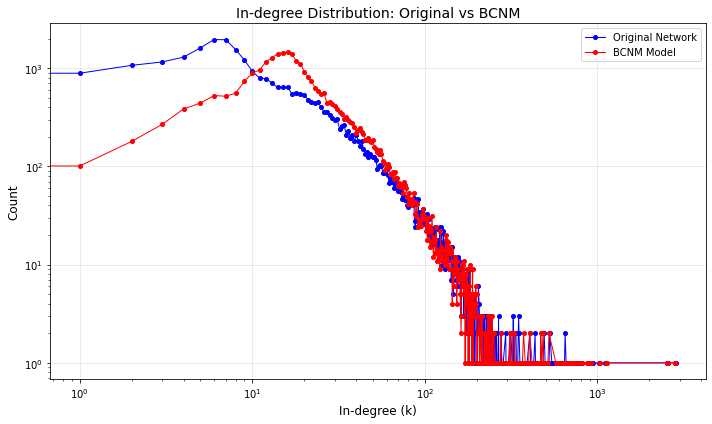

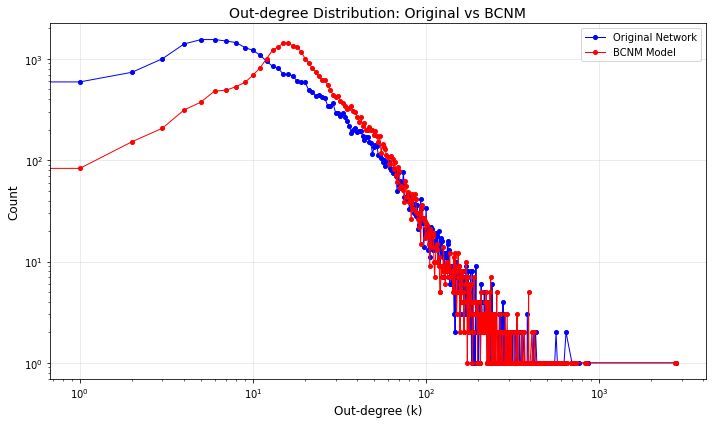

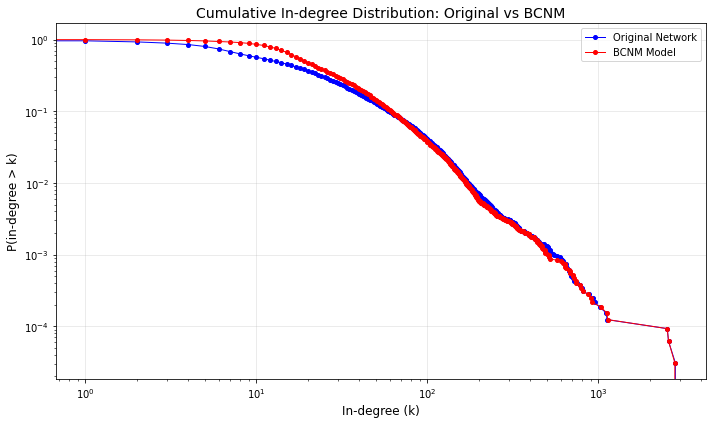

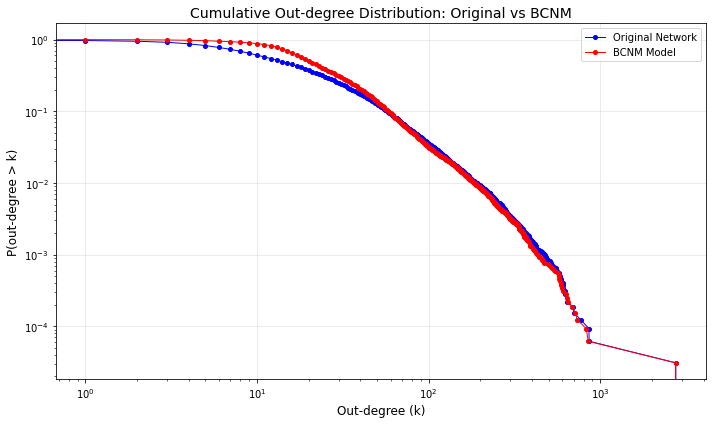

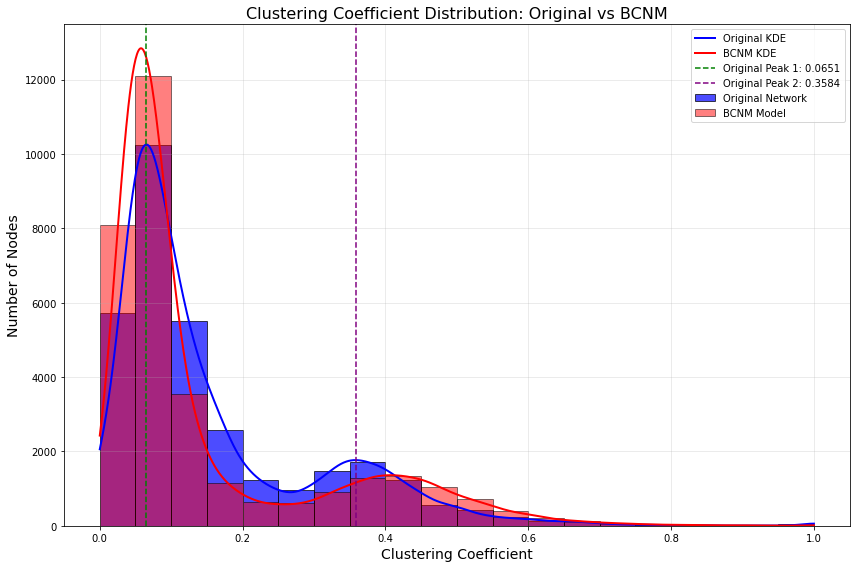

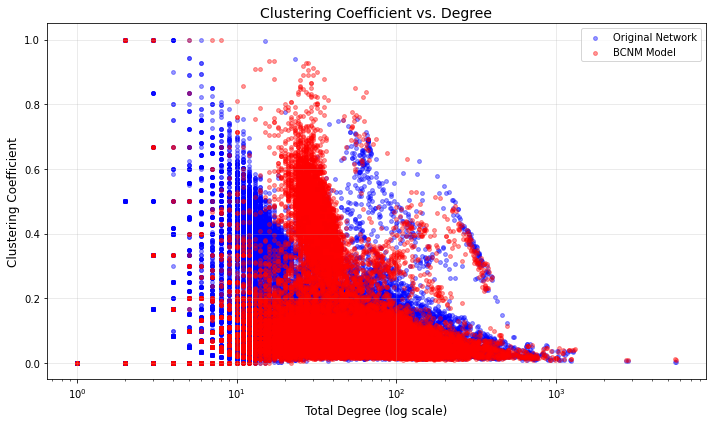

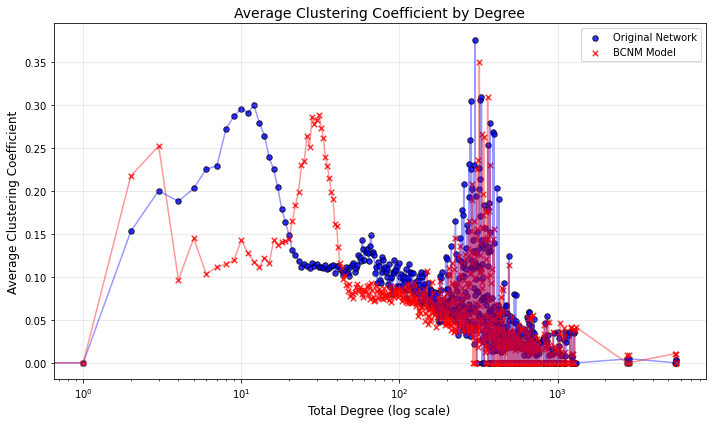

In [11]:
# Plot comparison of degree distributions
print("Plotting degree distributions...")

# Calculate degree distributions
original_in_degree_counts = Counter(original_in_degrees_list)
original_out_degree_counts = Counter(original_out_degrees_list)
bcnm_in_degree_counts = Counter(bcnm_in_degrees_list)
bcnm_out_degree_counts = Counter(bcnm_out_degrees_list)

# In-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_in_degree_counts.keys()), 
           [original_in_degree_counts[k] for k in sorted(original_in_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_in_degree_counts.keys()), 
           [bcnm_in_degree_counts[k] for k in sorted(bcnm_in_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_out_degree_counts.keys()), 
           [original_out_degree_counts[k] for k in sorted(original_out_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_out_degree_counts.keys()), 
           [bcnm_out_degree_counts[k] for k in sorted(bcnm_out_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_in, y_bcnm_in, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_out, y_bcnm_out, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(12, 8))

# Create histogram bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(cc_values, bins=bins, alpha=0.7, 
                                     color='blue', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# Add count numbers above bars
# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# for i, (count_orig, count_bcnm) in enumerate(zip(counts_orig, counts_bcnm)):
#     if count_orig > 0:
#         plt.text(bin_centers[i], count_orig + 5, str(int(count_orig)), 
#                  ha='center', va='bottom', color='blue', fontweight='bold')
#     if count_bcnm > 0:
#         plt.text(bin_centers[i], count_bcnm + 5, str(int(count_bcnm)), 
#                  ha='center', va='bottom', color='red', fontweight='bold')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE')

# Add vertical lines for the original peaks
plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

# Create a scatter plot of clustering coefficient by degree
print("Creating scatter plot of clustering coefficient by degree...")

plt.figure(figsize=(10, 6))

# Original network
plt.scatter([total_degree[n] for n in G.nodes()], 
            [clustering[n] for n in G.nodes()],
            alpha=0.4, s=15, c='blue', label='Original Network')

# BCNM model
bcnm_total_degree = {n: final_in_degrees[n] + final_out_degrees[n] for n in bcnm_graph.nodes()}
plt.scatter([bcnm_total_degree[n] for n in bcnm_graph.nodes()], 
            [bcnm_clustering[n] for n in bcnm_graph.nodes()],
            alpha=0.4, s=15, c='red', label='BCNM Model')

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Clustering Coefficient vs. Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cc_vs_degree.png', dpi=600)
print("Saved clustering coefficient vs. degree plot at 600dpi")

# Calculate average clustering by degree for both networks
print("Calculating average clustering by degree...")

# Original network
original_cc_by_degree = defaultdict(list)
for node in G.nodes():
    deg = total_degree[node]
    original_cc_by_degree[deg].append(clustering[node])

# BCNM model
bcnm_cc_by_degree = defaultdict(list)
for node in bcnm_graph.nodes():
    deg = bcnm_total_degree[node]
    bcnm_cc_by_degree[deg].append(bcnm_clustering[node])

# Calculate averages
original_avg_cc_by_degree = {d: np.mean(cc) for d, cc in original_cc_by_degree.items() if cc}
bcnm_avg_cc_by_degree = {d: np.mean(cc) for d, cc in bcnm_cc_by_degree.items() if cc}

# Plot average clustering coefficient by degree
plt.figure(figsize=(10, 6))

# Get sorted degrees
all_degrees = sorted(set(original_avg_cc_by_degree.keys()) | set(bcnm_avg_cc_by_degree.keys()))
original_cc_values = [original_avg_cc_by_degree.get(d, 0) for d in all_degrees]
bcnm_cc_values = [bcnm_avg_cc_by_degree.get(d, 0) for d in all_degrees]

plt.scatter(all_degrees, original_cc_values, alpha=0.8, s=30, c='blue', 
            edgecolors='black', label='Original Network')
plt.scatter(all_degrees, bcnm_cc_values, alpha=0.8, s=30, c='red', 
            edgecolors='black', label='BCNM Model', marker='x')

# Add trend lines
plt.plot(all_degrees, original_cc_values, 'b-', alpha=0.4)
plt.plot(all_degrees, bcnm_cc_values, 'r-', alpha=0.4)

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Average Clustering Coefficient by Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the BCNM graph to files for future use
print("Saving single-size BCNM data...")
single_edges = list(bcnm_graph.edges())
single_edges_df = pd.DataFrame(single_edges, columns=['from', 'to'])
single_edges_df.to_csv('single_size_BCNM_edges.csv', index=False)

# Save node metadata
single_nodes = list(bcnm_graph.nodes(data=True))
single_metadata = []
for node, data in single_nodes:
    single_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
single_metadata_df = pd.DataFrame(single_metadata)
single_metadata_df.to_csv('single_size_bcnm_metadata.csv', index=False)

print("Single-size BCNM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting Bimodal Clustering Network Model (BCNM) implementation...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Calculating directed clustering coefficients...
Original network average directed clustering coefficient: 0.1646
Finding peaks in clustering coefficient distribution...
Identified clustering coefficient peaks at: 0.0711 and 0.2402
Saved original clustering coefficient distribution with peaks plot at 600dpi
Classifying nodes based on clustering coefficient...
Low clustering coefficient group (≤0.1557): 18410 nodes
High clustering coefficient group (>0.1557): 13862 nodes
Creating Bimodal Clustering Network Model...
Added 32272 nodes to BCNM graph
Step 

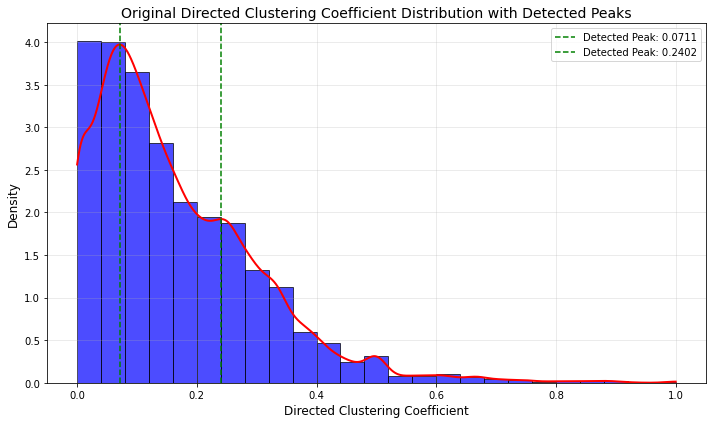

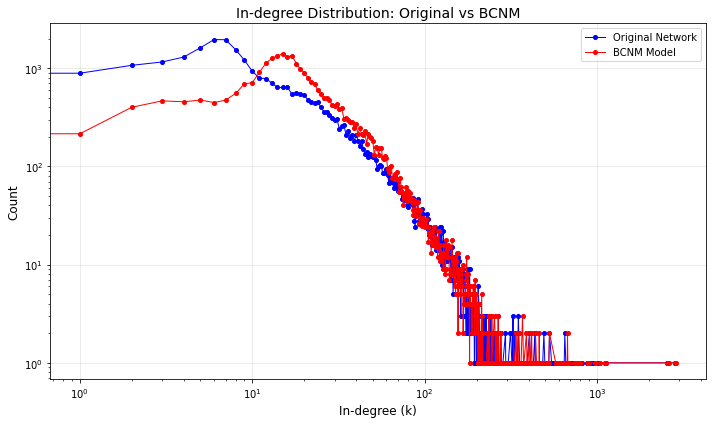

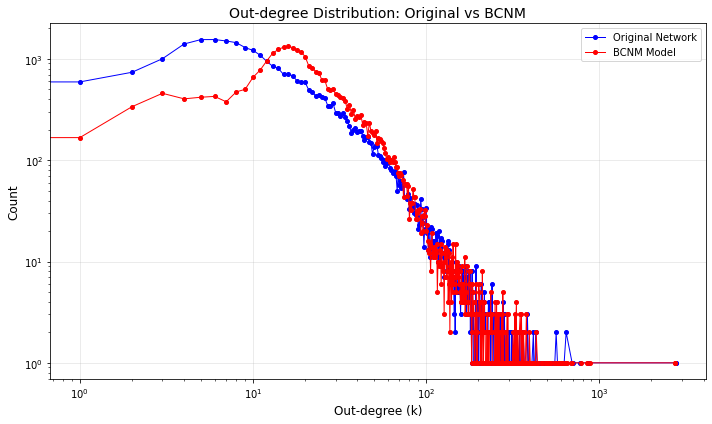

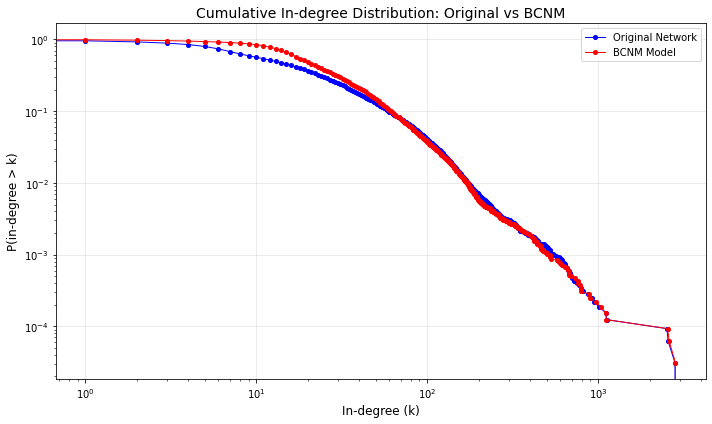

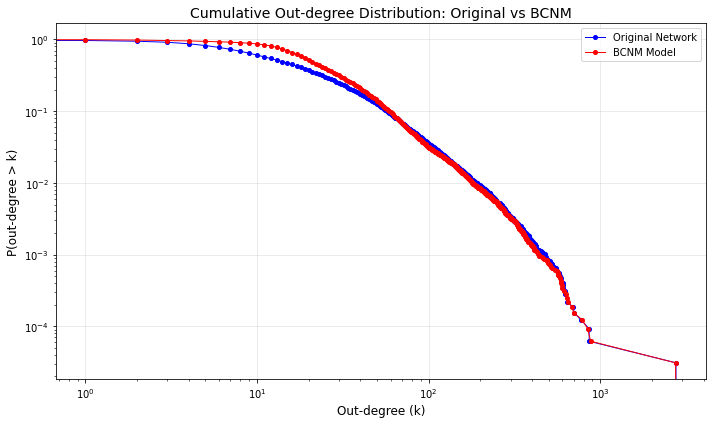

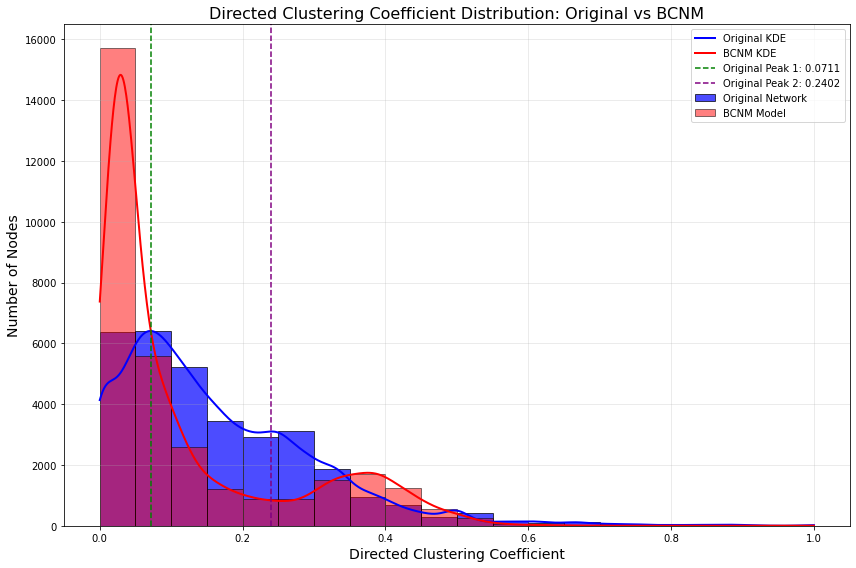

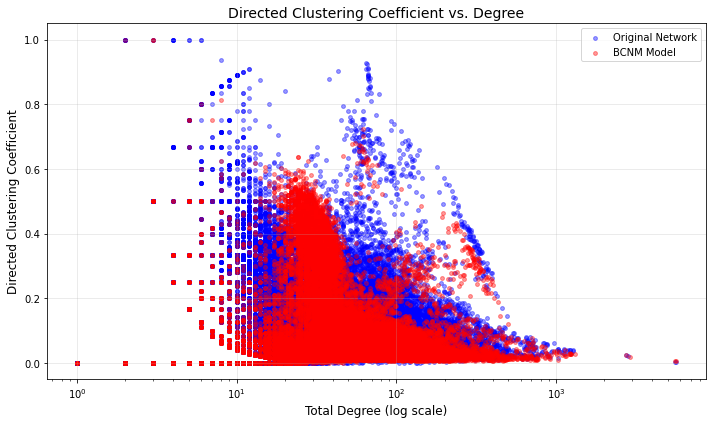

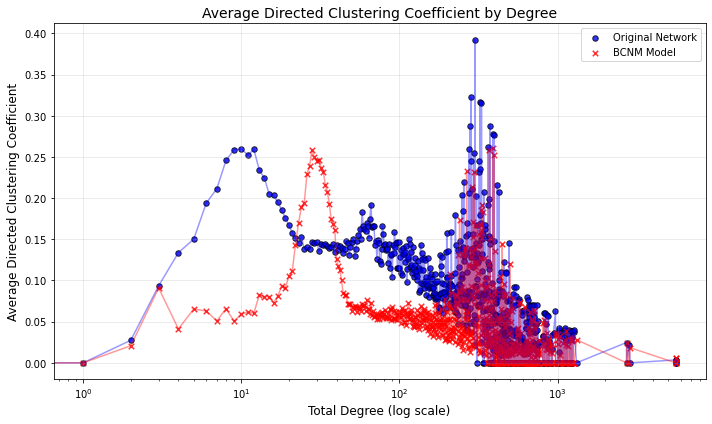

In [17]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import time
import random
from scipy.stats import gaussian_kde, ks_2samp
from scipy.signal import find_peaks

print("Starting Bimodal Clustering Network Model (BCNM) implementation...")
start_time = time.time()

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Calculate total degree
total_degree = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Calculate clustering coefficients on the directed graph
print("Calculating clustering coefficients...")
# Use directed graph for clustering coefficient consistently
clustering = nx.clustering(G)  # Calculate on directed graph directly
original_clustering_values = list(clustering.values())

# Create bins for histogram and KDE
bins = np.linspace(0, 1, 41)  # 40 bins from 0 to 1

# Compute KDE for the clustering coefficient distribution
kde = gaussian_kde(original_clustering_values)
x_vals = np.linspace(0, 1, 1000)
y_vals = kde(x_vals) * len(original_clustering_values) * (bins[1] - bins[0])  # Scale to match histogram height

# Find peaks in the KDE
print("Finding peaks in clustering coefficient distribution...")
peaks, _ = find_peaks(y_vals, height=max(y_vals)*0.1, distance=50)
peak_x = x_vals[peaks]
peak_y = y_vals[peaks]

# Sort peaks by height
if len(peak_y) >= 2:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]
    peak_cc_values = sorted([peak_x[idx] for idx in top_peaks])
    
    peak1 = peak_cc_values[0]
    peak2 = peak_cc_values[1] if len(peak_cc_values) > 1 else peak_cc_values[0]
    
    print(f"Identified clustering coefficient peaks at: {peak1:.4f} and {peak2:.4f}")
else:
    # Fallback if peaks aren't found
    print("Failed to find bimodal peaks automatically, using default values")
    peak1 = 0.1
    peak2 = 0.4

# Plot the original clustering coefficient distribution with detected peaks
plt.figure(figsize=(10, 6))
plt.hist(original_clustering_values, bins=25, alpha=0.7, density=True, color='blue', edgecolor='black')
plt.plot(x_vals, y_vals, 'r-', linewidth=2)
for peak in [peak1, peak2]:
    plt.axvline(x=peak, color='green', linestyle='--', 
                label=f'Detected Peak: {peak:.4f}')
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Original Clustering Coefficient Distribution with Detected Peaks', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/original_cc_peaks.png', dpi=600)
print("Saved original clustering coefficient distribution with peaks plot at 600dpi")

# Classify nodes into two groups based on clustering coefficient
print("Classifying nodes based on clustering coefficient...")
midpoint = (peak1 + peak2) / 2
nodes_low_cc = [node for node, cc in clustering.items() if cc <= midpoint]
nodes_high_cc = [node for node, cc in clustering.items() if cc > midpoint]

print(f"Low clustering coefficient group (≤{midpoint:.4f}): {len(nodes_low_cc)} nodes")
print(f"High clustering coefficient group (>{midpoint:.4f}): {len(nodes_high_cc)} nodes")

# Create the Bimodal Clustering Network Model
print("Creating Bimodal Clustering Network Model...")
bcnm_graph = nx.DiGraph()

# Add the same nodes as the original graph with their attributes
for node in G.nodes():
    bcnm_graph.add_node(node, **G.nodes[node])

print(f"Added {bcnm_graph.number_of_nodes()} nodes to BCNM graph")

# Step 1: Create communities based on the bimodal clustering and module information
print("Step 1: Creating communities based on bimodal clustering and modules...")

# Group nodes by module and clustering group
module_cc_groups = defaultdict(lambda: defaultdict(list))
for node in G.nodes():
    module = modules[node]
    cc_group = "high" if node in nodes_high_cc else "low"
    module_cc_groups[module][cc_group].append(node)

# Create communities from these groups
communities = []
community_id = 0
node_to_community = {}

# Process high CC nodes first (they form tightly connected communities)
for module, cc_groups in module_cc_groups.items():
    high_cc_nodes = cc_groups["high"]
    
    if high_cc_nodes:
        # Further divide high CC nodes by degree for better structure preservation
        degree_groups = defaultdict(list)
        for node in high_cc_nodes:
            degree_bin = total_degree[node] // 5  # Group by degree in bins of 5
            degree_groups[degree_bin].append(node)
        
        # Create communities from degree groups
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:  # Minimum community size
                community_size = min(20, len(nodes))  # Limit maximum community size
                
                # Split into communities of appropriate size
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                # Handle singleton nodes
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1
    
    # Process low CC nodes with different strategy
    low_cc_nodes = cc_groups["low"]
    
    if low_cc_nodes:
        # Low CC nodes form more loosely connected communities
        # Group by degree for better degree distribution preservation
        degree_groups = defaultdict(list)
        for node in low_cc_nodes:
            degree_bin = total_degree[node] // 10  # Wider bins for low CC
            degree_groups[degree_bin].append(node)
        
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:
                community_size = min(30, len(nodes))  # Larger communities
                
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1

print(f"Created {community_id} communities")

# Step 2: Add edges within communities with appropriate densities
print("Step 2: Adding edges within communities...")

edges_added = 0
for community_idx, community in enumerate(communities):
    if len(community) <= 1:
        continue
    
    # Calculate target average clustering for this community
    community_nodes_cc = [clustering[node] for node in community]
    target_cc = np.mean(community_nodes_cc)
    
    # Calculate density based on target clustering
    if target_cc > midpoint:
        # High clustering communities - higher density
        # For a complete graph, density = 1, cc = 1
        # Scale density based on target_cc
        density = min(0.95, max(0.5, target_cc))
    else:
        # Low clustering communities - lower density
        density = min(0.5, max(0.05, target_cc * 2))
    
    # Add edges with calculated density
    for i, u in enumerate(community):
        for j, v in enumerate(community):
            if i != j and random.random() < density:
                bcnm_graph.add_edge(u, v)
                edges_added += 1

print(f"Added {edges_added} edges within communities")
print(f"After Step 2: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 3: Connect communities to match the inter-community structure of the original graph
print("Step 3: Connecting communities...")

# Analyze inter-community connections in the original graph
inter_community_edges = defaultdict(int)
inter_community_pairs = defaultdict(int)

for u, v in G.edges():
    if u in node_to_community and v in node_to_community:
        comm_u = node_to_community[u]
        comm_v = node_to_community[v]
        
        if comm_u != comm_v:
            inter_community_edges[(comm_u, comm_v)] += 1
            inter_community_pairs[(comm_u, comm_v)] += 1

# Calculate probability of edges between communities
inter_community_probs = {}
for (comm_u, comm_v), count in inter_community_edges.items():
    # Get sizes of communities
    size_u = len(communities[comm_u]) if comm_u < len(communities) else 0
    size_v = len(communities[comm_v]) if comm_v < len(communities) else 0
    
    if size_u > 0 and size_v > 0:
        # Maximum possible edges between communities
        max_edges = size_u * size_v
        # Probability of edge
        prob = count / max_edges
        inter_community_probs[(comm_u, comm_v)] = min(1.0, max(0.001, prob))

print(f"Calculated probabilities for {len(inter_community_probs)} community pairs")

# Add edges between communities
inter_edges_added = 0
for (comm_u, comm_v), prob in inter_community_probs.items():
    # Get nodes from communities
    nodes_u = communities[comm_u] if comm_u < len(communities) else []
    nodes_v = communities[comm_v] if comm_v < len(communities) else []
    
    for u in nodes_u:
        for v in nodes_v:
            if random.random() < prob:
                bcnm_graph.add_edge(u, v)
                inter_edges_added += 1

print(f"Added {inter_edges_added} edges between communities")
print(f"After Step 3: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 4: Degree correction to match target degree distribution
print("Step 4: Performing degree correction...")

# Get current degrees
current_in_degrees = dict(bcnm_graph.in_degree())
current_out_degrees = dict(bcnm_graph.out_degree())

# Calculate how many edges need to be added for each node
in_degree_deficit = {node: max(0, in_degrees[node] - current_in_degrees[node]) for node in G.nodes()}
out_degree_deficit = {node: max(0, out_degrees[node] - current_out_degrees[node]) for node in G.nodes()}

total_in_deficit = sum(in_degree_deficit.values())
total_out_deficit = sum(out_degree_deficit.values())
print(f"Total in-degree deficit: {total_in_deficit}")
print(f"Total out-degree deficit: {total_out_deficit}")

# Create stubs for the Configuration Model part
in_stubs = []
for node, deficit in in_degree_deficit.items():
    in_stubs.extend([node] * deficit)

out_stubs = []
for node, deficit in out_degree_deficit.items():
    out_stubs.extend([node] * deficit)

# Shuffle stubs
random.shuffle(in_stubs)
random.shuffle(out_stubs)

# Match stubs to create edges, avoiding self-loops and multi-edges
added_edges = 0
max_attempts = min(len(in_stubs), len(out_stubs)) * 10  # Allow for multiple attempts
attempts = 0

while in_stubs and out_stubs and attempts < max_attempts:
    out_node = out_stubs.pop()
    in_node = in_stubs.pop()
    
    # Check if it's a self-loop or already existing edge
    if out_node != in_node and not bcnm_graph.has_edge(out_node, in_node):
        bcnm_graph.add_edge(out_node, in_node)
        added_edges += 1
    else:
        # Put the stubs back and try again
        out_stubs.append(out_node)
        in_stubs.append(in_node)
    
    attempts += 1

print(f"Step 4: Added {added_edges} edges to match degree distribution")
print(f"Final BCNM graph has {bcnm_graph.number_of_nodes()} nodes and {bcnm_graph.number_of_edges()} edges")

# Calculate final degrees and metrics
final_in_degrees = dict(bcnm_graph.in_degree())
final_out_degrees = dict(bcnm_graph.out_degree())

# Calculate average absolute error in degree matching
in_degree_error = sum(abs(in_degrees[n] - final_in_degrees[n]) for n in G.nodes()) / G.number_of_nodes()
out_degree_error = sum(abs(out_degrees[n] - final_out_degrees[n]) for n in G.nodes()) / G.number_of_nodes()

print(f"Average absolute error in in-degree matching: {in_degree_error:.4f}")
print(f"Average absolute error in out-degree matching: {out_degree_error:.4f}")

# Calculate clustering coefficients for the model
print("Calculating clustering coefficients for BCNM model...")
# Use same method for clustering coefficient as used for the original graph
bcnm_clustering = nx.clustering(bcnm_graph)  # Calculate on directed graph directly

print(f"Original network average clustering: {np.mean(list(clustering.values())):.4f}")
print(f"BCNM network average clustering: {np.mean(list(bcnm_clustering.values())):.4f}")

# Perform KS test for degree and clustering coefficient distributions
original_in_degrees_list = list(in_degrees.values())
original_out_degrees_list = list(out_degrees.values())
bcnm_in_degrees_list = list(final_in_degrees.values())
bcnm_out_degrees_list = list(final_out_degrees.values())

original_cc_list = list(clustering.values())
bcnm_cc_list = list(bcnm_clustering.values())

ks_in_degree = ks_2samp(original_in_degrees_list, bcnm_in_degrees_list)
ks_out_degree = ks_2samp(original_out_degrees_list, bcnm_out_degrees_list)
ks_clustering = ks_2samp(original_cc_list, bcnm_cc_list)

print(f"KS test for in-degree distribution: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.4f}")
print(f"KS test for out-degree distribution: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.4f}")
print(f"KS test for clustering coefficient distribution: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.4f}")

# Plot comparison of degree distributions
print("Plotting degree distributions...")

# Calculate degree distributions
original_in_degree_counts = Counter(original_in_degrees_list)
original_out_degree_counts = Counter(original_out_degrees_list)
bcnm_in_degree_counts = Counter(bcnm_in_degrees_list)
bcnm_out_degree_counts = Counter(bcnm_out_degrees_list)

# In-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_in_degree_counts.keys()), 
           [original_in_degree_counts[k] for k in sorted(original_in_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_in_degree_counts.keys()), 
           [bcnm_in_degree_counts[k] for k in sorted(bcnm_in_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_out_degree_counts.keys()), 
           [original_out_degree_counts[k] for k in sorted(original_out_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_out_degree_counts.keys()), 
           [bcnm_out_degree_counts[k] for k in sorted(bcnm_out_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_in, y_bcnm_in, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_out, y_bcnm_out, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(12, 8))

# Create histogram bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_cc_list, bins=bins, alpha=0.7, 
                                     color='blue', edgecolor='black', 
                                     label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                     color='red', edgecolor='black', 
                                     label='BCNM Model')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE')

# Add vertical lines for the original peaks
plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

# Create a scatter plot of clustering coefficient by degree
print("Creating scatter plot of clustering coefficient by degree...")

plt.figure(figsize=(10, 6))

# Original network
plt.scatter([total_degree[n] for n in G.nodes()], 
            [clustering[n] for n in G.nodes()],
            alpha=0.4, s=15, c='blue', label='Original Network')

# BCNM model
bcnm_total_degree = {n: final_in_degrees[n] + final_out_degrees[n] for n in bcnm_graph.nodes()}
plt.scatter([bcnm_total_degree[n] for n in bcnm_graph.nodes()], 
            [bcnm_clustering[n] for n in bcnm_graph.nodes()],
            alpha=0.4, s=15, c='red', label='BCNM Model')

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Clustering Coefficient', fontsize=12)
plt.title('Clustering Coefficient vs. Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cc_vs_degree.png', dpi=600)
print("Saved clustering coefficient vs. degree plot at 600dpi")

# Calculate average clustering by degree for both networks
print("Calculating average clustering by degree...")

# Original network
original_cc_by_degree = defaultdict(list)
for node in G.nodes():
    deg = total_degree[node]
    original_cc_by_degree[deg].append(clustering[node])

# BCNM model
bcnm_cc_by_degree = defaultdict(list)
for node in bcnm_graph.nodes():
    deg = bcnm_total_degree[node]
    bcnm_cc_by_degree[deg].append(bcnm_clustering[node])

# Calculate averages
original_avg_cc_by_degree = {d: np.mean(cc) for d, cc in original_cc_by_degree.items() if cc}
bcnm_avg_cc_by_degree = {d: np.mean(cc) for d, cc in bcnm_cc_by_degree.items() if cc}

# Plot average clustering coefficient by degree
plt.figure(figsize=(10, 6))

# Get sorted degrees
all_degrees = sorted(set(original_avg_cc_by_degree.keys()) | set(bcnm_avg_cc_by_degree.keys()))
original_cc_values = [original_avg_cc_by_degree.get(d, 0) for d in all_degrees]
bcnm_cc_values = [bcnm_avg_cc_by_degree.get(d, 0) for d in all_degrees]

plt.scatter(all_degrees, original_cc_values, alpha=0.8, s=30, c='blue', 
            edgecolors='black', label='Original Network')
plt.scatter(all_degrees, bcnm_cc_values, alpha=0.8, s=30, c='red', 
            edgecolors='black', label='BCNM Model', marker='x')

# Add trend lines
plt.plot(all_degrees, original_cc_values, 'b-', alpha=0.4)
plt.plot(all_degrees, bcnm_cc_values, 'r-', alpha=0.4)

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Average Clustering Coefficient by Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_avg_cc_by_degree.png', dpi=600)
print("Saved average clustering coefficient by degree plot at 600dpi")

# Save the BCNM graph to files for future use
print("Saving single-size BCNM data...")
single_edges = list(bcnm_graph.edges())
single_edges_df = pd.DataFrame(single_edges, columns=['from', 'to'])
single_edges_df.to_csv('single_size_BCNM_edges.csv', index=False)

# Save node metadata
single_nodes = list(bcnm_graph.nodes(data=True))
single_metadata = []
for node, data in single_nodes:
    single_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
single_metadata_df = pd.DataFrame(single_metadata)
single_metadata_df.to_csv('single_size_bcnm_metadata.csv', index=False)

print("Single-size BCNM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting Bimodal Clustering Network Model (BCNM) implementation...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Calculating clustering coefficients for original network...
Calculating directed clustering coefficients...
Original network average directed clustering coefficient: 0.1646
Finding peaks in clustering coefficient distribution...
Identified clustering coefficient peaks at: 0.0711 and 0.2402
Saved original clustering coefficient distribution with peaks plot at 600dpi
Classifying nodes based on clustering coefficient...
Low clustering coefficient group (≤0.1557): 18410 nodes
High clustering coefficient group (>0.1557): 13862 nodes
Creating Bimodal Clust

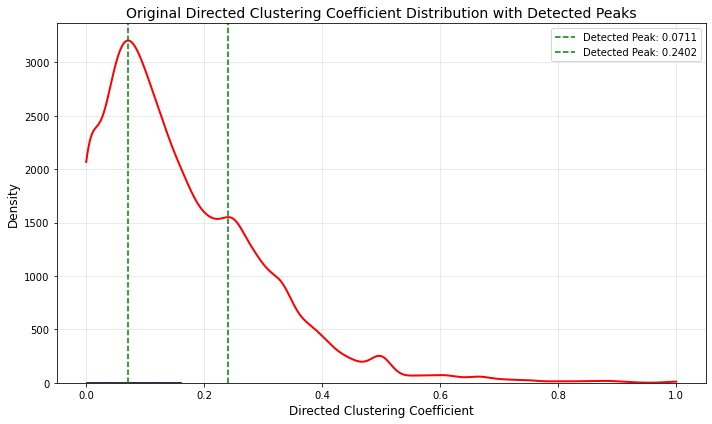

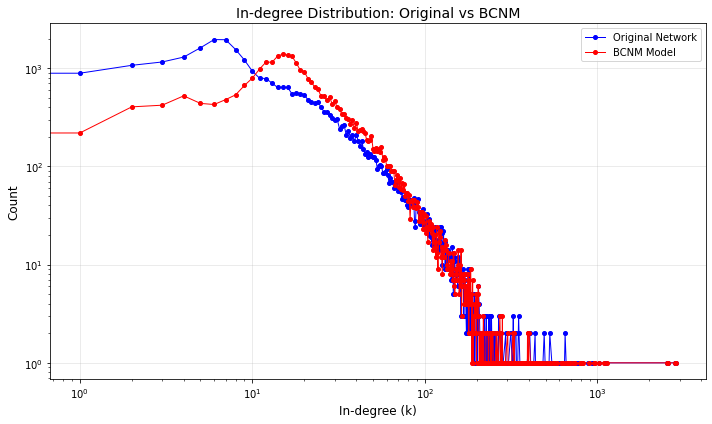

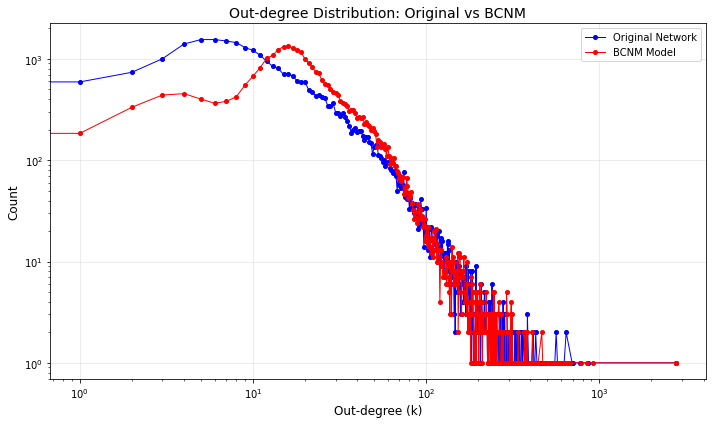

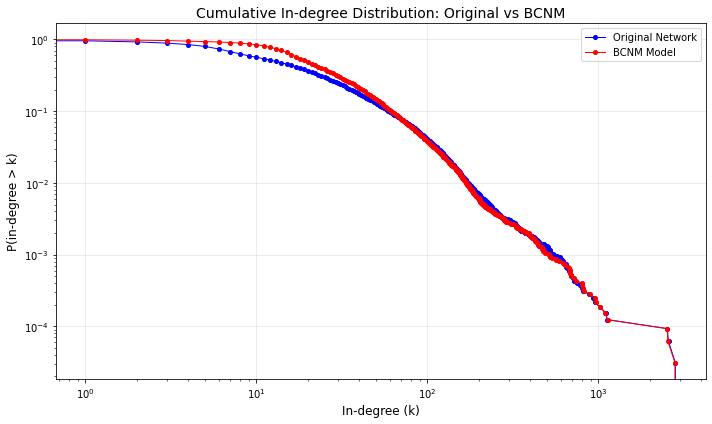

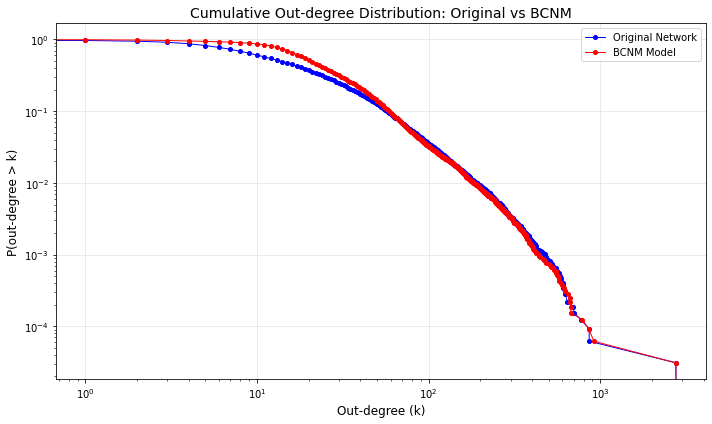

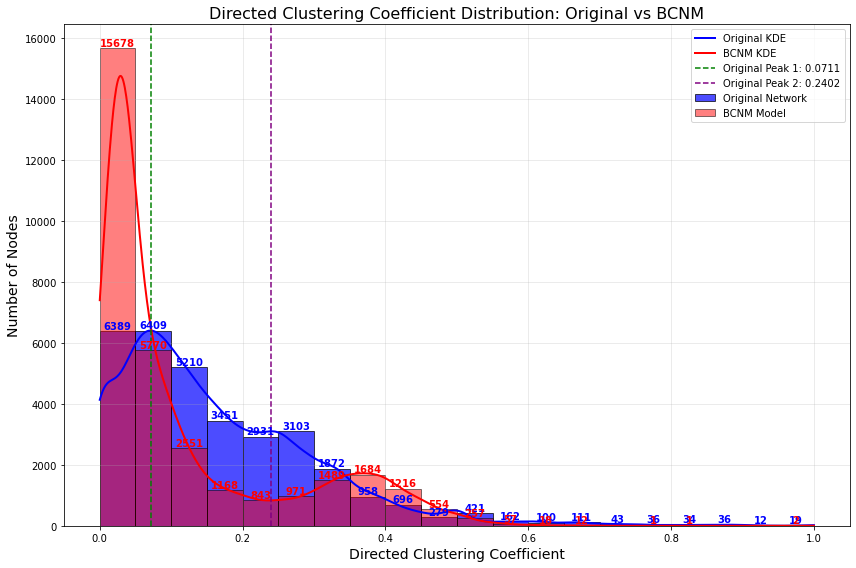

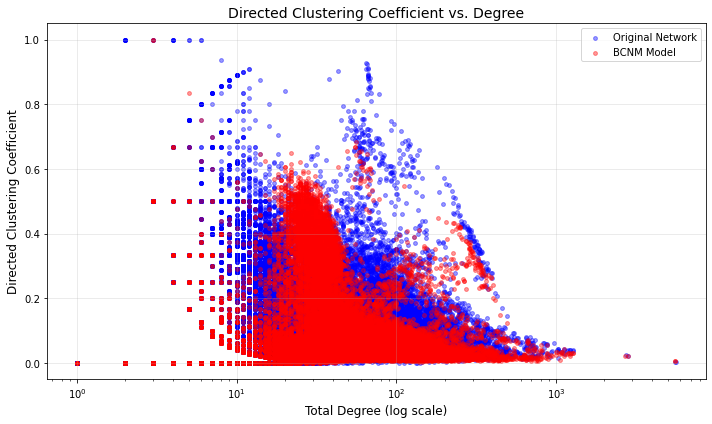

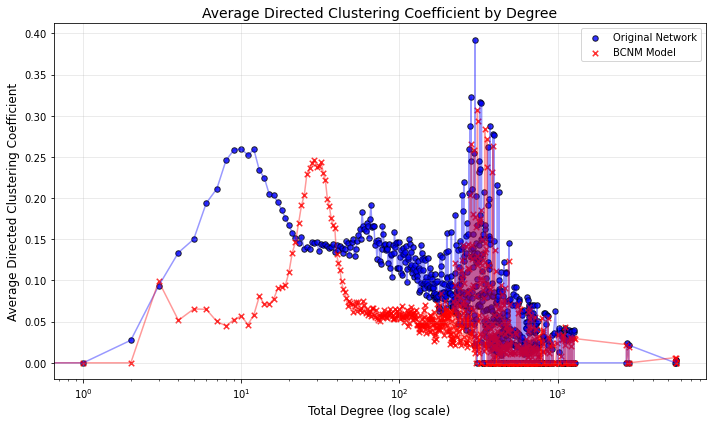

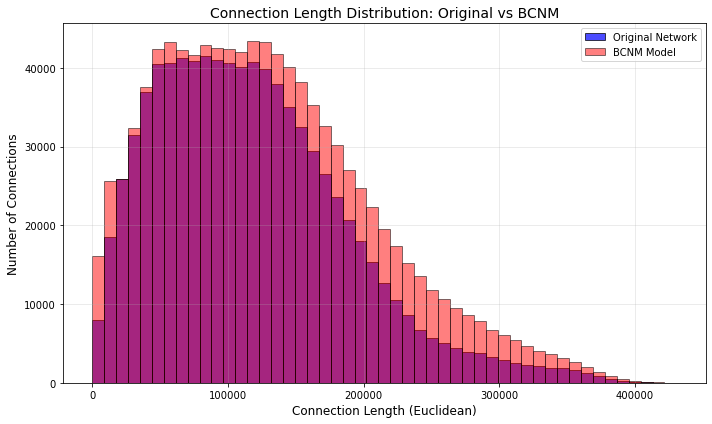

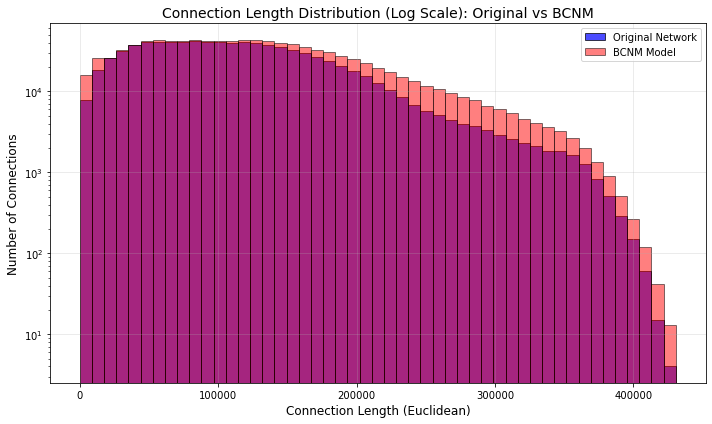

In [18]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import time
import random
from scipy.stats import gaussian_kde, ks_2samp
from scipy.signal import find_peaks

print("Starting Bimodal Clustering Network Model (BCNM) implementation...")
start_time = time.time()

# Read the data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Calculate total degree
total_degree = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

# Function for calculating directed clustering coefficient consistently
def directed_clustering(G):
    """
    Calculate directed clustering coefficient for each node.
    This is explicitly defined to ensure consistent calculation throughout the code.
    """
    print("Calculating directed clustering coefficients...")
    clustering = {}
    
    for node in G.nodes():
        # Get predecessors and successors
        predecessors = list(G.predecessors(node))
        successors = list(G.successors(node))
        
        # Remove self-loops
        if node in predecessors:
            predecessors.remove(node)
        if node in successors:
            successors.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(predecessors) * len(successors)
        
        # If no possible triangles, clustering is 0
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = 0
        for pred in predecessors:
            for succ in successors:
                if G.has_edge(pred, succ):
                    actual_triangles += 1
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Calculate clustering coefficients for the original network
print("Calculating clustering coefficients for original network...")
clustering = directed_clustering(G)
original_clustering_values = list(clustering.values())

print(f"Original network average directed clustering coefficient: {np.mean(original_clustering_values):.4f}")

# Create bins for histogram and KDE
bins = np.linspace(0, 1, 41)  # 40 bins from 0 to 1

# Compute KDE for the clustering coefficient distribution
kde = gaussian_kde(original_clustering_values)
x_vals = np.linspace(0, 1, 1000)
y_vals = kde(x_vals)

# Find peaks in the KDE
print("Finding peaks in clustering coefficient distribution...")
peaks, _ = find_peaks(y_vals, height=max(y_vals)*0.1, distance=50)
peak_x = x_vals[peaks]
peak_y = y_vals[peaks]

# Sort peaks by height
if len(peak_y) >= 2:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]
    peak_cc_values = sorted([peak_x[idx] for idx in top_peaks])
    
    peak1 = peak_cc_values[0]
    peak2 = peak_cc_values[1] if len(peak_cc_values) > 1 else peak_cc_values[0]
    
    print(f"Identified clustering coefficient peaks at: {peak1:.4f} and {peak2:.4f}")
else:
    # Fallback if peaks aren't found
    print("Failed to find bimodal peaks automatically, using default values")
    peak1 = 0.1
    peak2 = 0.4

# Plot the original clustering coefficient distribution with detected peaks
plt.figure(figsize=(10, 6))
plt.hist(original_clustering_values, bins=25, alpha=0.7, density=True, color='blue', edgecolor='black')
plt.plot(x_vals, y_vals * (bins[1] - bins[0]) * len(original_clustering_values), 'r-', linewidth=2)
for peak in [peak1, peak2]:
    plt.axvline(x=peak, color='green', linestyle='--', 
                label=f'Detected Peak: {peak:.4f}')
plt.xlabel('Directed Clustering Coefficient', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Original Directed Clustering Coefficient Distribution with Detected Peaks', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/original_cc_peaks.png', dpi=600)
print("Saved original clustering coefficient distribution with peaks plot at 600dpi")

# Classify nodes into two groups based on clustering coefficient
print("Classifying nodes based on clustering coefficient...")
midpoint = (peak1 + peak2) / 2
nodes_low_cc = [node for node, cc in clustering.items() if cc <= midpoint]
nodes_high_cc = [node for node, cc in clustering.items() if cc > midpoint]

print(f"Low clustering coefficient group (≤{midpoint:.4f}): {len(nodes_low_cc)} nodes")
print(f"High clustering coefficient group (>{midpoint:.4f}): {len(nodes_high_cc)} nodes")

# Create the Bimodal Clustering Network Model
print("Creating Bimodal Clustering Network Model...")
bcnm_graph = nx.DiGraph()

# Add the same nodes as the original graph with their attributes
for node in G.nodes():
    bcnm_graph.add_node(node, **G.nodes[node])

print(f"Added {bcnm_graph.number_of_nodes()} nodes to BCNM graph")

# Step 1: Create communities based on the bimodal clustering and module information
print("Step 1: Creating communities based on bimodal clustering and modules...")

# Group nodes by module and clustering group
module_cc_groups = defaultdict(lambda: defaultdict(list))
for node in G.nodes():
    module = modules[node]
    cc_group = "high" if node in nodes_high_cc else "low"
    module_cc_groups[module][cc_group].append(node)

# Create communities from these groups
communities = []
community_id = 0
node_to_community = {}

# Process high CC nodes first (they form tightly connected communities)
for module, cc_groups in module_cc_groups.items():
    high_cc_nodes = cc_groups["high"]
    
    if high_cc_nodes:
        # Further divide high CC nodes by degree for better structure preservation
        degree_groups = defaultdict(list)
        for node in high_cc_nodes:
            degree_bin = total_degree[node] // 5  # Group by degree in bins of 5
            degree_groups[degree_bin].append(node)
        
        # Create communities from degree groups
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:  # Minimum community size
                community_size = min(20, len(nodes))  # Limit maximum community size
                
                # Split into communities of appropriate size
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                # Handle singleton nodes
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1
    
    # Process low CC nodes with different strategy
    low_cc_nodes = cc_groups["low"]
    
    if low_cc_nodes:
        # Low CC nodes form more loosely connected communities
        # Group by degree for better degree distribution preservation
        degree_groups = defaultdict(list)
        for node in low_cc_nodes:
            degree_bin = total_degree[node] // 10  # Wider bins for low CC
            degree_groups[degree_bin].append(node)
        
        for deg_bin, nodes in degree_groups.items():
            if len(nodes) >= 2:
                community_size = min(30, len(nodes))  # Larger communities
                
                for i in range(0, len(nodes), community_size):
                    community_nodes = nodes[i:i+community_size]
                    communities.append(community_nodes)
                    
                    for node in community_nodes:
                        node_to_community[node] = community_id
                    
                    community_id += 1
            else:
                for node in nodes:
                    communities.append([node])
                    node_to_community[node] = community_id
                    community_id += 1

print(f"Created {community_id} communities")

# Step 2: Add edges within communities with appropriate densities
print("Step 2: Adding edges within communities...")

edges_added = 0
for community_idx, community in enumerate(communities):
    if len(community) <= 1:
        continue
    
    # Calculate target average clustering for this community
    community_nodes_cc = [clustering[node] for node in community]
    target_cc = np.mean(community_nodes_cc)
    
    # Calculate density based on target clustering
    if target_cc > midpoint:
        # High clustering communities - higher density
        # For a complete graph, density = 1, cc = 1
        # Scale density based on target_cc
        density = min(0.95, max(0.5, target_cc))
    else:
        # Low clustering communities - lower density
        density = min(0.5, max(0.05, target_cc * 2))
    
    # Add edges with calculated density
    for i, u in enumerate(community):
        for j, v in enumerate(community):
            if i != j and random.random() < density:
                bcnm_graph.add_edge(u, v)
                edges_added += 1

print(f"Added {edges_added} edges within communities")
print(f"After Step 2: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 3: Connect communities to match the inter-community structure of the original graph
print("Step 3: Connecting communities...")

# Analyze inter-community connections in the original graph
inter_community_edges = defaultdict(int)
inter_community_pairs = defaultdict(int)

for u, v in G.edges():
    if u in node_to_community and v in node_to_community:
        comm_u = node_to_community[u]
        comm_v = node_to_community[v]
        
        if comm_u != comm_v:
            inter_community_edges[(comm_u, comm_v)] += 1
            inter_community_pairs[(comm_u, comm_v)] += 1

# Calculate probability of edges between communities
inter_community_probs = {}
for (comm_u, comm_v), count in inter_community_edges.items():
    # Get sizes of communities
    size_u = len(communities[comm_u]) if comm_u < len(communities) else 0
    size_v = len(communities[comm_v]) if comm_v < len(communities) else 0
    
    if size_u > 0 and size_v > 0:
        # Maximum possible edges between communities
        max_edges = size_u * size_v
        # Probability of edge
        prob = count / max_edges
        inter_community_probs[(comm_u, comm_v)] = min(1.0, max(0.001, prob))

print(f"Calculated probabilities for {len(inter_community_probs)} community pairs")

# Add edges between communities
inter_edges_added = 0
for (comm_u, comm_v), prob in inter_community_probs.items():
    # Get nodes from communities
    nodes_u = communities[comm_u] if comm_u < len(communities) else []
    nodes_v = communities[comm_v] if comm_v < len(communities) else []
    
    for u in nodes_u:
        for v in nodes_v:
            if random.random() < prob:
                bcnm_graph.add_edge(u, v)
                inter_edges_added += 1

print(f"Added {inter_edges_added} edges between communities")
print(f"After Step 3: BCNM graph has {bcnm_graph.number_of_edges()} edges")

# Step 4: Degree correction to match target degree distribution
print("Step 4: Performing degree correction...")

# Get current degrees
current_in_degrees = dict(bcnm_graph.in_degree())
current_out_degrees = dict(bcnm_graph.out_degree())

# Calculate how many edges need to be added for each node
in_degree_deficit = {node: max(0, in_degrees[node] - current_in_degrees[node]) for node in G.nodes()}
out_degree_deficit = {node: max(0, out_degrees[node] - current_out_degrees[node]) for node in G.nodes()}

total_in_deficit = sum(in_degree_deficit.values())
total_out_deficit = sum(out_degree_deficit.values())
print(f"Total in-degree deficit: {total_in_deficit}")
print(f"Total out-degree deficit: {total_out_deficit}")

# Create stubs for the Configuration Model part
in_stubs = []
for node, deficit in in_degree_deficit.items():
    in_stubs.extend([node] * deficit)

out_stubs = []
for node, deficit in out_degree_deficit.items():
    out_stubs.extend([node] * deficit)

# Shuffle stubs
random.shuffle(in_stubs)
random.shuffle(out_stubs)

# Match stubs to create edges, avoiding self-loops and multi-edges
added_edges = 0
max_attempts = min(len(in_stubs), len(out_stubs)) * 10  # Allow for multiple attempts
attempts = 0

while in_stubs and out_stubs and attempts < max_attempts:
    out_node = out_stubs.pop()
    in_node = in_stubs.pop()
    
    # Check if it's a self-loop or already existing edge
    if out_node != in_node and not bcnm_graph.has_edge(out_node, in_node):
        bcnm_graph.add_edge(out_node, in_node)
        added_edges += 1
    else:
        # Put the stubs back and try again
        out_stubs.append(out_node)
        in_stubs.append(in_node)
    
    attempts += 1

print(f"Step 4: Added {added_edges} edges to match degree distribution")
print(f"Final BCNM graph has {bcnm_graph.number_of_nodes()} nodes and {bcnm_graph.number_of_edges()} edges")

# Calculate final degrees and metrics
final_in_degrees = dict(bcnm_graph.in_degree())
final_out_degrees = dict(bcnm_graph.out_degree())

# Calculate average absolute error in degree matching
in_degree_error = sum(abs(in_degrees[n] - final_in_degrees[n]) for n in G.nodes()) / G.number_of_nodes()
out_degree_error = sum(abs(out_degrees[n] - final_out_degrees[n]) for n in G.nodes()) / G.number_of_nodes()

print(f"Average absolute error in in-degree matching: {in_degree_error:.4f}")
print(f"Average absolute error in out-degree matching: {out_degree_error:.4f}")

# Calculate clustering coefficients for the model using our consistent function
print("Calculating clustering coefficients for BCNM model...")
bcnm_clustering = directed_clustering(bcnm_graph)

print(f"Original network average directed clustering: {np.mean(list(clustering.values())):.4f}")
print(f"BCNM network average directed clustering: {np.mean(list(bcnm_clustering.values())):.4f}")

# Perform KS test for degree and clustering coefficient distributions
original_in_degrees_list = list(in_degrees.values())
original_out_degrees_list = list(out_degrees.values())
bcnm_in_degrees_list = list(final_in_degrees.values())
bcnm_out_degrees_list = list(final_out_degrees.values())

original_cc_list = list(clustering.values())
bcnm_cc_list = list(bcnm_clustering.values())

ks_in_degree = ks_2samp(original_in_degrees_list, bcnm_in_degrees_list)
ks_out_degree = ks_2samp(original_out_degrees_list, bcnm_out_degrees_list)
ks_clustering = ks_2samp(original_cc_list, bcnm_cc_list)

print(f"KS test for in-degree distribution: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.4f}")
print(f"KS test for out-degree distribution: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.4f}")
print(f"KS test for clustering coefficient distribution: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.4f}")

# Plot comparison of degree distributions
print("Plotting degree distributions...")

# Calculate degree distributions
original_in_degree_counts = Counter(original_in_degrees_list)
original_out_degree_counts = Counter(original_out_degrees_list)
bcnm_in_degree_counts = Counter(bcnm_in_degrees_list)
bcnm_out_degree_counts = Counter(bcnm_out_degrees_list)

# In-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_in_degree_counts.keys()), 
           [original_in_degree_counts[k] for k in sorted(original_in_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_in_degree_counts.keys()), 
           [bcnm_in_degree_counts[k] for k in sorted(bcnm_in_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(sorted(original_out_degree_counts.keys()), 
           [original_out_degree_counts[k] for k in sorted(original_out_degree_counts.keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(bcnm_out_degree_counts.keys()), 
           [bcnm_out_degree_counts[k] for k in sorted(bcnm_out_degree_counts.keys())], 
           'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate cumulative degree distributions
print("Calculating cumulative degree distributions...")

# For in-degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_bcnm_in = sorted(bcnm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_bcnm_nodes = bcnm_graph.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM in-degrees
x_bcnm_in = [k for k, _ in sorted_bcnm_in]
y_bcnm_in = []
count_so_far = 0
for _, count in sorted_bcnm_in:
    count_so_far += count
    y_bcnm_in.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_in, y_bcnm_in, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_bcnm_out = sorted(bcnm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For BCNM out-degrees
x_bcnm_out = [k for k, _ in sorted_bcnm_out]
y_bcnm_out = []
count_so_far = 0
for _, count in sorted_bcnm_out:
    count_so_far += count
    y_bcnm_out.append(1 - count_so_far / total_bcnm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_bcnm_out, y_bcnm_out, 'ro-', markersize=4, linewidth=1, label='BCNM Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Plot clustering coefficient distributions with histograms and KDE
print("Plotting clustering coefficient distributions...")

plt.figure(figsize=(12, 8))

# Create histogram bins
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms
counts_orig, bins_orig, _ = plt.hist(original_cc_list, bins=bins, alpha=0.7, 
                                      color='blue', edgecolor='black', 
                                      label='Original Network')
counts_bcnm, bins_bcnm, _ = plt.hist(bcnm_cc_list, bins=bins, alpha=0.5, 
                                      color='red', edgecolor='black', 
                                      label='BCNM Model')

# Add count numbers above bars
bin_centers = 0.5 * (bins[:-1] + bins[1:])
for i, (count_orig, count_bcnm) in enumerate(zip(counts_orig, counts_bcnm)):
    if count_orig > 0:
        plt.text(bin_centers[i], count_orig + 5, str(int(count_orig)), 
                 ha='center', va='bottom', color='blue', fontweight='bold')
    if count_bcnm > 0:
        plt.text(bin_centers[i], count_bcnm + 5, str(int(count_bcnm)), 
                 ha='center', va='bottom', color='red', fontweight='bold')

# Add KDE for both distributions
x_vals = np.linspace(0, 1, 1000)
original_kde = gaussian_kde(original_cc_list)
bcnm_kde = gaussian_kde(bcnm_cc_list)
plt.plot(x_vals, original_kde(x_vals) * len(original_cc_list) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, bcnm_kde(x_vals) * len(bcnm_cc_list) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='BCNM KDE')

# Add vertical lines for the original peaks
plt.axvline(x=peak1, color='green', linestyle='--', label=f'Original Peak 1: {peak1:.4f}')
plt.axvline(x=peak2, color='purple', linestyle='--', label=f'Original Peak 2: {peak2:.4f}')

# Add title and labels
plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution: Original vs BCNM', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig('plots/bcnm_clustering_coefficient_histogram.png', dpi=600)
print("Saved clustering coefficient histogram plot at 600dpi")

# Create a scatter plot of clustering coefficient by degree
print("Creating scatter plot of clustering coefficient by degree...")

plt.figure(figsize=(10, 6))

# Original network
plt.scatter([total_degree[n] for n in G.nodes()], 
            [clustering[n] for n in G.nodes()],
            alpha=0.4, s=15, c='blue', label='Original Network')

# BCNM model
bcnm_total_degree = {n: final_in_degrees[n] + final_out_degrees[n] for n in bcnm_graph.nodes()}
plt.scatter([bcnm_total_degree[n] for n in bcnm_graph.nodes()], 
            [bcnm_clustering[n] for n in bcnm_graph.nodes()],
            alpha=0.4, s=15, c='red', label='BCNM Model')

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Directed Clustering Coefficient', fontsize=12)
plt.title('Directed Clustering Coefficient vs. Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_cc_vs_degree.png', dpi=600)
print("Saved clustering coefficient vs. degree plot at 600dpi")

# Calculate average clustering by degree for both networks
print("Calculating average clustering by degree...")

# Original network
original_cc_by_degree = defaultdict(list)
for node in G.nodes():
    deg = total_degree[node]
    original_cc_by_degree[deg].append(clustering[node])

# BCNM model
bcnm_cc_by_degree = defaultdict(list)
for node in bcnm_graph.nodes():
    deg = bcnm_total_degree[node]
    bcnm_cc_by_degree[deg].append(bcnm_clustering[node])

# Calculate averages
original_avg_cc_by_degree = {d: np.mean(cc) for d, cc in original_cc_by_degree.items() if cc}
bcnm_avg_cc_by_degree = {d: np.mean(cc) for d, cc in bcnm_cc_by_degree.items() if cc}

# Plot average clustering coefficient by degree
plt.figure(figsize=(10, 6))

# Get sorted degrees
all_degrees = sorted(set(original_avg_cc_by_degree.keys()) | set(bcnm_avg_cc_by_degree.keys()))
original_cc_values = [original_avg_cc_by_degree.get(d, 0) for d in all_degrees]
bcnm_cc_values = [bcnm_avg_cc_by_degree.get(d, 0) for d in all_degrees]

plt.scatter(all_degrees, original_cc_values, alpha=0.8, s=30, c='blue', 
            edgecolors='black', label='Original Network')
plt.scatter(all_degrees, bcnm_cc_values, alpha=0.8, s=30, c='red', 
            edgecolors='black', label='BCNM Model', marker='x')

# Add trend lines
plt.plot(all_degrees, original_cc_values, 'b-', alpha=0.4)
plt.plot(all_degrees, bcnm_cc_values, 'r-', alpha=0.4)

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=12)
plt.ylabel('Average Directed Clustering Coefficient', fontsize=12)
plt.title('Average Directed Clustering Coefficient by Degree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/bcnm_avg_cc_by_degree.png', dpi=600)
print("Saved average clustering coefficient by degree plot at 600dpi")

# Calculate connection length distributions
print("Calculating connection length distributions...")

def calculate_euclidean_distance(graph, edge):
    """Calculate Euclidean distance between nodes in 3D space"""
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        # Skip if coordinates are missing
        return None

# Calculate distances for original network
print("Calculating distances for original network...")
original_distances = []
for edge in G.edges():
    distance = calculate_euclidean_distance(G, edge)
    if distance is not None:
        original_distances.append(distance)

# Calculate distances for BCNM network
print("Calculating distances for BCNM network...")
bcnm_distances = []
for edge in bcnm_graph.edges():
    distance = calculate_euclidean_distance(bcnm_graph, edge)
    if distance is not None:
        bcnm_distances.append(distance)

print(f"Original network average connection length: {np.mean(original_distances):.4f}")
print(f"BCNM network average connection length: {np.mean(bcnm_distances):.4f}")

# Plot connection length distributions
plt.figure(figsize=(10, 6))
bins = np.linspace(0, max(np.max(original_distances), np.max(bcnm_distances)), 50)
plt.hist(original_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Network')
plt.hist(bcnm_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='BCNM Model')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.title('Connection Length Distribution: Original vs BCNM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bcnm_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
plt.figure(figsize=(10, 6))
plt.hist(original_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Network')
plt.hist(bcnm_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='BCNM Model')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.yscale('log')
plt.title('Connection Length Distribution (Log Scale): Original vs BCNM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bcnm_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution plot at 600dpi")

# Save the BCNM graph to files for future use
print("Saving BCNM data...")
bcnm_edges = list(bcnm_graph.edges())
bcnm_edges_df = pd.DataFrame(bcnm_edges, columns=['from', 'to'])
bcnm_edges_df.to_csv('bcnm_edges.csv', index=False)

# Save node metadata
bcnm_nodes = list(bcnm_graph.nodes(data=True))
bcnm_metadata = []
for node, data in bcnm_nodes:
    bcnm_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
bcnm_metadata_df = pd.DataFrame(bcnm_metadata)
bcnm_metadata_df.to_csv('bcnm_metadata.csv', index=False)

print("BCNM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")